In [ ]:
# Librerías necesarias
%pip install -q numpy pandas scipy scikit-learn imbalanced-learn matplotlib joblib

In [ ]:
#Importamos lo correspondiente
import os
import json
import random
import hashlib
import platform
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import imblearn

from scipy import stats

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
)

from sklearn.pipeline import Pipeline

from sklearn.feature_selection import VarianceThreshold

from sklearn.preprocessing import (
    StandardScaler,
)

from sklearn.impute import (
    SimpleImputer,
)

from sklearn.svm import SVC

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    make_scorer,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE

from imblearn.under_sampling import (
    RandomUnderSampler,
)

from imblearn.pipeline import Pipeline as ImbPipeline

from joblib import dump, load

warnings.filterwarnings("ignore")

print("Importaciones listas.")

##Semillas y demás de reproducibilidad

In [ ]:
SEED = 4524

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Semilla global:", SEED)
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

Semilla global: 4524
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2


In [ ]:
#Google drive
from google.colab import drive

drive.mount("/content/drive")

ValueError: Mountpoint must not already contain files

In [ ]:
#Montamos las rutas
candidate_project_dirs = [
    Path("/content/drive/MyDrive/Quantathon"),
    Path("/content/drive/MyDrive/Quanthaton"),
]

PROJECT_DIR = next(
    (
        path
        for path in candidate_project_dirs
        if path.exists()
    ),
    None,
)

assert PROJECT_DIR is not None, (
    "No se encontró la carpeta Quantathon o Quanthaton "
    "dentro de MyDrive."
)

TRAINING_CSV = (
    PROJECT_DIR
    / "water_potability_complete_cases.csv"
)

EXTERNAL_21_CSV = (
    PROJECT_DIR
    / "ircach_21_muestras_completas_4_features_labeled.csv"
)

EXTERNAL_14_CSV = (
    PROJECT_DIR
    / "ircach_14_muestras_completas_5_features_labeled.csv"
)

print("Carpeta del proyecto:")
print(PROJECT_DIR)

print("\nArchivos esperados:")
print("Training:", TRAINING_CSV)
print("IRCACH 21:", EXTERNAL_21_CSV)
print("IRCACH 14:", EXTERNAL_14_CSV)

#Y comprobamos los archivos
files_to_check = {
    "Training complete cases": TRAINING_CSV,
    "IRCACH 21 muestras / 4F": EXTERNAL_21_CSV,
    "IRCACH 14 muestras / 5F": EXTERNAL_14_CSV,
}

for file_name, file_path in files_to_check.items():

    exists = file_path.exists()

    print(
        f"{file_name}: "
        f"{'ENCONTRADO' if exists else 'NO ENCONTRADO'}"
    )

    if exists:
        size_kb = file_path.stat().st_size / 1024

        print(
            f"  Archivo: {file_path.name}"
        )

        print(
            f"  Tamaño: {size_kb:.2f} KB"
        )

assert TRAINING_CSV.exists(), (
    f"No se encontró: {TRAINING_CSV}"
)

assert EXTERNAL_21_CSV.exists(), (
    f"No se encontró: {EXTERNAL_21_CSV}"
)

assert EXTERNAL_14_CSV.exists(), (
    f"No se encontró: {EXTERNAL_14_CSV}"
)

Carpeta del proyecto:
/content/drive/MyDrive/Quanthaton

Archivos esperados:
Training: /content/drive/MyDrive/Quanthaton/water_potability_complete_cases.csv
IRCACH 21: /content/drive/MyDrive/Quanthaton/ircach_21_muestras_completas_4_features_labeled.csv
IRCACH 14: /content/drive/MyDrive/Quanthaton/ircach_14_muestras_completas_5_features_labeled.csv
Training complete cases: ENCONTRADO
  Archivo: water_potability_complete_cases.csv
  Tamaño: 351.36 KB
IRCACH 21 muestras / 4F: ENCONTRADO
  Archivo: ircach_21_muestras_completas_4_features_labeled.csv
  Tamaño: 3.55 KB
IRCACH 14 muestras / 5F: ENCONTRADO
  Archivo: ircach_14_muestras_completas_5_features_labeled.csv
  Tamaño: 2.54 KB


In [ ]:
#Cargamos los csv
df_water_complete = pd.read_csv(
    TRAINING_CSV
)

df_ircach_21 = pd.read_csv(
    EXTERNAL_21_CSV
)

df_ircach_14 = pd.read_csv(
    EXTERNAL_14_CSV
)

print(
    "Water complete cases:",
    df_water_complete.shape
)

print(
    "IRCACH 21:",
    df_ircach_21.shape
)

print(
    "IRCACH 14:",
    df_ircach_14.shape
)

Water complete cases: (2011, 11)
IRCACH 21: (21, 16)
IRCACH 14: (14, 17)


In [ ]:
#Definimos de una vez las 4 features
FEATURES_MAIN = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

TARGET = "Potability"

print("Features principales:")

for feature in FEATURES_MAIN:
    print("-", feature)

print("\nTarget:", TARGET)
#Verificamos las columnas+

required_training_columns = (
    FEATURES_MAIN
    + [TARGET]
)

required_external_columns = (
    FEATURES_MAIN
    + [TARGET]
)

missing_training = [
    column
    for column in required_training_columns
    if column not in df_water_complete.columns
]

missing_external = [
    column
    for column in required_external_columns
    if column not in df_ircach_21.columns
]

assert not missing_training, (
    f"Faltan columnas en training: "
    f"{missing_training}"
)

assert not missing_external, (
    f"Faltan columnas en IRCACH 21: "
    f"{missing_external}"
)

print("Columnas requeridas encontradas correctamente.")

print("\nColumnas del training:")
print(df_water_complete.columns.tolist())

print("\nColumnas del panel IRCACH 21:")
print(df_ircach_21.columns.tolist())

Features principales:
- ph
- Hardness
- Sulfate
- Conductivity

Target: Potability
Columnas requeridas encontradas correctamente.

Columnas del training:
['Sample_ID', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

Columnas del panel IRCACH 21:
['External_ID', 'IRCACH_example', 'PDF_page', 'AYA_ID', 'system_type', 'system_name', 'sampling_point', 'sampling_date', 'ph', 'Hardness', 'Sulfate', 'Conductivity', 'IRCACH_score', 'IRCACH_risk_level', 'IRCACH_quality', 'Potability']


In [ ]:
#Creamos las tablas impolutas
df_model = (
    df_water_complete[
        FEATURES_MAIN + [TARGET]
    ]
    .copy()
)

df_external = (
    df_ircach_21[
        FEATURES_MAIN + [TARGET]
    ]
    .copy()
)

print("Dataset de desarrollo:")
print(df_model.shape)

print("\nPanel externo congelado:")
print(df_external.shape)

display(
    df_model.head()
)

display(
    df_external.head()
)

Dataset de desarrollo:
(2011, 5)

Panel externo congelado:
(21, 5)


,ph,Hardness,Sulfate,Conductivity,Potability
0,8.3168,214.3734,356.8861,363.2665,0
1,9.0922,181.1015,310.1357,398.4108,0
2,5.5841,188.3133,326.6784,280.4679,0
3,10.2239,248.0717,393.6634,283.6516,0
4,8.6358,203.3615,303.3098,474.6076,0


,ph,Hardness,Sulfate,Conductivity,Potability
0,7.0800,56.0000,2.1300,103.0000,0
1,7.4700,6367.0000,297.3300,11090.0000,0
2,6.8300,46.0000,2.0200,126.0000,1
3,4.6500,10.0000,17.2900,115.0000,0
4,7.7200,22.0000,22.1000,76.0000,0


##Parte del modelado.

In [ ]:
#Hacemos un split estratificado relación 80/20
all_indices = np.arange(len(df_model))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=df_model[TARGET],
    random_state=SEED,
    shuffle=True,
)

X_train = (
    df_model
    .iloc[train_indices][FEATURES_MAIN]
    .copy()
)

X_test = (
    df_model
    .iloc[test_indices][FEATURES_MAIN]
    .copy()
)

y_train = (
    df_model
    .iloc[train_indices][TARGET]
    .astype(int)
    .copy()
)

y_test = (
    df_model
    .iloc[test_indices][TARGET]
    .astype(int)
    .copy()
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (1608, 4)
X_test:  (403, 4)
y_train: (1608,)
y_test:  (403,)


In [ ]:
#Observamos como nos salío la estratificación
def class_distribution(y, name):

    counts = (
        pd.Series(y)
        .value_counts()
        .sort_index()
    )

    percentages = (
        pd.Series(y)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    summary = pd.DataFrame({
        "Dataset": name,
        "Clase": counts.index,
        "n": counts.values,
        "Porcentaje": percentages.values,
    })

    return summary


split_distribution = pd.concat(
    [
        class_distribution(
            df_model[TARGET],
            "Dataset completo",
        ),
        class_distribution(
            y_train,
            "Training",
        ),
        class_distribution(
            y_test,
            "Test",
        ),
    ],
    ignore_index=True,
)

display(
    split_distribution.round(2)
)

assert len(
    set(train_indices).intersection(
        set(test_indices)
    )
) == 0

assert len(train_indices) + len(test_indices) == len(df_model)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

assert list(X_train.columns) == FEATURES_MAIN
assert list(X_test.columns) == FEATURES_MAIN

print("Split correcto.")
print("Solapamiento train/test: 0")
print("NaN en train:", X_train.isna().sum().sum())
print("NaN en test:", X_test.isna().sum().sum())

,Dataset,Clase,n,Porcentaje
0,Dataset completo,0,1200,59.6700
1,Dataset completo,1,811,40.3300
2,Training,0,960,59.7000
3,Training,1,648,40.3000
4,Test,0,240,59.5500
5,Test,1,163,40.4500


Split correcto.
Solapamiento train/test: 0
NaN en train: 0
NaN en test: 0


In [ ]:
#Preparamos el SVMRBF original
baseline_svm = Pipeline(
    steps=[
        (
            "variance",
            VarianceThreshold(
                threshold=0.0
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight=None,
                probability=False,
                random_state=SEED,
            ),
        ),
    ]
)

baseline_svm

baseline_svm.fit(
    X_train,
    y_train,
)

y_train_pred = baseline_svm.predict(
    X_train
)

y_test_pred = baseline_svm.predict(
    X_test
)

y_train_score = baseline_svm.decision_function(
    X_train
)

y_test_score = baseline_svm.decision_function(
    X_test
)

print("Baseline SVM-RBF entrenado.")

Baseline SVM-RBF entrenado.


In [ ]:
#Calibramos para brier score
calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

calibrated_svm = CalibratedClassifierCV(
    estimator=clone(baseline_svm),
    method="sigmoid",
    cv=calibration_cv,
    n_jobs=-1,
)

calibrated_svm.fit(
    X_train,
    y_train,
)

y_train_probability = calibrated_svm.predict_proba(
    X_train
)[:, 1]

y_test_probability = calibrated_svm.predict_proba(
    X_test
)[:, 1]

print("Probabilidades calibradas.")
print(
    "Rango test:",
    round(y_test_probability.min(), 4),
    "—",
    round(y_test_probability.max(), 4),
)

Probabilidades calibradas.
Rango test: 0.1921 — 0.9035


##Métricas

,Dataset,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,Brier_Score,TN,FP,FN,TP
0,Training,0.6940,0.6399,0.7500,0.3611,0.4875,0.3471,0.7457,0.1982,882,78,414,234
1,Test,0.6526,0.6030,0.6292,0.3436,0.4444,0.2438,0.6852,0.2170,207,33,107,56


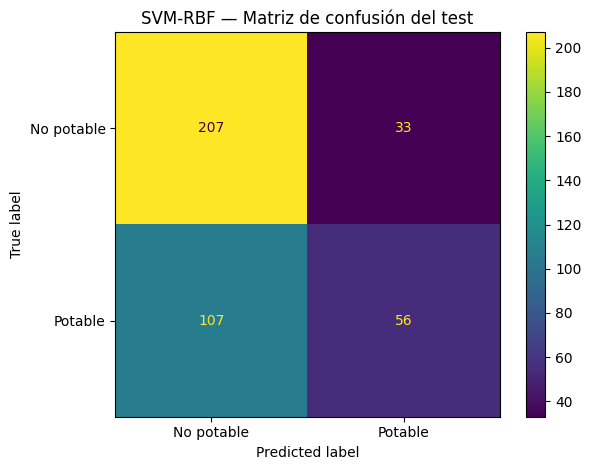

              precision    recall  f1-score   support

  No potable     0.6592    0.8625    0.7473       240
     Potable     0.6292    0.3436    0.4444       163

    accuracy                         0.6526       403
   macro avg     0.6442    0.6030    0.5959       403
weighted avg     0.6471    0.6526    0.6248       403



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


def evaluate_binary_classifier(
    y_true,
    y_pred,
    y_score,
    y_probability,
    dataset_name,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    results = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Brier_Score": brier_score_loss(y_true, y_probability),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

    return results


baseline_results = pd.DataFrame(
    [
        evaluate_binary_classifier(
            y_true=y_train,
            y_pred=y_train_pred,
            y_score=y_train_score,
            y_probability=y_train_probability,
            dataset_name="Training",
        ),
        evaluate_binary_classifier(
            y_true=y_test,
            y_pred=y_test_pred,
            y_score=y_test_score,
            y_probability=y_test_probability,
            dataset_name="Test",
        ),
    ]
)

display(baseline_results.round(4))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=[0, 1],
    display_labels=[
        "No potable",
        "Potable",
    ],
    values_format="d",
)

plt.title("SVM-RBF — Matriz de confusión del test")
plt.tight_layout()
plt.show()


print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1],
        target_names=[
            "No potable",
            "Potable",
        ],
        digits=4,
        zero_division=0,
    )
)

##Validaciones

In [ ]:
#validación crossvalidation5fold
from sklearn.metrics import make_scorer

cv_5fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

cv_scoring = {
    "Accuracy": "accuracy",
    "Balanced_Accuracy": "balanced_accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "MCC": make_scorer(matthews_corrcoef),
    "ROC_AUC": "roc_auc",
}

cv_results = cross_validate(
    estimator=clone(baseline_svm),
    X=X_train,
    y=y_train,
    cv=cv_5fold,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)

cv_fold_table = pd.DataFrame({
    metric: cv_results[f"test_{metric}"]
    for metric in cv_scoring
})

cv_fold_table.index = [
    f"Fold_{i}"
    for i in range(1, 6)
]

display(
    cv_fold_table.round(4)
)
cv_summary = pd.DataFrame({
    "Mean": cv_fold_table.mean(),
    "SD": cv_fold_table.std(ddof=1),
    "Minimum": cv_fold_table.min(),
    "Maximum": cv_fold_table.max(),
})

display(
    cv_summary.round(4)
)

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC
Fold_1,0.6460,0.5851,0.6481,0.2692,0.3804,0.2236,0.6591
Fold_2,0.6366,0.5885,0.5867,0.3385,0.4293,0.2055,0.6449
Fold_3,0.6863,0.6277,0.7636,0.3231,0.4541,0.3329,0.7224
Fold_4,0.6854,0.6352,0.7000,0.3798,0.4925,0.3211,0.7247
Fold_5,0.6760,0.6211,0.6984,0.3411,0.4583,0.2989,0.6886


,Mean,SD,Minimum,Maximum
Accuracy,0.6661,0.0232,0.6366,0.6863
Balanced_Accuracy,0.6115,0.0231,0.5851,0.6352
Precision,0.6794,0.0661,0.5867,0.7636
Recall,0.3303,0.0401,0.2692,0.3798
F1,0.4429,0.0416,0.3804,0.4925
MCC,0.2764,0.0581,0.2055,0.3329
ROC_AUC,0.6879,0.0361,0.6449,0.7247


In [ ]:
#Métrica de brier scoree
calibrated_model_for_cv = CalibratedClassifierCV(
    estimator=clone(baseline_svm),
    method="sigmoid",
    cv=3,
    n_jobs=-1,
)

brier_cv_results = cross_validate(
    estimator=calibrated_model_for_cv,
    X=X_train,
    y=y_train,
    cv=cv_5fold,
    scoring="neg_brier_score",
    n_jobs=-1,
    error_score="raise",
)

brier_by_fold = -brier_cv_results[
    "test_score"
]

brier_cv_summary = pd.DataFrame({
    "Fold": [
        f"Fold_{i}"
        for i in range(1, 6)
    ],
    "Brier_Score": brier_by_fold,
})

display(
    brier_cv_summary.round(4)
)

print(
    "Brier CV:",
    f"{brier_by_fold.mean():.4f}",
    "±",
    f"{brier_by_fold.std(ddof=1):.4f}",
)

,Fold,Brier_Score
0,Fold_1,0.2170
1,Fold_2,0.2269
2,Fold_3,0.2081
3,Fold_4,0.2004
4,Fold_5,0.2119


Brier CV: 0.2129 ± 0.0099


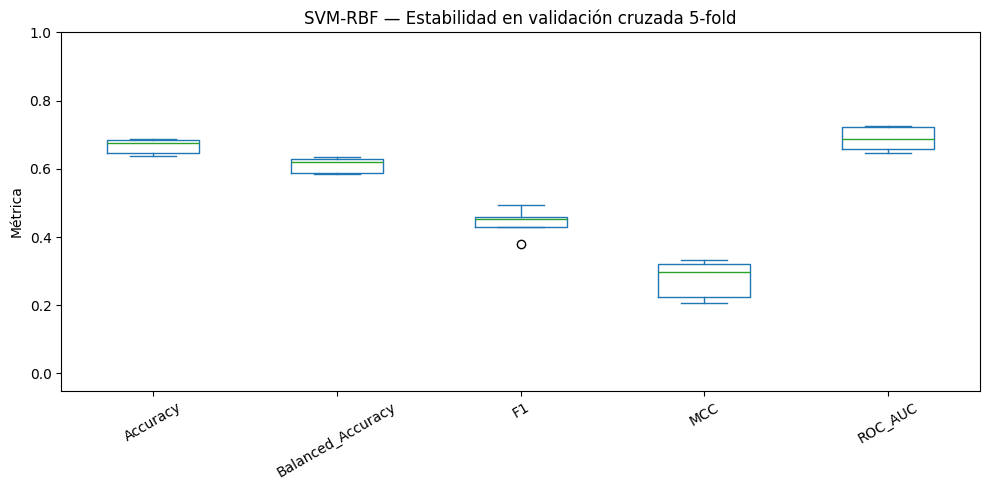

In [ ]:
#Visualiamos la estabilidad entre folds
metrics_to_plot = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

ax = cv_fold_table[
    metrics_to_plot
].plot(
    kind="box",
    figsize=(10, 5),
)

ax.set_title(
    "SVM-RBF — Estabilidad en validación cruzada 5-fold"
)

ax.set_ylabel("Métrica")
ax.set_ylim(-0.05, 1.00)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
#El famoso bootstrap con n igual a 1000, para observar la incertidumbre de las métricas sobre el cojunto test.
N_BOOTSTRAP = 1000

rng_bootstrap = np.random.default_rng(
    SEED
)

y_test_array = np.asarray(
    y_test,
    dtype=int,
)

y_test_pred_array = np.asarray(
    y_test_pred,
    dtype=int,
)

y_test_score_array = np.asarray(
    y_test_score,
    dtype=float,
)

y_test_probability_array = np.asarray(
    y_test_probability,
    dtype=float,
)

indices_class_0 = np.where(
    y_test_array == 0
)[0]

indices_class_1 = np.where(
    y_test_array == 1
)[0]

bootstrap_rows = []

for bootstrap_id in range(N_BOOTSTRAP):

    sampled_class_0 = rng_bootstrap.choice(
        indices_class_0,
        size=len(indices_class_0),
        replace=True,
    )

    sampled_class_1 = rng_bootstrap.choice(
        indices_class_1,
        size=len(indices_class_1),
        replace=True,
    )

    sampled_indices = np.concatenate([
        sampled_class_0,
        sampled_class_1,
    ])

    rng_bootstrap.shuffle(
        sampled_indices
    )

    y_true_boot = y_test_array[
        sampled_indices
    ]

    y_pred_boot = y_test_pred_array[
        sampled_indices
    ]

    y_score_boot = y_test_score_array[
        sampled_indices
    ]

    y_probability_boot = y_test_probability_array[
        sampled_indices
    ]

    bootstrap_rows.append({
        "Bootstrap_ID": bootstrap_id + 1,

        "Accuracy":
            accuracy_score(
                y_true_boot,
                y_pred_boot,
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true_boot,
                y_pred_boot,
            ),

        "Precision":
            precision_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "F1":
            f1_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_true_boot,
                y_pred_boot,
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true_boot,
                y_score_boot,
            ),

        "Brier_Score":
            brier_score_loss(
                y_true_boot,
                y_probability_boot,
            ),
    })

bootstrap_results = pd.DataFrame(
    bootstrap_rows
)

print(
    "Réplicas completadas:",
    len(bootstrap_results)
)

bootstrap_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "ROC_AUC",
    "Brier_Score",
]

observed_values = {
    "Accuracy":
        accuracy_score(
            y_test,
            y_test_pred,
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_test,
            y_test_pred,
        ),

    "Precision":
        precision_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "Recall":
        recall_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "F1":
        f1_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "MCC":
        matthews_corrcoef(
            y_test,
            y_test_pred,
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            y_test_score,
        ),

    "Brier_Score":
        brier_score_loss(
            y_test,
            y_test_probability,
        ),
}

bootstrap_summary_rows = []

for metric in bootstrap_metrics:

    values = bootstrap_results[
        metric
    ].to_numpy()

    ci_lower = np.percentile(
        values,
        2.5,
    )

    ci_upper = np.percentile(
        values,
        97.5,
    )

    bootstrap_summary_rows.append({
        "Metric": metric,
        "Observed": observed_values[metric],
        "Bootstrap_Mean": values.mean(),
        "Bootstrap_SD": values.std(ddof=1),
        "CI_2.5%": ci_lower,
        "CI_97.5%": ci_upper,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

display(
    bootstrap_summary.round(4)
)

Réplicas completadas: 1000


,Metric,Observed,Bootstrap_Mean,Bootstrap_SD,CI_2.5%,CI_97.5%
0,Accuracy,0.6526,0.6525,0.0195,0.6154,0.6923
1,Balanced_Accuracy,0.6030,0.6030,0.0211,0.5630,0.6459
2,Precision,0.6292,0.6294,0.0441,0.5473,0.7191
3,Recall,0.3436,0.3439,0.0370,0.2761,0.4172
4,F1,0.4444,0.4439,0.0381,0.3689,0.5174
5,MCC,0.2438,0.2438,0.0480,0.1534,0.3406
6,ROC_AUC,0.6852,0.6846,0.0264,0.6324,0.7352
7,Brier_Score,0.2170,0.2172,0.0073,0.2031,0.2305


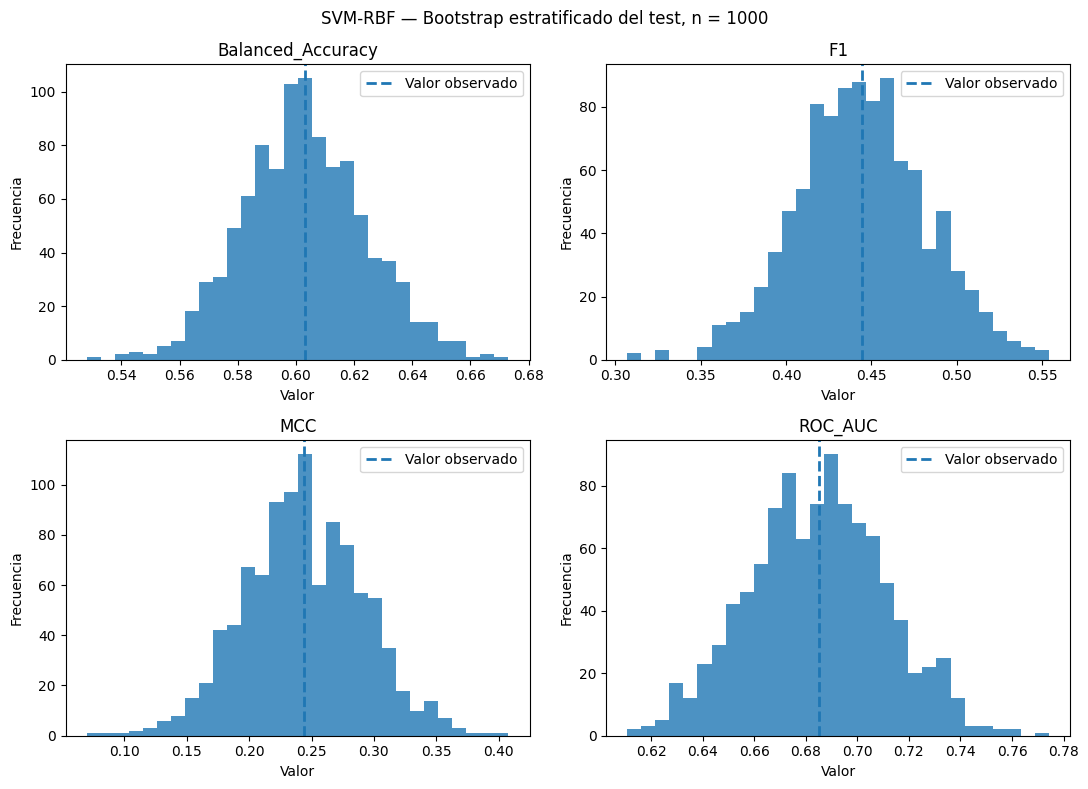

In [ ]:
#Distribuciones del boostrap
metrics_bootstrap_plot = [
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.ravel()

for ax, metric in zip(
    axes,
    metrics_bootstrap_plot,
):

    ax.hist(
        bootstrap_results[metric],
        bins=30,
        alpha=0.80,
    )

    ax.axvline(
        observed_values[metric],
        linestyle="--",
        linewidth=2,
        label="Valor observado",
    )

    ax.set_title(metric)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.suptitle(
    "SVM-RBF — Bootstrap estratificado del test, n = 1000"
)

plt.tight_layout()
plt.show()

In [ ]:
#Calculamos el famoso yrandommization para comprobar si la relación entre las 4 variables y potabilidad produce un rendimento mayor que el obtenido al destruir de manera aleatoria los labels
N_SCRAMBLING = 1000

rng_scrambling = np.random.default_rng(
    SEED + 1
)

y_train_array = np.asarray(
    y_train,
    dtype=int,
)

scrambling_rows = []

for scramble_id in range(N_SCRAMBLING):

    y_train_scrambled = rng_scrambling.permutation(
        y_train_array
    )

    scrambled_model = clone(
        baseline_svm
    )

    scrambled_model.fit(
        X_train,
        y_train_scrambled,
    )

    y_scrambled_pred = scrambled_model.predict(
        X_test
    )

    y_scrambled_score = scrambled_model.decision_function(
        X_test
    )

    scrambling_rows.append({
        "Scramble_ID": scramble_id + 1,

        "Accuracy":
            accuracy_score(
                y_test,
                y_scrambled_pred,
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                y_scrambled_pred,
            ),

        "Precision":
            precision_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "F1":
            f1_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                y_scrambled_pred,
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                y_scrambled_score,
            ),
    })

scrambling_results = pd.DataFrame(
    scrambling_rows
)

print(
    "Permutaciones completadas:",
    len(scrambling_results)
)

Permutaciones completadas: 1000


,Metric,Observed,Null_Mean,Null_SD,Null_95%,Empirical_p
0,Accuracy,0.6526,0.5951,0.0065,0.6055,0.0010
1,Balanced_Accuracy,0.6030,0.5023,0.0069,0.5142,0.0010
2,Precision,0.6292,0.4504,0.3150,1.0000,0.2747
3,Recall,0.3436,0.0163,0.0160,0.0491,0.0010
4,F1,0.4444,0.0309,0.0292,0.0894,0.0010
5,MCC,0.2438,0.0184,0.0526,0.1051,0.0010
6,ROC_AUC,0.6852,0.5184,0.0375,0.5815,0.0010


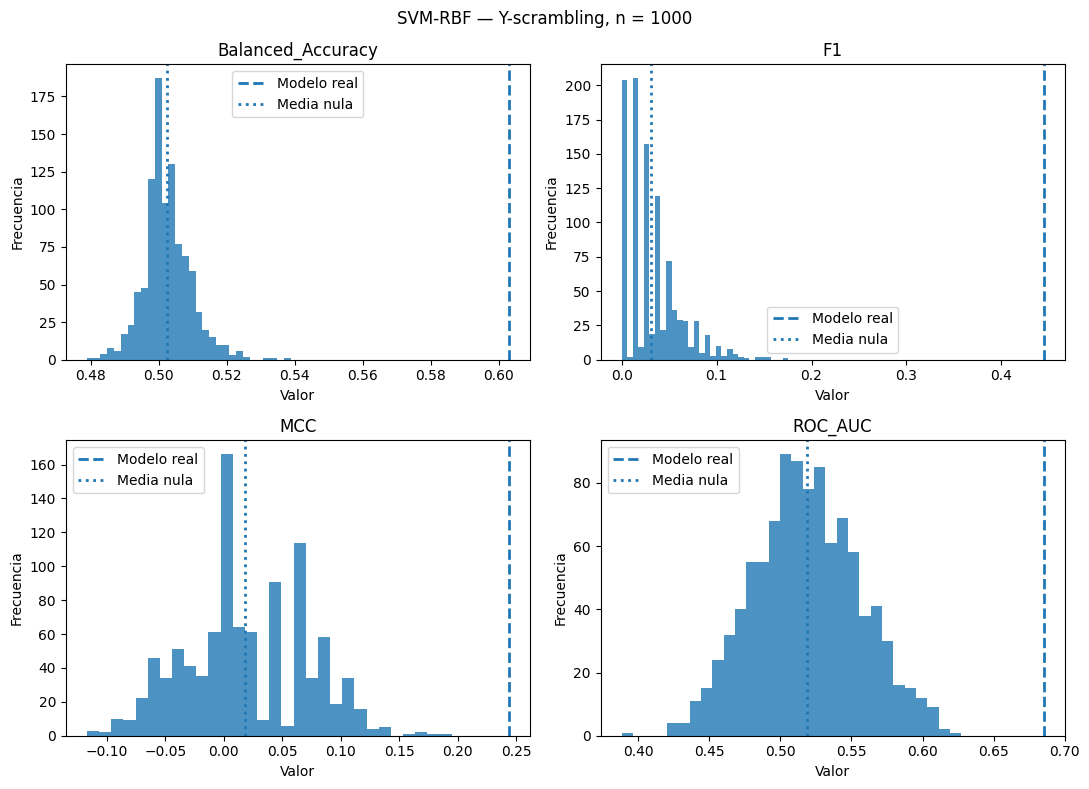

In [ ]:
#Pvalores del yscrambli ng p =1000+11+#(scrambled≥observado)​
scrambling_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "ROC_AUC",
]

scrambling_summary_rows = []

for metric in scrambling_metrics:

    null_values = scrambling_results[
        metric
    ].to_numpy()

    observed = observed_values[
        metric
    ]

    empirical_p = (
        1
        + np.sum(
            null_values >= observed
        )
    ) / (
        N_SCRAMBLING + 1
    )

    scrambling_summary_rows.append({
        "Metric": metric,
        "Observed": observed,
        "Null_Mean": null_values.mean(),
        "Null_SD": null_values.std(ddof=1),
        "Null_95%": np.percentile(
            null_values,
            95,
        ),
        "Empirical_p": empirical_p,
    })

scrambling_summary = pd.DataFrame(
    scrambling_summary_rows
)

display(
    scrambling_summary.round(4)
)
metrics_scrambling_plot = [
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.ravel()

for ax, metric in zip(
    axes,
    metrics_scrambling_plot,
):

    ax.hist(
        scrambling_results[metric],
        bins=30,
        alpha=0.80,
    )

    ax.axvline(
        observed_values[metric],
        linestyle="--",
        linewidth=2,
        label="Modelo real",
    )

    ax.axvline(
        scrambling_results[metric].mean(),
        linestyle=":",
        linewidth=2,
        label="Media nula",
    )

    ax.set_title(metric)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.suptitle(
    "SVM-RBF — Y-scrambling, n = 1000"
)

plt.tight_layout()
plt.show()

##Validación externa DEF

In [ ]:
#Requisitos previos o configuración final
FINAL_C = 1.0
FINAL_GAMMA = "scale"
FINAL_CLASS_WEIGHT = None

FINAL_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

print("Configuración congelada")
print("C:", FINAL_C)
print("gamma:", FINAL_GAMMA)
print("class_weight:", FINAL_CLASS_WEIGHT)
print("features:", FINAL_FEATURES)

Configuración congelada
C: 1.0
gamma: scale
class_weight: None
features: ['ph', 'Hardness', 'Sulfate', 'Conductivity']


In [ ]:
#Cargamos el modelo fina
X_development = (
    df_model[FINAL_FEATURES]
    .copy()
)

y_development = (
    df_model[TARGET]
    .astype(int)
    .copy()
)

X_external = (
    df_ircach_21[FINAL_FEATURES]
    .copy()
)

y_external = (
    df_ircach_21[TARGET]
    .astype(int)
    .copy()
)

final_svm_external = Pipeline(
    steps=[
        (
            "variance",
            VarianceThreshold(
                threshold=0.0
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=FINAL_C,
                gamma=FINAL_GAMMA,
                class_weight=FINAL_CLASS_WEIGHT,
                probability=False,
                random_state=SEED,
            ),
        ),
    ]
)

final_svm_external.fit(
    X_development,
    y_development,
)

print("Modelo reajustado con todo el desarrollo.")
print("Development:", X_development.shape)
print("External:", X_external.shape)

Modelo reajustado con todo el desarrollo.
Development: (2011, 4)
External: (21, 4)


In [ ]:
#Brier
external_calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

final_calibrated_external = CalibratedClassifierCV(
    estimator=clone(final_svm_external),
    method="sigmoid",
    cv=external_calibration_cv,
    n_jobs=-1,
)

final_calibrated_external.fit(
    X_development,
    y_development,
)

print("Calibración completada usando solo Kaggle.")

Calibración completada usando solo Kaggle.


In [ ]:
#Predicción IRcarch o dataset externo que tenemos
y_external_pred = final_svm_external.predict(
    X_external
)

y_external_score = final_svm_external.decision_function(
    X_external
)

y_external_probability = (
    final_calibrated_external
    .predict_proba(X_external)[:, 1]
)

print("Predicciones externas completadas.")
print("Número de muestras:", len(y_external_pred))

Predicciones externas completadas.
Número de muestras: 21


,Dataset,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,MCC,ROC_AUC,Brier_Score,Unsafe_Acceptance_Rate,TN,FP,FN,TP
0,IRCACH_CR_EXT_21,0.5238,0.5833,1.0000,0.1667,1.0000,0.2857,0.2810,0.6111,0.2457,0.0000,9,0,10,2


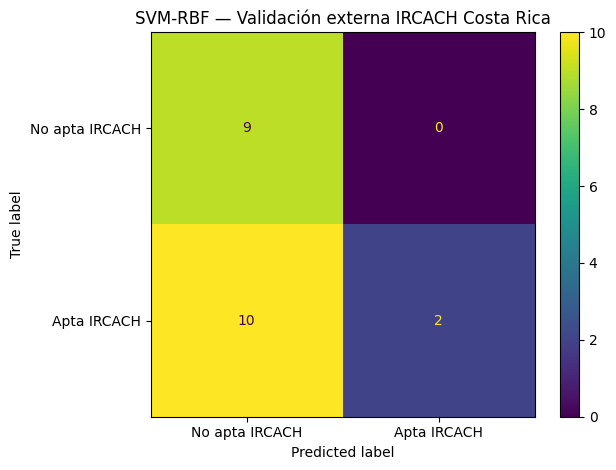

                precision    recall  f1-score   support

No apta IRCACH     0.4737    1.0000    0.6429         9
   Apta IRCACH     1.0000    0.1667    0.2857        12

      accuracy                         0.5238        21
     macro avg     0.7368    0.5833    0.4643        21
  weighted avg     0.7744    0.5238    0.4388        21



In [ ]:
#Métrica entre otras
external_tn, external_fp, external_fn, external_tp = (
    confusion_matrix(
        y_external,
        y_external_pred,
        labels=[0, 1],
    ).ravel()
)

external_specificity = (
    external_tn
    / (external_tn + external_fp)
)

external_unsafe_acceptance = (
    external_fp
    / (external_tn + external_fp)
)

external_results = pd.DataFrame(
    [
        {
            "Dataset": "IRCACH_CR_EXT_21",

            "Accuracy":
                accuracy_score(
                    y_external,
                    y_external_pred,
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_external,
                    y_external_pred,
                ),

            "Precision":
                precision_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "Recall":
                recall_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "Specificity":
                external_specificity,

            "F1":
                f1_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "MCC":
                matthews_corrcoef(
                    y_external,
                    y_external_pred,
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_external,
                    y_external_score,
                ),

            "Brier_Score":
                brier_score_loss(
                    y_external,
                    y_external_probability,
                ),

            "Unsafe_Acceptance_Rate":
                external_unsafe_acceptance,

            "TN": external_tn,
            "FP": external_fp,
            "FN": external_fn,
            "TP": external_tp,
        }
    ]
)

display(
    external_results.round(4)
)

ConfusionMatrixDisplay.from_predictions(
    y_external,
    y_external_pred,
    labels=[0, 1],
    display_labels=[
        "No apta IRCACH",
        "Apta IRCACH",
    ],
    values_format="d",
)

plt.title(
    "SVM-RBF — Validación externa IRCACH Costa Rica"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y_external,
        y_external_pred,
        target_names=[
            "No apta IRCACH",
            "Apta IRCACH",
        ],
        digits=4,
        zero_division=0,
    )
)

In [ ]:
#Holyshit, si logramos tenemos señal predictiva. Ahora hacemos una tablita de prediccioens
def assign_error_type(
    true_label,
    predicted_label,
):

    if true_label == 0 and predicted_label == 0:
        return "Correcta_no_apta"

    if true_label == 1 and predicted_label == 1:
        return "Correcta_apta"

    if true_label == 0 and predicted_label == 1:
        return "Aceptacion_insegura"

    return "Rechazo_conservador"


external_predictions = (
    df_ircach_21
    .copy()
)

external_predictions[
    "Predicted_Potability"
] = y_external_pred

external_predictions[
    "Decision_Score"
] = y_external_score

external_predictions[
    "Probability_Potable"
] = y_external_probability

external_predictions[
    "Correct"
] = (
    external_predictions["Potability"]
    ==
    external_predictions["Predicted_Potability"]
)

external_predictions[
    "Error_Type"
] = [
    assign_error_type(
        true_label,
        predicted_label,
    )
    for true_label, predicted_label
    in zip(
        external_predictions["Potability"],
        external_predictions["Predicted_Potability"],
    )
]

print(
    external_predictions[
        "Error_Type"
    ].value_counts()
)

display_columns = [
    column
    for column in [
        "External_ID",
        "AYA_ID",
        "system_name",
        "sampling_point",
        "IRCACH_score",
        "IRCACH_risk_level",
        "ph",
        "Hardness",
        "Sulfate",
        "Conductivity",
        "Potability",
        "Predicted_Potability",
        "Probability_Potable",
        "Decision_Score",
        "Error_Type",
    ]
    if column in external_predictions.columns
]

display(
    external_predictions[
        display_columns
    ]
    .sort_values(
        [
            "Error_Type",
            "Probability_Potable",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
)

Error_Type
Rechazo_conservador    10
Correcta_no_apta        9
Correcta_apta           2
Name: count, dtype: int64


,External_ID,AYA_ID,system_name,sampling_point,IRCACH_score,IRCACH_risk_level,ph,Hardness,Sulfate,Conductivity,Potability,Predicted_Potability,Probability_Potable,Decision_Score,Error_Type
15,CR_IRCACH_023,AYA-ID-08939-2016,"CH-A-28-COLORADO, RAIZAL E HIGUERILLA",RAIZAL,3,Riesgo muy bajo,7.7600,195.0000,8.6600,448.0000,1,1,0.5423,0.0147,Correcta_apta
17,CR_IRCACH_025,AYA-ID-08735-2016,CH-A-38-PAPAGAYO SUR: HERMOSA - CACIQUE,HERMOSA,4,Riesgo muy bajo,8.2400,228.0000,6.6400,413.0000,1,1,0.5403,0.0040,Correcta_apta
20,CR_IRCACH_028,AYA-ID-07791-2016,HA-A-01-ACUEDUCTO INTEGRADO HONE CREEK – PUERT...,PUERTO VIEJO,14,Riesgo intermedio,7.6900,157.0000,11.6200,763.0000,0,0,0.5304,-0.0422,Correcta_no_apta
19,CR_IRCACH_027,AYA-ID-08247-2016,CH-A-56-CURUBANDÉ DE LIBERIA,RED 1,38,Riesgo muy alto,5.5000,95.0000,101.8100,263.0000,0,0,0.5303,-0.0435,Correcta_no_apta
0,CR_IRCACH_003,AYA-ID-06812-2016,SAN LUIS Y CAIMITOS DE FLORENCIA DE SAN CARLOS,RED 2,27,Riesgo alto,7.0800,56.0000,2.1300,103.0000,0,0,0.5289,-0.0492,Correcta_no_apta
5,CR_IRCACH_011,AYA-ID-05086-2016,CALLE HIGUERONES DE ESCAZÚ (No clorado),SECTOR CALLE A LA NACIENTE,35,Riesgo muy alto,7.8500,46.0000,7.2400,100.0000,0,0,0.5289,-0.0492,Correcta_no_apta
4,CR_IRCACH_010,AYA-ID-06567-2016,CALLE EL ALTO DE ESCAZÚ (No clorado),RED 2,27,Riesgo alto,7.7200,22.0000,22.1000,76.0000,0,0,0.5289,-0.0492,Correcta_no_apta
1,CR_IRCACH_004,AYA-ID-08736-2016,CH-A-38-PAPAGAYO SUR: HERMOSA - CACIQUE,PANAMÁ,44,Riesgo muy alto,7.4700,6367.0000,297.3300,11090.0000,0,0,0.5289,-0.0492,Correcta_no_apta
16,CR_IRCACH_024,AYA-ID-03720-2016,PAPAGAYO SUR-SISTEMA EL DUENDE,RED 2,34,Riesgo muy alto,7.1500,1088.0000,55.5000,2251.0000,0,0,0.5289,-0.0492,Correcta_no_apta
9,CR_IRCACH_017,AYA-ID-07493-2016,SANTA CECILIA DE SAN MARCOS DE TARRAZÚ,RED 2,43,Riesgo muy alto,4.4600,6.0000,17.9900,101.0000,0,0,0.5289,-0.0492,Correcta_no_apta


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
)

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)


# ------------------------------------------------------------
# RUTAS
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/Quanthaton")
OUTPUT_DIR = ROOT / "Water_QML_Final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = ROOT / "water_potability_complete_cases.csv"

if not DATA_PATH.exists():
    matches = list(
        ROOT.glob("*complete*cases*.csv")
    )

    if not matches:
        raise FileNotFoundError(
            "No encontré el CSV de casos completos."
        )

    DATA_PATH = matches[0]


# ------------------------------------------------------------
# CONFIGURACIÓN
# ------------------------------------------------------------

SEED = 4524
TEST_SIZE = 0.20
N_SPLITS = 5
N_REPEATS = 3

FEATURES_RAW = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity",
]

TARGET = "Potability"


# ------------------------------------------------------------
# CARGAR DATOS
# ------------------------------------------------------------

df_model = pd.read_csv(DATA_PATH)

df_model = (
    df_model[
        FEATURES_RAW + [TARGET]
    ]
    .dropna()
    .reset_index(drop=True)
)

df_model.insert(
    0,
    "Sample_ID",
    [f"WP_{i:04d}" for i in range(1, len(df_model) + 1)],
)


# ------------------------------------------------------------
# RECREAR SPLIT CONGELADO
# ------------------------------------------------------------

indices = np.arange(len(df_model))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=df_model[TARGET],
)

df_train = df_model.iloc[train_idx].reset_index(drop=True)
df_test = df_model.iloc[test_idx].reset_index(drop=True)

X_train_raw = df_train[FEATURES_RAW].copy()
y_train = df_train[TARGET].astype(int).to_numpy()

X_test_raw = df_test[FEATURES_RAW].copy()
y_test = df_test[TARGET].astype(int).to_numpy()


# ------------------------------------------------------------
# RECREAR LOS 15 FOLDS
# ------------------------------------------------------------

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=SEED,
)

cv_splits = list(
    cv.split(X_train_raw, y_train)
)


# ------------------------------------------------------------
# MÉTRICAS Y GRILLA
# ------------------------------------------------------------

scoring = {
    "accuracy": make_scorer(accuracy_score),

    "balanced_accuracy": make_scorer(
        balanced_accuracy_score
    ),

    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),

    "mcc": make_scorer(
        matthews_corrcoef
    ),

    "roc_auc": "roc_auc",

    "specificity": make_scorer(
        recall_score,
        pos_label=0,
        zero_division=0,
    ),
}

PARAM_GRID = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", "auto", 0.01],
    "svc__class_weight": [None, "balanced"],
}


# ------------------------------------------------------------
# CONTROL
# ------------------------------------------------------------

assert len(df_model) == 2011
assert X_train_raw.shape == (1608, 9)
assert X_test_raw.shape == (403, 9)
assert len(cv_splits) == 15

print("Entorno Common-4 reactivado.")
print(f"Dataset: {DATA_PATH.name}")
print(f"Train:   {X_train_raw.shape}")
print(f"Test:    {X_test_raw.shape}")
print(f"Folds:   {len(cv_splits)}")
print(f"Salida:  {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno Common-4 reactivado.
Dataset: water_potability_complete_cases.csv
Train:   (1608, 9)
Test:    (403, 9)
Folds:   15
Salida:  /content/drive/MyDrive/Quanthaton/Water_QML_Final


#Validaciones

In [ ]:
import time
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


# ------------------------------------------------------------
# 1. REPRESENTACIÓN COMMON-4
# ------------------------------------------------------------

COMMON4_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]


# ------------------------------------------------------------
# 2. PIPELINE
# ------------------------------------------------------------

pipeline_common4 = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "svc",
            SVC(kernel="rbf"),
        ),
    ]
)


# ------------------------------------------------------------
# 3. GRID SEARCH
# ------------------------------------------------------------

print("=" * 72)
print("AJUSTANDO COMMON-4")
print("=" * 72)

start = time.time()

search_common4 = GridSearchCV(
    estimator=pipeline_common4,
    param_grid=PARAM_GRID,
    scoring=scoring,
    refit="balanced_accuracy",
    cv=cv_splits,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)

search_common4.fit(
    X_train_raw[COMMON4_FEATURES],
    y_train,
)

elapsed = time.time() - start

best_idx = search_common4.best_index_
results = search_common4.cv_results_


# ------------------------------------------------------------
# 4. RESULTADOS POR FOLD
# ------------------------------------------------------------

fold_rows = []

for i in range(len(cv_splits)):

    specificity = results[
        f"split{i}_test_specificity"
    ][best_idx]

    fold_rows.append({
        "Model": "Common-4",
        "Split_Number": i + 1,
        "Repeat": i // N_SPLITS + 1,
        "Fold": i % N_SPLITS + 1,

        "Accuracy": results[
            f"split{i}_test_accuracy"
        ][best_idx],

        "Balanced_Accuracy": results[
            f"split{i}_test_balanced_accuracy"
        ][best_idx],

        "Precision": results[
            f"split{i}_test_precision"
        ][best_idx],

        "Recall": results[
            f"split{i}_test_recall"
        ][best_idx],

        "F1": results[
            f"split{i}_test_f1"
        ][best_idx],

        "MCC": results[
            f"split{i}_test_mcc"
        ][best_idx],

        "ROC_AUC": results[
            f"split{i}_test_roc_auc"
        ][best_idx],

        "Specificity": specificity,

        "Unsafe_Acceptance": 1 - specificity,
    })

common4_folds = pd.DataFrame(fold_rows)


# ------------------------------------------------------------
# 5. RESUMEN
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "ROC_AUC",
    "Specificity",
    "Unsafe_Acceptance",
]

summary = {
    "Model": "Common-4",
    "Features": ", ".join(COMMON4_FEATURES),
    "Best_C": search_common4.best_params_["svc__C"],
    "Best_Gamma": search_common4.best_params_["svc__gamma"],
    "Best_Class_Weight": str(
        search_common4.best_params_["svc__class_weight"]
    ),
    "Elapsed_Seconds": elapsed,
}

for metric in metrics:

    values = common4_folds[metric].to_numpy()

    summary[f"{metric}_Mean"] = values.mean()
    summary[f"{metric}_SD"] = values.std(ddof=1)

common4_summary = pd.DataFrame([summary])


# ------------------------------------------------------------
# 6. COMPARACIÓN CON RAW-9 CONGELADO
# ------------------------------------------------------------

RAW9_CV_BA = 0.6537

common4_ba = float(
    common4_summary[
        "Balanced_Accuracy_Mean"
    ].iloc[0]
)

delta_raw9 = common4_ba - RAW9_CV_BA


# ------------------------------------------------------------
# 7. GUARDAR
# ------------------------------------------------------------

joblib.dump(
    search_common4.best_estimator_,
    OUTPUT_DIR / "best_common4_cv.joblib",
)

common4_folds.to_csv(
    OUTPUT_DIR / "common4_cv_fold_results.csv",
    index=False,
)

common4_summary.to_csv(
    OUTPUT_DIR / "common4_cv_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 8. RESULTADO
# ------------------------------------------------------------

print(f"Mejor BA:       {search_common4.best_score_:.4f}")
print(f"Mejores params: {search_common4.best_params_}")
print(f"Tiempo:         {elapsed:.2f} s")

display(
    common4_summary[
        [
            "Model",
            "Balanced_Accuracy_Mean",
            "Balanced_Accuracy_SD",
            "MCC_Mean",
            "MCC_SD",
            "ROC_AUC_Mean",
            "F1_Mean",
            "Specificity_Mean",
            "Unsafe_Acceptance_Mean",
        ]
    ].round(4)
)

print(f"\nBA Raw-9:           {RAW9_CV_BA:.4f}")
print(f"BA Common-4:        {common4_ba:.4f}")
print(f"Delta vs Raw-9:     {delta_raw9:+.4f}")

print("\nTest sellado: NO utilizado.")
print("Bloque 6 completado.")

AJUSTANDO COMMON-4
Mejor BA:       0.6381
Mejores params: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale'}
Tiempo:         22.00 s


,Model,Balanced_Accuracy_Mean,Balanced_Accuracy_SD,MCC_Mean,MCC_SD,ROC_AUC_Mean,F1_Mean,Specificity_Mean,Unsafe_Acceptance_Mean
0,Common-4,0.6381,0.0174,0.2872,0.0377,0.6907,0.5468,0.7726,0.2274



BA Raw-9:           0.6537
BA Common-4:        0.6381
Delta vs Raw-9:     -0.0156

Test sellado: NO utilizado.
Bloque 6 completado.


##Crearemos subsets cúanticos

In [ ]:
import numpy as np
import pandas as pd


# Configuración respectiva

QUANTUM_SEED = 4524

QUANTUM_SIZES = [
    16,
    32,
    64,
]

COMMON4_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]


rng = np.random.default_rng(
    QUANTUM_SEED
)


# Separamos los índices del training por clase

class0_indices = np.flatnonzero(
    df_train[TARGET].to_numpy() == 0
)

class1_indices = np.flatnonzero(
    df_train[TARGET].to_numpy() == 1
)


rng.shuffle(
    class0_indices
)

rng.shuffle(
    class1_indices
)


# Hacemos subsets anidados y balanceados

quantum_subsets = {}

manifest_rows = []


for n_samples in QUANTUM_SIZES:

    n_per_class = (
        n_samples
        // 2
    )

    selected_indices = np.concatenate(
        [
            class0_indices[
                :n_per_class
            ],
            class1_indices[
                :n_per_class
            ],
        ]
    )

    # Mezclamos el orden interno sin cambiar las muestras

    local_rng = np.random.default_rng(
        QUANTUM_SEED
        + n_samples
    )

    selected_indices = local_rng.permutation(
        selected_indices
    )

    subset = (
        df_train
        .iloc[
            selected_indices
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    quantum_subsets[
        n_samples
    ] = subset

    for position, row in subset.iterrows():

        manifest_rows.append({
            "Seed": QUANTUM_SEED,
            "N": n_samples,
            "Subset_Position": position,
            "Train_Row_Index": int(
                selected_indices[
                    position
                ]
            ),
            "Sample_ID": row[
                "Sample_ID"
            ],
            TARGET: int(
                row[
                    TARGET
                ]
            ),
        })


subset_manifest = pd.DataFrame(
    manifest_rows
)


# Validaciones respectivas

for n_samples, subset in quantum_subsets.items():

    counts = (
        subset[
            TARGET
        ]
        .value_counts()
        .sort_index()
    )

    assert (
        len(subset)
        == n_samples
    )

    assert (
        counts.loc[0]
        == n_samples // 2
    )

    assert (
        counts.loc[1]
        == n_samples // 2
    )

    assert subset[
        "Sample_ID"
    ].is_unique


ids_16 = set(
    quantum_subsets[
        16
    ][
        "Sample_ID"
    ]
)

ids_32 = set(
    quantum_subsets[
        32
    ][
        "Sample_ID"
    ]
)

ids_64 = set(
    quantum_subsets[
        64
    ][
        "Sample_ID"
    ]
)


assert ids_16.issubset(
    ids_32
)

assert ids_32.issubset(
    ids_64
)


# Guardamos los resultados

subset_manifest.to_csv(
    OUTPUT_DIR
    / "quantum_subset_manifest_seed4524.csv",
    index=False,
)


for n_samples, subset in quantum_subsets.items():

    subset.to_csv(
        OUTPUT_DIR
        / f"quantum_subset_N{n_samples}_seed4524.csv",
        index=False,
    )


summary_rows = []


for n_samples, subset in quantum_subsets.items():

    counts = subset[
        TARGET
    ].value_counts()

    summary_rows.append({
        "N": n_samples,
        "Class_0": int(
            counts.get(
                0,
                0,
            )
        ),
        "Class_1": int(
            counts.get(
                1,
                0,
            )
        ),
        "Nested": True,
    })


quantum_subset_summary = pd.DataFrame(
    summary_rows
)


display(
    quantum_subset_summary
)


print(
    "Subsets cuánticos creados correctamente."
)

print(
    "N=16 ⊂ N=32 ⊂ N=64"
)

print(
    "Test sellado: NO utilizado."
)

print(
    f"Archivos guardados en: {OUTPUT_DIR}"
)

,N,Class_0,Class_1,Nested
0,16,8,8,True
1,32,16,16,True
2,64,32,32,True


Subsets cuánticos creados correctamente.
N=16 ⊂ N=32 ⊂ N=64
Test sellado: NO utilizado.
Archivos guardados en: /content/drive/MyDrive/Quanthaton/Water_QML_Final


#Probar SVMRBF para los distintos tipos de muestras.

In [ ]:
# SVM-RBF para los 3 subsets

import time
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
)


# Configuración

INNER_SPLITS = 4
INNER_REPEATS = 5

SUBSET_PARAM_GRID = {
    "svc__C": [
        0.1,
        1,
        10,
    ],
    "svc__gamma": [
        "scale",
        "auto",
        0.01,
    ],
    "svc__class_weight": [
        None,
        "balanced",
    ],
}


# Contenedores respectivos

subset_svm_searches = {}
subset_cv_splits = {}

summary_rows = []
fold_rows = []


# Ajustamos el SVM para cada N

for n_samples in QUANTUM_SIZES:

    print("\n" + "=" * 72)
    print(f"SVM-RBF SUBSET — N = {n_samples}")
    print("=" * 72)

    subset = quantum_subsets[
        n_samples
    ]

    X_subset = subset[
        COMMON4_FEATURES
    ].copy()

    y_subset = (
        subset[
            TARGET
        ]
        .astype(int)
        .to_numpy()
    )


    # CV interna congelada

    inner_cv = RepeatedStratifiedKFold(
        n_splits=INNER_SPLITS,
        n_repeats=INNER_REPEATS,
        random_state=(
            QUANTUM_SEED
            + n_samples
        ),
    )

    inner_splits = list(
        inner_cv.split(
            X_subset,
            y_subset,
        )
    )

    subset_cv_splits[
        n_samples
    ] = inner_splits


    # Pipeline clásico

    pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "svc",
                SVC(
                    kernel="rbf",
                ),
            ),
        ]
    )


    # GridSearch

    start = time.time()

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=SUBSET_PARAM_GRID,
        scoring=scoring,
        refit="balanced_accuracy",
        cv=inner_splits,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise",
    )

    search.fit(
        X_subset,
        y_subset,
    )

    elapsed = (
        time.time()
        - start
    )

    subset_svm_searches[
        n_samples
    ] = search

    best_idx = search.best_index_
    results = search.cv_results_


    # Resultados por partición

    for split_number in range(
        len(inner_splits)
    ):

        specificity = results[
            f"split{split_number}_test_specificity"
        ][best_idx]

        fold_rows.append({
            "Seed": QUANTUM_SEED,
            "N": n_samples,
            "Split_Number": split_number + 1,

            "Balanced_Accuracy": results[
                f"split{split_number}_test_balanced_accuracy"
            ][best_idx],

            "MCC": results[
                f"split{split_number}_test_mcc"
            ][best_idx],

            "F1": results[
                f"split{split_number}_test_f1"
            ][best_idx],

            "ROC_AUC": results[
                f"split{split_number}_test_roc_auc"
            ][best_idx],

            "Specificity": specificity,

            "Unsafe_Acceptance": (
                1.0
                - specificity
            ),
        })


    # Resumen respectivo

    summary_rows.append({
        "Seed": QUANTUM_SEED,
        "N": n_samples,

        "Best_C": search.best_params_[
            "svc__C"
        ],

        "Best_Gamma": search.best_params_[
            "svc__gamma"
        ],

        "Best_Class_Weight": str(
            search.best_params_[
                "svc__class_weight"
            ]
        ),

        "CV_BA_Mean": search.best_score_,

        "CV_BA_SD": results[
            "std_test_balanced_accuracy"
        ][best_idx],

        "CV_MCC_Mean": results[
            "mean_test_mcc"
        ][best_idx],

        "CV_F1_Mean": results[
            "mean_test_f1"
        ][best_idx],

        "CV_ROC_AUC_Mean": results[
            "mean_test_roc_auc"
        ][best_idx],

        "Elapsed_Seconds": elapsed,
    })


    # Guardar el mejor modelo

    joblib.dump(
        search.best_estimator_,
        OUTPUT_DIR
        / f"svm_rbf_common4_N{n_samples}_seed4524.joblib",
    )

    print(
        f"BA CV:          "
        f"{search.best_score_:.4f}"
    )

    print(
        f"Mejores params: "
        f"{search.best_params_}"
    )

    print(
        f"Tiempo:         "
        f"{elapsed:.2f} s"
    )


# Tablas finales

subset_svm_summary = pd.DataFrame(
    summary_rows
)

subset_svm_folds = pd.DataFrame(
    fold_rows
)


joblib.dump(
    subset_cv_splits,
    OUTPUT_DIR
    / "quantum_subset_inner_cv_splits_seed4524.joblib",
)

subset_svm_summary.to_csv(
    OUTPUT_DIR
    / "svm_rbf_subset_summary_seed4524.csv",
    index=False,
)

subset_svm_folds.to_csv(
    OUTPUT_DIR
    / "svm_rbf_subset_fold_results_seed4524.csv",
    index=False,
)


print("\n" + "=" * 72)
print("RESUMEN SVM-RBF POR TAMAÑO")
print("=" * 72)

display(
    subset_svm_summary[
        [
            "N",
            "Best_C",
            "Best_Gamma",
            "Best_Class_Weight",
            "CV_BA_Mean",
            "CV_BA_SD",
            "CV_MCC_Mean",
            "CV_F1_Mean",
            "CV_ROC_AUC_Mean",
        ]
    ].round(4)
)

print(
    "\nFolds internos guardados para reutilizarlos en QSVM."
)

print(
    "Test sellado: NO utilizado."
)

print(
    "Bloque 8 completado."
)


SVM-RBF SUBSET — N = 16
BA CV:          0.5750
Mejores params: {'svc__C': 0.1, 'svc__class_weight': None, 'svc__gamma': 'scale'}
Tiempo:         7.51 s

SVM-RBF SUBSET — N = 32
BA CV:          0.4875
Mejores params: {'svc__C': 10, 'svc__class_weight': None, 'svc__gamma': 0.01}
Tiempo:         4.65 s

SVM-RBF SUBSET — N = 64
BA CV:          0.6219
Mejores params: {'svc__C': 1, 'svc__class_weight': None, 'svc__gamma': 'scale'}
Tiempo:         4.76 s

RESUMEN SVM-RBF POR TAMAÑO


,N,Best_C,Best_Gamma,Best_Class_Weight,CV_BA_Mean,CV_BA_SD,CV_MCC_Mean,CV_F1_Mean,CV_ROC_AUC_Mean
0,16,0.1,scale,None,0.5750,0.1601,0.1732,0.4650,0.4875
1,32,10.0,0.01,None,0.4875,0.1364,-0.0109,0.3594,0.4469
2,64,1.0,scale,None,0.6219,0.0937,0.2499,0.5659,0.6102



Folds internos guardados para reutilizarlos en QSVM.
Test sellado: NO utilizado.
Bloque 8 completado.


#SVMRBF VON VARIOS FOLDS


In [ ]:
import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    recall_score,
    roc_auc_score,
)
#cONFIG
RBF_C = 1.0
RBF_GAMMA = "scale"
RBF_CLASS_WEIGHT = None

fixed_rbf_rows = []

#Evaluación por N  y FOLD
for n_samples in QUANTUM_SIZES:

    print("\n" + "=" * 72)
    print(f"SVM-RBF FIJA — N = {n_samples}")
    print("=" * 72)

    subset = quantum_subsets[n_samples]

    X = subset[
        COMMON4_FEATURES
    ].copy()

    y = subset[
        TARGET
    ].astype(int).to_numpy()

    inner_splits = subset_cv_splits[n_samples]

    start = time.time()

    for split_number, (
        train_fold_idx,
        val_fold_idx,
    ) in enumerate(inner_splits, start=1):

        X_fold_train = X.iloc[train_fold_idx]
        X_fold_val = X.iloc[val_fold_idx]

        y_fold_train = y[train_fold_idx]
        y_fold_val = y[val_fold_idx]
#Pipeline sin el tuning

        model = Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "svc",
                    SVC(
                        kernel="rbf",
                        C=RBF_C,
                        gamma=RBF_GAMMA,
                        class_weight=RBF_CLASS_WEIGHT,
                    ),
                ),
            ]
        )

        model.fit(
            X_fold_train,
            y_fold_train,
        )

        y_pred = model.predict(
            X_fold_val
        )

        decision_scores = model.decision_function(
            X_fold_val
        )
#Métricas
        ba = balanced_accuracy_score(
            y_fold_val,
            y_pred,
        )

        mcc = matthews_corrcoef(
            y_fold_val,
            y_pred,
        )

        f1 = f1_score(
            y_fold_val,
            y_pred,
            zero_division=0,
        )

        specificity = recall_score(
            y_fold_val,
            y_pred,
            pos_label=0,
            zero_division=0,
        )

        unsafe_acceptance = (
            1.0
            - specificity
        )

        if n_samples >= 32:

            auc = roc_auc_score(
                y_fold_val,
                decision_scores,
            )

        else:
            auc = np.nan


        fixed_rbf_rows.append({
            "Seed": QUANTUM_SEED,
            "N": n_samples,
            "Split_Number": split_number,
            "C": RBF_C,
            "Gamma": RBF_GAMMA,
            "Class_Weight": str(
                RBF_CLASS_WEIGHT
            ),
            "Balanced_Accuracy": ba,
            "MCC": mcc,
            "F1": f1,
            "ROC_AUC": auc,
            "Specificity": specificity,
            "Unsafe_Acceptance": unsafe_acceptance,
        })


    elapsed = time.time() - start

    print(
        f"Tiempo total: {elapsed:.2f} s"
    )
#Resultados por  FOLD

fixed_rbf_folds = pd.DataFrame(
    fixed_rbf_rows
)
#Resumen por n
fixed_rbf_summary = (
    fixed_rbf_folds
    .groupby("N", as_index=False)
    .agg(
        CV_BA_Mean=(
            "Balanced_Accuracy",
            "mean",
        ),
        CV_BA_SD=(
            "Balanced_Accuracy",
            "std",
        ),
        CV_MCC_Mean=(
            "MCC",
            "mean",
        ),
        CV_MCC_SD=(
            "MCC",
            "std",
        ),
        CV_F1_Mean=(
            "F1",
            "mean",
        ),
        CV_ROC_AUC_Mean=(
            "ROC_AUC",
            "mean",
        ),
        CV_Specificity_Mean=(
            "Specificity",
            "mean",
        ),
        CV_Unsafe_Acceptance_Mean=(
            "Unsafe_Acceptance",
            "mean",
        ),
    )
)
#GUadamos y mostramos
fixed_rbf_folds.to_csv(
    OUTPUT_DIR
    / "svm_rbf_fixed_fold_results_seed4524.csv",
    index=False,
)

fixed_rbf_summary.to_csv(
    OUTPUT_DIR
    / "svm_rbf_fixed_summary_seed4524.csv",
    index=False,
)
display(
    fixed_rbf_summary.round(4)
)

print("\nConfiguración congelada:")
print("C = 1")
print("gamma = scale")
print("class_weight = None")
print("Mismos IDs y folds que usará la QSVM.")
print("Test sellado: NO utilizado.")
print("Bloque 8B completado.")


SVM-RBF FIJA — N = 16
Tiempo total: 0.21 s

SVM-RBF FIJA — N = 32
Tiempo total: 0.24 s

SVM-RBF FIJA — N = 64
Tiempo total: 0.22 s


,N,CV_BA_Mean,CV_BA_SD,CV_MCC_Mean,CV_MCC_SD,CV_F1_Mean,CV_ROC_AUC_Mean,CV_Specificity_Mean,CV_Unsafe_Acceptance_Mean
0,16,0.5500,0.1308,0.1155,0.3020,0.4267,NaN,0.625,0.375
1,32,0.4438,0.1374,-0.1216,0.3231,0.3892,0.4125,0.475,0.525
2,64,0.6219,0.0961,0.2499,0.1971,0.5659,0.6102,0.725,0.275



Configuración congelada:
C = 1
gamma = scale
class_weight = None
Mismos IDs y folds que usará la QSVM.
Test sellado: NO utilizado.
Bloque 8B completado.


##Vamos con el entorno de qiskit y los circuitos respectivos

In [ ]:
%pip install -q "qiskit>=2.1,<3" pylatexenc

import importlib.metadata as metadata
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import (
    zz_feature_map,
    pauli_feature_map,
)
#Congelamos la configuración
N_QUBITS = 4
FEATURE_MAP_REPS = 1
FEATURE_MAP_ALPHA = 1.0

CUSTOM_EDGES = [
    (0, 1),  # pH — Hardness
    (1, 3),  # Hardness — Conductivity
    (2, 3),  # Sulfate — Conductivity
]

#Montamos el DATAMAP
def product_data_map(x):
    """
    Una variable: theta_i
    Varias variables: producto theta_i * theta_j * ...
    """
    if len(x) == 1:
        return x[0]

    value = x[0]

    for element in x[1:]:
        value = value * element

    return value
#Hacemos el control separable
theta_sep = ParameterVector(
    "theta_sep",
    N_QUBITS,
)

separable_map = QuantumCircuit(
    N_QUBITS,
    name="Separable_Control",
)

for qubit in range(N_QUBITS):
    separable_map.ry(
        theta_sep[qubit],
        qubit,
    )
    separable_map.rz(
        theta_sep[qubit],
        qubit,
    )
# 4. ZZ FEATURE MAP
zz_map = zz_feature_map(
    feature_dimension=N_QUBITS,
    reps=FEATURE_MAP_REPS,
    entanglement="linear",
    alpha=FEATURE_MAP_ALPHA,
    data_map_func=product_data_map,
    parameter_prefix="theta_zz",
    name="ZZ_Linear",
)
#PauliZ y YY featuremap correspondiente
pauli_map = pauli_feature_map(
    feature_dimension=N_QUBITS,
    reps=FEATURE_MAP_REPS,
    entanglement="linear",
    alpha=FEATURE_MAP_ALPHA,
    paulis=["Z", "YY"],
    data_map_func=product_data_map,
    parameter_prefix="theta_pauli",
    name="Pauli_Z_YY",
)
#Hacemos el feature map personalizado
theta_custom = ParameterVector(
    "theta_custom",
    N_QUBITS,
)

custom_map = QuantumCircuit(
    N_QUBITS,
    name="Custom_Domain",
)

# Codificación individual: RY → RZ
for qubit in range(N_QUBITS):

    custom_map.ry(
        theta_custom[qubit],
        qubit,
    )

    custom_map.rz(
        theta_custom[qubit],
        qubit,
    )


# Interacciones dispersas
for qubit_i, qubit_j in CUSTOM_EDGES:

    custom_map.rzz(
        theta_custom[qubit_i]
        * theta_custom[qubit_j],
        qubit_i,
        qubit_j,
    )
#Centro
FEATURE_MAPS = {
    "Separable_Control": separable_map,
    "ZZ_Linear": zz_map,
    "Pauli_Z_YY": pauli_map,
    "Custom_Domain": custom_map,
}
#Verificamos y vemos los resultados
audit_rows = []

for map_name, circuit in FEATURE_MAPS.items():

    assert circuit.num_qubits == 4
    assert circuit.num_parameters == 4
    assert circuit.num_clbits == 0

    parameters = list(
        circuit.parameters
    )

    test_values = {
        parameter: 0.1 * (index + 1)
        for index, parameter
        in enumerate(parameters)
    }

    bound_circuit = circuit.assign_parameters(
        test_values,
        inplace=False,
    )

    assert bound_circuit.num_parameters == 0

    decomposed = circuit.decompose(
        reps=10
    )

    two_qubit_gates = sum(
        instruction.operation.num_qubits == 2
        for instruction in decomposed.data
    )

    audit_rows.append({
        "Feature_Map": map_name,
        "Qubits": circuit.num_qubits,
        "Parameters": circuit.num_parameters,
        "Depth_Decomposed": decomposed.depth(),
        "Total_Gates_Decomposed": decomposed.size(),
        "Two_Qubit_Gates": two_qubit_gates,
    })


feature_map_audit = pd.DataFrame(
    audit_rows
)

print(
    "Qiskit:",
    metadata.version("qiskit"),
)

display(feature_map_audit)

for map_name, circuit in FEATURE_MAPS.items():

    print("\n" + "=" * 72)
    print(map_name)
    print("=" * 72)

    print(
        circuit.draw(
            output="text",
            fold=140,
        )
    )


print("\nTodos los circuitos cumplen:")
print("- 4 qubits")
print("- 4 parámetros")
print("- sin mediciones")
print("- asignación completa de parámetros")
print("- reps = 1")
print("- alpha = 1")
print("- interacción multivariable = producto de ángulos")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
Qiskit: 2.5.0


,Feature_Map,Qubits,Parameters,Depth_Decomposed,Total_Gates_Decomposed,Two_Qubit_Gates
0,Separable_Control,4,4,2,8,0
1,ZZ_Linear,4,4,11,17,6
2,Pauli_Z_YY,4,4,29,53,6
3,Custom_Domain,4,4,11,17,6



Separable_Control
     ┌──────────────────┐┌──────────────────┐
q_0: ┤ Ry(theta_sep[0]) ├┤ Rz(theta_sep[0]) ├
     ├──────────────────┤├──────────────────┤
q_1: ┤ Ry(theta_sep[1]) ├┤ Rz(theta_sep[1]) ├
     ├──────────────────┤├──────────────────┤
q_2: ┤ Ry(theta_sep[2]) ├┤ Rz(theta_sep[2]) ├
     ├──────────────────┤├──────────────────┤
q_3: ┤ Ry(theta_sep[3]) ├┤ Rz(theta_sep[3]) ├
     └──────────────────┘└──────────────────┘

ZZ_Linear
   ┌───┐┌────────────────┐                                                                                     »
0: ┤ H ├┤ P(theta_zz[0]) ├──■──────────────────────────────────■───────────────────────────────────────────────»
   ├───┤├────────────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐                                             »
1: ┤ H ├┤ P(theta_zz[1]) ├┤ X ├┤ P(theta_zz[0]*theta_zz[1]) ├┤ X ├──■──────────────────────────────────■───────»
   ├───┤├────────────────┤└───┘└────────────────────────────┘└───┘┌─┴─┐┌────────────────────────────┐┌─┴

##Kernels exactos y la auditoria de n 16


In [ ]:
# ============================================================
# BLOQUE 10 — AUDITORÍA EXACTA DE KERNELS, N = 16
# ============================================================

import hashlib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. DATOS DE AUDITORÍA
# ------------------------------------------------------------

AUDIT_N = 16

audit_subset = quantum_subsets[AUDIT_N].copy()

X_audit = audit_subset[
    COMMON4_FEATURES
].to_numpy(dtype=float)

y_audit = audit_subset[
    TARGET
].astype(int).to_numpy()

audit_ids = audit_subset[
    "Sample_ID"
].astype(str).to_numpy()


# ------------------------------------------------------------
# 2. ESCALADO ANGULAR — SOLO AUDITORÍA TÉCNICA
# ------------------------------------------------------------

audit_scaler = StandardScaler()

Z_audit = audit_scaler.fit_transform(
    X_audit
)

Theta_audit = (
    np.pi / 2.0
) * np.tanh(Z_audit)

assert Theta_audit.shape == (16, 4)
assert np.isfinite(Theta_audit).all()
assert np.max(np.abs(Theta_audit)) <= np.pi / 2.0


# ------------------------------------------------------------
# 3. FUNCIONES AUXILIARES
# ------------------------------------------------------------

def statevector_matrix(circuit, theta_matrix):
    """
    Genera un statevector por muestra.
    Filas = muestras; columnas = amplitudes.
    """

    parameter_order = sorted(
        circuit.parameters,
        key=lambda parameter: parameter.name,
    )

    assert len(parameter_order) == 4

    states = []

    for theta_row in theta_matrix:

        parameter_values = dict(
            zip(
                parameter_order,
                theta_row,
            )
        )

        bound_circuit = circuit.assign_parameters(
            parameter_values,
            inplace=False,
        )

        assert bound_circuit.num_parameters == 0

        state = Statevector.from_instruction(
            bound_circuit
        ).data

        norm = np.vdot(
            state,
            state,
        ).real

        if not np.isclose(
            norm,
            1.0,
            atol=1e-10,
        ):
            raise ValueError(
                f"Statevector no normalizado: {norm}"
            )

        states.append(state)

    return np.asarray(
        states,
        dtype=np.complex128,
    )


def fidelity_kernel(statevectors):
    """
    K_ij = |<psi_i|psi_j>|²
    """

    overlaps = (
        statevectors.conj()
        @ statevectors.T
    )

    return np.abs(overlaps) ** 2


def centered_kernel_alignment(K, y):
    """
    Centered Kernel-Target Alignment.
    Labels codificados como {-1, +1}.
    """

    n = len(y)

    H = (
        np.eye(n)
        - np.ones((n, n)) / n
    )

    K_centered = H @ K @ H

    y_pm = (
        2.0 * y.astype(float)
        - 1.0
    )

    Y = np.outer(
        y_pm,
        y_pm,
    )

    Y_centered = H @ Y @ H

    numerator = np.sum(
        K_centered * Y_centered
    )

    denominator = np.sqrt(
        np.sum(K_centered ** 2)
        * np.sum(Y_centered ** 2)
    )

    if denominator == 0:
        return np.nan

    return numerator / denominator


def effective_rank(eigenvalues):
    """
    Effective rank basado en entropía espectral.
    """

    eig = np.clip(
        eigenvalues,
        0.0,
        None,
    )

    total = eig.sum()

    if total == 0:
        return 0.0

    probabilities = eig / total
    probabilities = probabilities[
        probabilities > 0
    ]

    entropy = -np.sum(
        probabilities
        * np.log(probabilities)
    )

    return float(
        np.exp(entropy)
    )


def audit_kernel(K, y):
    """
    Auditoría matemática y geométrica.
    """

    n = K.shape[0]

    diagonal_error = np.max(
        np.abs(
            np.diag(K)
            - 1.0
        )
    )

    symmetry_error = np.max(
        np.abs(
            K
            - K.T
        )
    )

    finite = bool(
        np.isfinite(K).all()
    )

    K_symmetric = (
        K + K.T
    ) / 2.0

    eigenvalues = np.linalg.eigvalsh(
        K_symmetric
    )

    upper_i, upper_j = np.triu_indices(
        n,
        k=1,
    )

    off_diagonal = K[
        upper_i,
        upper_j,
    ]

    same_class = (
        y[upper_i]
        == y[upper_j]
    )

    intra_similarity = np.mean(
        off_diagonal[same_class]
    )

    inter_similarity = np.mean(
        off_diagonal[~same_class]
    )

    off_mean = float(
        np.mean(off_diagonal)
    )

    off_sd = float(
        np.std(
            off_diagonal,
            ddof=1,
        )
    )

    if off_mean > 0.98:
        geometry_status = "COLLAPSED_HIGH"

    elif off_mean < 0.02:
        geometry_status = "NEAR_IDENTITY"

    else:
        geometry_status = "PASS"

    valid_kernel = (
        finite
        and diagonal_error <= 1e-10
        and symmetry_error <= 1e-10
        and np.min(K) >= -1e-10
        and np.max(K) <= 1.0 + 1e-10
        and eigenvalues.min() >= -1e-10
    )

    return {
        "Valid_Kernel": valid_kernel,
        "Geometry_Status": geometry_status,
        "Diagonal_Max_Error": diagonal_error,
        "Symmetry_Max_Error": symmetry_error,
        "Kernel_Min": float(np.min(K)),
        "Kernel_Max": float(np.max(K)),
        "Eigenvalue_Min": float(
            eigenvalues.min()
        ),
        "Eigenvalue_Max": float(
            eigenvalues.max()
        ),
        "Effective_Rank": effective_rank(
            eigenvalues
        ),
        "Offdiag_Mean": off_mean,
        "Offdiag_SD": off_sd,
        "Intra_Class_Mean": float(
            intra_similarity
        ),
        "Inter_Class_Mean": float(
            inter_similarity
        ),
        "Intra_Minus_Inter": float(
            intra_similarity
            - inter_similarity
        ),
        "Centered_KTA": float(
            centered_kernel_alignment(
                K,
                y,
            )
        ),
    }


def centered_kernel_similarity(K1, K2):
    """
    Similitud centrada tipo CKA entre dos kernels.
    """

    n = K1.shape[0]

    H = (
        np.eye(n)
        - np.ones((n, n)) / n
    )

    K1c = H @ K1 @ H
    K2c = H @ K2 @ H

    numerator = np.sum(
        K1c * K2c
    )

    denominator = np.sqrt(
        np.sum(K1c ** 2)
        * np.sum(K2c ** 2)
    )

    if denominator == 0:
        return np.nan

    return numerator / denominator


# ------------------------------------------------------------
# 4. CALCULAR LOS CUATRO KERNELS
# ------------------------------------------------------------

exact_statevectors = {}
exact_kernels = {}
kernel_audit_rows = []

for map_name, circuit in FEATURE_MAPS.items():

    print(
        f"Calculando kernel exacto: {map_name}"
    )

    states = statevector_matrix(
        circuit,
        Theta_audit,
    )

    K = fidelity_kernel(
        states
    )

    audit = audit_kernel(
        K,
        y_audit,
    )

    kernel_hash = hashlib.sha256(
        np.ascontiguousarray(
            K,
            dtype=np.float64,
        ).tobytes()
    ).hexdigest()

    exact_statevectors[map_name] = states
    exact_kernels[map_name] = K

    kernel_audit_rows.append({
        "Feature_Map": map_name,
        "N": AUDIT_N,
        "Kernel_SHA256": kernel_hash,
        **audit,
    })


kernel_audit_N16 = pd.DataFrame(
    kernel_audit_rows
)


# ------------------------------------------------------------
# 5. COMPARACIÓN ENTRE KERNELS
# ------------------------------------------------------------

kernel_names = list(
    exact_kernels.keys()
)

similarity_rows = []

for i, name_a in enumerate(
    kernel_names
):

    for name_b in kernel_names[
        i + 1:
    ]:

        similarity_rows.append({
            "Kernel_A": name_a,
            "Kernel_B": name_b,
            "Centered_Kernel_Similarity":
                centered_kernel_similarity(
                    exact_kernels[name_a],
                    exact_kernels[name_b],
                ),
        })


kernel_similarity_N16 = pd.DataFrame(
    similarity_rows
)


# ------------------------------------------------------------
# 6. GUARDAR RESULTADOS
# ------------------------------------------------------------

angles_table = pd.DataFrame(
    Theta_audit,
    columns=[
        f"Theta_{feature}"
        for feature in COMMON4_FEATURES
    ],
)

angles_table.insert(
    0,
    "Sample_ID",
    audit_ids,
)

angles_table[TARGET] = y_audit

angles_table.to_csv(
    OUTPUT_DIR
    / "audit_angles_N16_seed4524.csv",
    index=False,
)

kernel_audit_N16.to_csv(
    OUTPUT_DIR
    / "exact_kernel_audit_N16_seed4524.csv",
    index=False,
)

kernel_similarity_N16.to_csv(
    OUTPUT_DIR
    / "exact_kernel_similarity_N16_seed4524.csv",
    index=False,
)

for map_name, K in exact_kernels.items():

    safe_name = map_name.lower()

    np.save(
        OUTPUT_DIR
        / f"exact_kernel_{safe_name}_N16_seed4524.npy",
        K,
    )

    pd.DataFrame(
        K,
        index=audit_ids,
        columns=audit_ids,
    ).to_csv(
        OUTPUT_DIR
        / f"exact_kernel_{safe_name}_N16_seed4524.csv"
    )


# ------------------------------------------------------------
# 7. CONTROLES FINALES
# ------------------------------------------------------------

assert kernel_audit_N16[
    "Valid_Kernel"
].all(), (
    "Al menos un kernel exacto no superó "
    "la auditoría matemática."
)


# ------------------------------------------------------------
# 8. MOSTRAR
# ------------------------------------------------------------

print("\n" + "=" * 88)
print("AUDITORÍA DE KERNELS EXACTOS — N=16")
print("=" * 88)

display(
    kernel_audit_N16[
        [
            "Feature_Map",
            "Valid_Kernel",
            "Geometry_Status",
            "Diagonal_Max_Error",
            "Symmetry_Max_Error",
            "Eigenvalue_Min",
            "Effective_Rank",
            "Offdiag_Mean",
            "Offdiag_SD",
            "Intra_Minus_Inter",
            "Centered_KTA",
        ]
    ].round(6)
)

print("\n" + "=" * 88)
print("SIMILITUD ENTRE KERNELS")
print("=" * 88)

display(
    kernel_similarity_N16.round(6)
)

print("\nBloque 10 completado.")
print("Auditoría técnica únicamente.")
print("Todavía no se entrenó ninguna QSVM.")
print("Test sellado: NO utilizado.")

Calculando kernel exacto: Separable_Control
Calculando kernel exacto: ZZ_Linear
Calculando kernel exacto: Pauli_Z_YY
Calculando kernel exacto: Custom_Domain

AUDITORÍA DE KERNELS EXACTOS — N=16


,Feature_Map,Valid_Kernel,Geometry_Status,Diagonal_Max_Error,Symmetry_Max_Error,Eigenvalue_Min,Effective_Rank,Offdiag_Mean,Offdiag_SD,Intra_Minus_Inter,Centered_KTA
0,Separable_Control,True,PASS,0.0,0.0,0.062877,6.119425,0.471644,0.139384,0.011149,0.213828
1,ZZ_Linear,True,PASS,0.0,0.0,0.175659,12.815268,0.115546,0.143446,-0.018643,0.192143
2,Pauli_Z_YY,True,PASS,0.0,0.0,0.144122,12.650066,0.097123,0.154460,-0.007553,0.207406
3,Custom_Domain,True,PASS,0.0,0.0,0.116566,9.948421,0.240869,0.181847,0.015542,0.235978



SIMILITUD ENTRE KERNELS


,Kernel_A,Kernel_B,Centered_Kernel_Similarity
0,Separable_Control,ZZ_Linear,0.788200
1,Separable_Control,Pauli_Z_YY,0.795864
2,Separable_Control,Custom_Domain,0.703531
3,ZZ_Linear,Pauli_Z_YY,0.967780
4,ZZ_Linear,Custom_Domain,0.835330
5,Pauli_Z_YY,Custom_Domain,0.832097



Bloque 10 completado.
Auditoría técnica únicamente.
Todavía no se entrenó ninguna QSVM.
Test sellado: NO utilizado.


##Vamos con los cv formales de kernels cuanticos


In [ ]:
# ============================================================
# BLOQUE 11 — CV FORMAL QSVM, SEED 4524
# ============================================================

import time
import hashlib
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    recall_score,
    roc_auc_score,
)


# ------------------------------------------------------------
# 1. CONFIGURACIÓN CONGELADA
# ------------------------------------------------------------

QSVM_C = 1.0
QSVM_CLASS_WEIGHT = None

required_objects = [
    "quantum_subsets",
    "subset_cv_splits",
    "FEATURE_MAPS",
    "fixed_rbf_folds",
    "statevector_matrix",
    "fidelity_kernel",
    "audit_kernel",
    "centered_kernel_similarity",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Faltan objetos anteriores: {missing}"
    )


# ------------------------------------------------------------
# 2. CONTENEDORES
# ------------------------------------------------------------

qsvm_rows = []
kernel_audit_rows = []
kernel_similarity_rows = []

qkernel_cache = {}


# ------------------------------------------------------------
# 3. CV POR N Y FOLD
# ------------------------------------------------------------

global_start = time.time()

for n_samples in QUANTUM_SIZES:

    print("\n" + "=" * 76)
    print(f"QSVM EXACTA — N = {n_samples}")
    print("=" * 76)

    subset = quantum_subsets[n_samples]

    X = subset[
        COMMON4_FEATURES
    ].to_numpy(dtype=float)

    y = subset[
        TARGET
    ].astype(int).to_numpy()

    inner_splits = subset_cv_splits[
        n_samples
    ]


    for split_number, (
        train_idx,
        val_idx,
    ) in enumerate(
        inner_splits,
        start=1,
    ):

        # ----------------------------------------------------
        # ESCALADO DENTRO DEL FOLD
        # ----------------------------------------------------

        scaler = StandardScaler()

        Z_train = scaler.fit_transform(
            X[train_idx]
        )

        Z_val = scaler.transform(
            X[val_idx]
        )

        theta_train = (
            np.pi / 2.0
        ) * np.tanh(Z_train)

        theta_val = (
            np.pi / 2.0
        ) * np.tanh(Z_val)

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        fold_train_kernels = {}


        # ----------------------------------------------------
        # CUATRO KERNELS
        # ----------------------------------------------------

        for map_name, circuit in FEATURE_MAPS.items():

            map_start = time.time()

            # Statevectors recalculados en este fold
            states_train = statevector_matrix(
                circuit,
                theta_train,
            )

            states_val = statevector_matrix(
                circuit,
                theta_val,
            )


            # Kernel training
            K_train = fidelity_kernel(
                states_train
            )


            # Kernel validation × training
            overlaps_val_train = (
                states_val.conj()
                @ states_train.T
            )

            K_val = (
                np.abs(overlaps_val_train) ** 2
            )


            # ------------------------------------------------
            # AUDITORÍA SOLO SOBRE K_train
            # ------------------------------------------------

            audit = audit_kernel(
                K_train,
                y_train_fold,
            )

            if not audit["Valid_Kernel"]:
                raise ValueError(
                    f"Kernel inválido: "
                    f"{map_name}, N={n_samples}, "
                    f"fold={split_number}"
                )

            fold_train_kernels[
                map_name
            ] = K_train


            # ------------------------------------------------
            # QSVM CON KERNEL PRECOMPUTADO
            # ------------------------------------------------

            model = SVC(
                kernel="precomputed",
                C=QSVM_C,
                class_weight=QSVM_CLASS_WEIGHT,
            )

            model.fit(
                K_train,
                y_train_fold,
            )

            y_pred = model.predict(
                K_val
            )

            decision_scores = (
                model.decision_function(
                    K_val
                )
            )


            # ------------------------------------------------
            # MÉTRICAS
            # ------------------------------------------------

            ba = balanced_accuracy_score(
                y_val_fold,
                y_pred,
            )

            mcc = matthews_corrcoef(
                y_val_fold,
                y_pred,
            )

            f1 = f1_score(
                y_val_fold,
                y_pred,
                zero_division=0,
            )

            specificity = recall_score(
                y_val_fold,
                y_pred,
                pos_label=0,
                zero_division=0,
            )

            unsafe_acceptance = (
                1.0
                - specificity
            )

            if n_samples >= 32:
                auc = roc_auc_score(
                    y_val_fold,
                    decision_scores,
                )
            else:
                auc = np.nan


            # ------------------------------------------------
            # HASH Y CACHE
            # ------------------------------------------------

            kernel_hash = hashlib.sha256(
                np.ascontiguousarray(
                    K_train,
                    dtype=np.float64,
                ).tobytes()
            ).hexdigest()

            cache_key = (
                f"N{n_samples}_"
                f"F{split_number:02d}_"
                f"{map_name}"
            )

            qkernel_cache[cache_key] = {
                "train_idx": train_idx,
                "val_idx": val_idx,
                "K_train": K_train,
                "K_val": K_val,
                "y_train": y_train_fold,
                "y_val": y_val_fold,
                "scaler_mean": scaler.mean_,
                "scaler_scale": scaler.scale_,
            }


            # ------------------------------------------------
            # RESULTADO PREDICTIVO
            # ------------------------------------------------

            qsvm_rows.append({
                "Seed": QUANTUM_SEED,
                "N": n_samples,
                "Split_Number": split_number,
                "Feature_Map": map_name,
                "C": QSVM_C,
                "Balanced_Accuracy": ba,
                "MCC": mcc,
                "F1": f1,
                "ROC_AUC": auc,
                "Specificity": specificity,
                "Unsafe_Acceptance":
                    unsafe_acceptance,
                "Elapsed_Seconds":
                    time.time() - map_start,
            })


            # ------------------------------------------------
            # DIAGNÓSTICO DEL KERNEL
            # ------------------------------------------------

            kernel_audit_rows.append({
                "Seed": QUANTUM_SEED,
                "N": n_samples,
                "Split_Number": split_number,
                "Feature_Map": map_name,
                "Kernel_SHA256": kernel_hash,
                **audit,
            })


        # ----------------------------------------------------
        # SIMILITUD ENTRE KERNELS EN TRAINING
        # ----------------------------------------------------

        map_names = list(
            fold_train_kernels.keys()
        )

        for i, name_a in enumerate(
            map_names
        ):

            for name_b in map_names[
                i + 1:
            ]:

                similarity = (
                    centered_kernel_similarity(
                        fold_train_kernels[name_a],
                        fold_train_kernels[name_b],
                    )
                )

                kernel_similarity_rows.append({
                    "Seed": QUANTUM_SEED,
                    "N": n_samples,
                    "Split_Number":
                        split_number,
                    "Kernel_A": name_a,
                    "Kernel_B": name_b,
                    "Centered_Kernel_Similarity":
                        similarity,
                })


        if split_number % 5 == 0:
            print(
                f"Fold {split_number:02d}/"
                f"{len(inner_splits)} completado."
            )


# ------------------------------------------------------------
# 4. DATAFRAMES
# ------------------------------------------------------------

qsvm_folds = pd.DataFrame(
    qsvm_rows
)

qkernel_audit_folds = pd.DataFrame(
    kernel_audit_rows
)

qkernel_similarity_folds = pd.DataFrame(
    kernel_similarity_rows
)


# ------------------------------------------------------------
# 5. AÑADIR BASELINE RBF Y DELTAS PAREADOS
# ------------------------------------------------------------

rbf_compare = (
    fixed_rbf_folds[
        [
            "Seed",
            "N",
            "Split_Number",
            "Balanced_Accuracy",
            "MCC",
            "F1",
            "Specificity",
            "Unsafe_Acceptance",
        ]
    ]
    .rename(
        columns={
            "Balanced_Accuracy":
                "RBF_Balanced_Accuracy",
            "MCC":
                "RBF_MCC",
            "F1":
                "RBF_F1",
            "Specificity":
                "RBF_Specificity",
            "Unsafe_Acceptance":
                "RBF_Unsafe_Acceptance",
        }
    )
)

qsvm_folds = qsvm_folds.merge(
    rbf_compare,
    on=[
        "Seed",
        "N",
        "Split_Number",
    ],
    how="left",
    validate="many_to_one",
)

assert qsvm_folds[
    "RBF_Balanced_Accuracy"
].notna().all()

qsvm_folds["Delta_BA_vs_RBF"] = (
    qsvm_folds["Balanced_Accuracy"]
    - qsvm_folds["RBF_Balanced_Accuracy"]
)

qsvm_folds["Delta_MCC_vs_RBF"] = (
    qsvm_folds["MCC"]
    - qsvm_folds["RBF_MCC"]
)

qsvm_folds["Win_vs_RBF"] = (
    qsvm_folds["Delta_BA_vs_RBF"] > 0
).astype(int)

qsvm_folds["Tie_vs_RBF"] = (
    np.isclose(
        qsvm_folds["Delta_BA_vs_RBF"],
        0.0,
    )
).astype(int)


# ------------------------------------------------------------
# 6. RESUMEN PREDICTIVO
# ------------------------------------------------------------

qsvm_summary = (
    qsvm_folds
    .groupby(
        [
            "N",
            "Feature_Map",
        ],
        as_index=False,
    )
    .agg(
        CV_BA_Mean=(
            "Balanced_Accuracy",
            "mean",
        ),
        CV_BA_SD=(
            "Balanced_Accuracy",
            "std",
        ),
        CV_MCC_Mean=(
            "MCC",
            "mean",
        ),
        CV_MCC_SD=(
            "MCC",
            "std",
        ),
        CV_F1_Mean=(
            "F1",
            "mean",
        ),
        CV_ROC_AUC_Mean=(
            "ROC_AUC",
            "mean",
        ),
        CV_Specificity_Mean=(
            "Specificity",
            "mean",
        ),
        CV_Unsafe_Acceptance_Mean=(
            "Unsafe_Acceptance",
            "mean",
        ),
        Delta_BA_vs_RBF_Mean=(
            "Delta_BA_vs_RBF",
            "mean",
        ),
        Delta_BA_vs_RBF_SD=(
            "Delta_BA_vs_RBF",
            "std",
        ),
        Delta_MCC_vs_RBF_Mean=(
            "Delta_MCC_vs_RBF",
            "mean",
        ),
        Win_Rate_vs_RBF=(
            "Win_vs_RBF",
            "mean",
        ),
        Tie_Rate_vs_RBF=(
            "Tie_vs_RBF",
            "mean",
        ),
        Mean_Time_Seconds=(
            "Elapsed_Seconds",
            "mean",
        ),
    )
)


# ------------------------------------------------------------
# 7. RESUMEN GEOMÉTRICO
# ------------------------------------------------------------

qkernel_audit_summary = (
    qkernel_audit_folds
    .groupby(
        [
            "N",
            "Feature_Map",
        ],
        as_index=False,
    )
    .agg(
        Valid_Fraction=(
            "Valid_Kernel",
            "mean",
        ),
        Effective_Rank_Mean=(
            "Effective_Rank",
            "mean",
        ),
        Offdiag_Mean=(
            "Offdiag_Mean",
            "mean",
        ),
        Offdiag_SD_Mean=(
            "Offdiag_SD",
            "mean",
        ),
        Intra_Minus_Inter_Mean=(
            "Intra_Minus_Inter",
            "mean",
        ),
        Centered_KTA_Mean=(
            "Centered_KTA",
            "mean",
        ),
        Eigenvalue_Minimum=(
            "Eigenvalue_Min",
            "min",
        ),
    )
)

qkernel_similarity_summary = (
    qkernel_similarity_folds
    .groupby(
        [
            "N",
            "Kernel_A",
            "Kernel_B",
        ],
        as_index=False,
    )
    .agg(
        Similarity_Mean=(
            "Centered_Kernel_Similarity",
            "mean",
        ),
        Similarity_SD=(
            "Centered_Kernel_Similarity",
            "std",
        ),
    )
)


# ------------------------------------------------------------
# 8. GUARDAR
# ------------------------------------------------------------

qsvm_folds.to_csv(
    OUTPUT_DIR
    / "qsvm_exact_fold_results_seed4524.csv",
    index=False,
)

qsvm_summary.to_csv(
    OUTPUT_DIR
    / "qsvm_exact_summary_seed4524.csv",
    index=False,
)

qkernel_audit_folds.to_csv(
    OUTPUT_DIR
    / "qkernel_audit_fold_results_seed4524.csv",
    index=False,
)

qkernel_audit_summary.to_csv(
    OUTPUT_DIR
    / "qkernel_audit_summary_seed4524.csv",
    index=False,
)

qkernel_similarity_folds.to_csv(
    OUTPUT_DIR
    / "qkernel_similarity_fold_results_seed4524.csv",
    index=False,
)

qkernel_similarity_summary.to_csv(
    OUTPUT_DIR
    / "qkernel_similarity_summary_seed4524.csv",
    index=False,
)

joblib.dump(
    qkernel_cache,
    OUTPUT_DIR
    / "qkernel_cache_seed4524.joblib",
    compress=3,
)


# ------------------------------------------------------------
# 9. MOSTRAR RESULTADOS
# ------------------------------------------------------------

total_elapsed = time.time() - global_start

print("\n" + "=" * 100)
print("RESULTADOS QSVM EXACTA — SEED 4524")
print("=" * 100)

display(
    qsvm_summary[
        [
            "N",
            "Feature_Map",
            "CV_BA_Mean",
            "CV_BA_SD",
            "CV_MCC_Mean",
            "CV_F1_Mean",
            "CV_ROC_AUC_Mean",
            "Delta_BA_vs_RBF_Mean",
            "Win_Rate_vs_RBF",
            "Tie_Rate_vs_RBF",
        ]
    ]
    .sort_values(
        [
            "N",
            "CV_BA_Mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
)

print("\n" + "=" * 100)
print("GEOMETRÍA MEDIA DE LOS KERNELS")
print("=" * 100)

display(
    qkernel_audit_summary[
        [
            "N",
            "Feature_Map",
            "Valid_Fraction",
            "Effective_Rank_Mean",
            "Offdiag_Mean",
            "Intra_Minus_Inter_Mean",
            "Centered_KTA_Mean",
            "Eigenvalue_Minimum",
        ]
    ].round(4)
)

print("\nTiempo total:", round(total_elapsed, 2), "s")
print("C QSVM = 1, sin tuning.")
print("Escalado reajustado dentro de cada fold.")
print("Statevectors recalculados dentro de cada fold.")
print("Test sellado: NO utilizado.")
print("Bloque 11 completado.")


QSVM EXACTA — N = 16
Fold 05/20 completado.
Fold 10/20 completado.
Fold 15/20 completado.
Fold 20/20 completado.

QSVM EXACTA — N = 32
Fold 05/20 completado.
Fold 10/20 completado.
Fold 15/20 completado.
Fold 20/20 completado.

QSVM EXACTA — N = 64
Fold 05/20 completado.
Fold 10/20 completado.
Fold 15/20 completado.
Fold 20/20 completado.

RESULTADOS QSVM EXACTA — SEED 4524


,N,Feature_Map,CV_BA_Mean,CV_BA_SD,CV_MCC_Mean,CV_F1_Mean,CV_ROC_AUC_Mean,Delta_BA_vs_RBF_Mean,Win_Rate_vs_RBF,Tie_Rate_vs_RBF
2,16,Separable_Control,0.6000,0.1885,0.2155,0.4850,NaN,0.0500,0.30,0.55
0,16,Custom_Domain,0.5125,0.2218,0.0211,0.4067,NaN,-0.0375,0.35,0.20
1,16,Pauli_Z_YY,0.5125,0.2064,0.0289,0.3817,NaN,-0.0375,0.30,0.25
3,16,ZZ_Linear,0.3500,0.2206,-0.3232,0.1617,NaN,-0.2000,0.10,0.25
4,32,Custom_Domain,0.6438,0.1478,0.3028,0.6360,0.6812,0.2000,0.80,0.20
5,32,Pauli_Z_YY,0.5562,0.1543,0.1164,0.5809,0.6031,0.1125,0.70,0.15
7,32,ZZ_Linear,0.5562,0.1374,0.1291,0.5796,0.5688,0.1125,0.45,0.45
6,32,Separable_Control,0.4750,0.0960,-0.0607,0.4822,0.4938,0.0312,0.40,0.35
8,64,Custom_Domain,0.6312,0.1374,0.2706,0.6058,0.6742,0.0094,0.40,0.30
10,64,Separable_Control,0.5969,0.1191,0.1982,0.5766,0.6133,-0.0250,0.30,0.20



GEOMETRÍA MEDIA DE LOS KERNELS


,N,Feature_Map,Valid_Fraction,Effective_Rank_Mean,Offdiag_Mean,Intra_Minus_Inter_Mean,Centered_KTA_Mean,Eigenvalue_Minimum
0,16,Custom_Domain,1.0,8.2167,0.2376,0.0163,0.2807,0.1093
1,16,Pauli_Z_YY,1.0,10.1750,0.0922,-0.0045,0.2630,0.1266
2,16,Separable_Control,1.0,5.4658,0.4651,0.0088,0.2530,0.0499
3,16,ZZ_Linear,1.0,10.2228,0.1111,-0.0115,0.2560,0.1432
4,32,Custom_Domain,1.0,11.4410,0.2684,0.0117,0.1676,0.0322
5,32,Pauli_Z_YY,1.0,15.1594,0.1242,-0.0052,0.1440,0.0363
6,32,Separable_Control,1.0,7.2475,0.4559,-0.0070,0.1099,0.0162
7,32,ZZ_Linear,1.0,15.6776,0.1466,-0.0076,0.1469,0.0381
8,64,Custom_Domain,1.0,16.0084,0.2661,0.0163,0.1290,0.0048
9,64,Pauli_Z_YY,1.0,22.5537,0.1338,0.0006,0.0929,0.0054



Tiempo total: 8.56 s
C QSVM = 1, sin tuning.
Escalado reajustado dentro de cada fold.
Statevectors recalculados dentro de cada fold.
Test sellado: NO utilizado.
Bloque 11 completado.


In [ ]:
!pip install qiskit pylatexenc

In [ ]:
%pip install --upgrade --force-reinstall pylatexenc matplotlib

  Using cached pylatexenc-2.10-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: pylatexenc
    Found existing installation: pylatexenc 2

In [ ]:
import pylatexenc
import matplotlib

print("pylatexenc:", pylatexenc.__version__)
print("matplotlib:", matplotlib.__version__)

pylatexenc: 2.10
matplotlib: 3.11.1


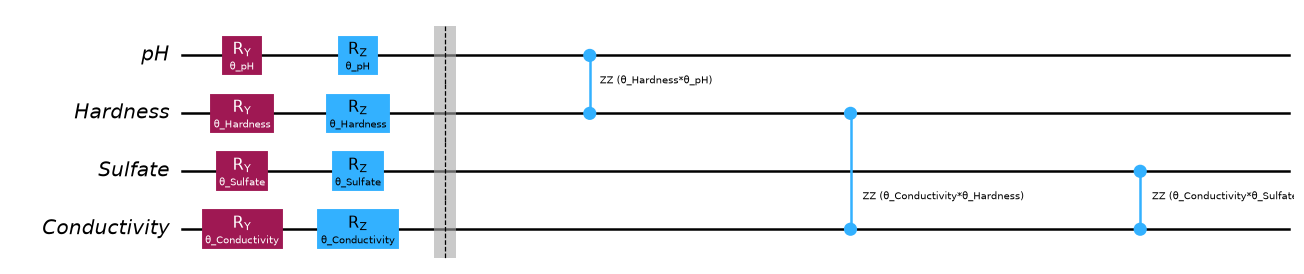

Figura guardada en:
/content/drive/MyDrive/Quantathon/custom_feature_map_presentation.png


In [ ]:
# ============================================================
# FIGURA DEL FEATURE MAP CUSTOM PARA PRESENTACIÓN
# ============================================================

from pathlib import Path

from IPython.display import display
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter


# ------------------------------------------------------------
# Registros cuánticos con nombres fisicoquímicos
# ------------------------------------------------------------

q_ph = QuantumRegister(1, "pH")
q_hard = QuantumRegister(1, "Hardness")
q_sulf = QuantumRegister(1, "Sulfate")
q_cond = QuantumRegister(1, "Conductivity")

qc_presentation = QuantumCircuit(
    q_ph,
    q_hard,
    q_sulf,
    q_cond,
    name="Domain-Informed Feature Map",
)


# ------------------------------------------------------------
# Parámetros
# ------------------------------------------------------------

theta_ph = Parameter("θ_pH")
theta_hard = Parameter("θ_Hardness")
theta_sulf = Parameter("θ_Sulfate")
theta_cond = Parameter("θ_Conductivity")

parameters = [
    theta_ph,
    theta_hard,
    theta_sulf,
    theta_cond,
]


# ------------------------------------------------------------
# Codificación individual
# ------------------------------------------------------------

for qubit_index, angle in enumerate(parameters):
    qc_presentation.ry(angle, qubit_index)
    qc_presentation.rz(angle, qubit_index)

qc_presentation.barrier()


# ------------------------------------------------------------
# Interacciones informadas por dominio
# ------------------------------------------------------------

qc_presentation.rzz(
    theta_ph * theta_hard,
    0,
    1,
)

qc_presentation.rzz(
    theta_hard * theta_cond,
    1,
    3,
)

qc_presentation.rzz(
    theta_sulf * theta_cond,
    2,
    3,
)


# ------------------------------------------------------------
# Dibujar
# ------------------------------------------------------------

fig = qc_presentation.draw(
    output="mpl",
    fold=-1,
    scale=0.9,
    style="iqp",
)

display(fig)


# ------------------------------------------------------------
# Guardar para la presentación
# ------------------------------------------------------------

FIG_PATH = Path(
    "/content/drive/MyDrive/Quantathon/"
    "custom_feature_map_presentation.png"
)

# Crear la carpeta si no existe
FIG_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

print(f"Figura guardada en:\n{FIG_PATH}")

In [ ]:
# ============================================================
# REACTIVAR OBJETOS PARA BLOQUE 12 — RUTA REAL DEL NOTEBOOK
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


# Ruta exacta usada en el notebook
ROOT = Path("/content/drive/MyDrive/Quanthaton")
OUTPUT_DIR = ROOT / "Water_QML_Final"

ANGLES_PATH = (
    OUTPUT_DIR
    / "audit_angles_N16_seed4524.csv"
)

KERNEL_PATH = (
    OUTPUT_DIR
    / "exact_kernel_custom_domain_N16_seed4524.npy"
)

# Asegurar que el directorio de salida existe, incluso si ya fue creado antes.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert ANGLES_PATH.exists(), ANGLES_PATH
assert KERNEL_PATH.exists(), KERNEL_PATH


# Cargar ángulos y etiquetas
angles_table = pd.read_csv(ANGLES_PATH)

Theta_audit = angles_table[
    [
        "Theta_ph",
        "Theta_Hardness",
        "Theta_Sulfate",
        "Theta_Conductivity",
    ]
].to_numpy(dtype=float)

y_audit = (
    angles_table["Potability"]
    .astype(int)
    .to_numpy()
)

audit_ids = (
    angles_table["Sample_ID"]
    .astype(str)
    .to_numpy()
)


# Cargar kernel exacto
exact_kernels = {
    "Custom_Domain": np.load(KERNEL_PATH)
}


# Reconstruir el circuito custom
theta_custom = ParameterVector(
    "theta_custom",
    4,
)

custom_map = QuantumCircuit(
    4,
    name="Custom_Domain",
)

for q in range(4):
    custom_map.ry(theta_custom[q], q)
    custom_map.rz(theta_custom[q], q)

for i, j in [
    (0, 1),
    (1, 3),
    (2, 3),
]:
    custom_map.rzz(
        theta_custom[i] * theta_custom[j],
        i,
        j,
    )

FEATURE_MAPS = {
    "Custom_Domain": custom_map
}


# Controles
assert Theta_audit.shape == (16, 4)
assert y_audit.shape == (16,)
assert exact_kernels["Custom_Domain"].shape == (16, 16)
assert custom_map.num_parameters == 4

print("Entorno correcto reactivado.")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Theta_audit:", Theta_audit.shape)
print("Kernel custom:", exact_kernels["Custom_Domain"].shape)
print("FEATURE_MAPS:", list(FEATURE_MAPS))
print("Listo para ejecutar el Bloque 12.")

Entorno correcto reactivado.
OUTPUT_DIR: /content/drive/MyDrive/Quanthaton/Water_QML_Final
Theta_audit: (16, 4)
Kernel custom: (16, 16)
FEATURE_MAPS: ['Custom_Domain']
Listo para ejecutar el Bloque 12.


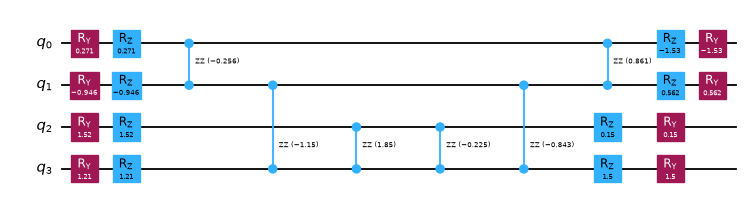

VALIDACIÓN DEL CIRCUITO DE OVERLAP


,Sample_ID_i,Sample_ID_j,Class_i,Class_j,K_Statevector_Gram,P_0000_Overlap,Absolute_Error
0,WP_0977,WP_0977,1,1,1.000000,1.000000,0.0
27,WP_1851,WP_1720,0,1,0.002603,0.002603,0.0
80,WP_0970,WP_1713,1,1,0.796305,0.796305,0.0


Máximo error absoluto: 8.882e-16
Error absoluto medio:  1.236e-16
Correlación matrices:  1.000000000000
Pares comprobados:     136

Circuito de overlap validado.
P(0000) reproduce exactamente K_ij.
Bloque 12 completado.


In [ ]:
#Validaicon de los circuitos
# ============================================================
# BLOQUE 12 — VALIDACIÓN DEL CIRCUITO DE OVERLAP
# ============================================================

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. OBJETOS DE REFERENCIA
# ------------------------------------------------------------

OVERLAP_MAP_NAME = "Custom_Domain"

custom_circuit = FEATURE_MAPS[
    OVERLAP_MAP_NAME
]

K_reference = exact_kernels[
    OVERLAP_MAP_NAME
]

theta_matrix = Theta_audit
n_samples = len(theta_matrix)


# ------------------------------------------------------------
# 2. ASIGNAR PARÁMETROS DE FORMA CONSISTENTE
# ------------------------------------------------------------

custom_parameters = sorted(
    custom_circuit.parameters,
    key=lambda parameter: parameter.name,
)

assert len(custom_parameters) == 4


def bind_feature_map(circuit, theta_row):
    """Asigna una muestra al circuito parametrizado."""

    parameter_map = dict(
        zip(
            custom_parameters,
            theta_row,
        )
    )

    bound = circuit.assign_parameters(
        parameter_map,
        inplace=False,
    )

    assert bound.num_parameters == 0

    return bound


# ------------------------------------------------------------
# 3. CONSTRUIR U(theta_j)† U(theta_i)
# ------------------------------------------------------------

def build_overlap_circuit(
    circuit,
    theta_i,
    theta_j,
):
    """
    Estado final:
    U(theta_j)† U(theta_i) |0000>
    """

    U_i = bind_feature_map(
        circuit,
        theta_i,
    )

    U_j = bind_feature_map(
        circuit,
        theta_j,
    )

    overlap = QuantumCircuit(
        circuit.num_qubits,
        name="Fidelity_Overlap",
    )

    overlap.compose(
        U_i,
        inplace=True,
    )

    overlap.compose(
        U_j.inverse(),
        inplace=True,
    )

    return overlap


def overlap_probability_zero(
    circuit,
    theta_i,
    theta_j,
):
    """Probabilidad exacta de medir 0000."""

    overlap = build_overlap_circuit(
        circuit,
        theta_i,
        theta_j,
    )

    state = Statevector.from_instruction(
        overlap
    )

    # Índice 0 corresponde a |0000>
    return float(
        np.abs(state.data[0]) ** 2
    )


# ------------------------------------------------------------
# 4. RECONSTRUIR TODO EL KERNEL POR OVERLAPS
# ------------------------------------------------------------

K_overlap = np.eye(
    n_samples,
    dtype=float,
)

pair_rows = []

for i in range(n_samples):

    for j in range(i, n_samples):

        probability_0000 = (
            overlap_probability_zero(
                custom_circuit,
                theta_matrix[i],
                theta_matrix[j],
            )
        )

        K_overlap[i, j] = probability_0000
        K_overlap[j, i] = probability_0000

        pair_rows.append({
            "i": i,
            "j": j,
            "Sample_ID_i": audit_ids[i],
            "Sample_ID_j": audit_ids[j],
            "Class_i": int(y_audit[i]),
            "Class_j": int(y_audit[j]),
            "K_Statevector_Gram":
                K_reference[i, j],
            "P_0000_Overlap":
                probability_0000,
            "Absolute_Error": abs(
                probability_0000
                - K_reference[i, j]
            ),
        })


overlap_validation = pd.DataFrame(
    pair_rows
)


# ------------------------------------------------------------
# 5. AUDITORÍA
# ------------------------------------------------------------

max_error = np.max(
    np.abs(
        K_overlap
        - K_reference
    )
)

mean_error = np.mean(
    np.abs(
        K_overlap
        - K_reference
    )
)

matrix_correlation = np.corrcoef(
    K_overlap.ravel(),
    K_reference.ravel(),
)[0, 1]

assert np.allclose(
    K_overlap,
    K_reference,
    atol=1e-10,
), (
    "El circuito de overlap no reproduce "
    "el kernel de referencia."
)


# ------------------------------------------------------------
# 6. PARES REPRESENTATIVOS
# ------------------------------------------------------------

offdiag_mask = ~np.eye(
    n_samples,
    dtype=bool,
)

offdiag_values = np.where(
    offdiag_mask,
    K_reference,
    np.nan,
)

high_i, high_j = np.unravel_index(
    np.nanargmax(offdiag_values),
    offdiag_values.shape,
)

low_i, low_j = np.unravel_index(
    np.nanargmin(offdiag_values),
    offdiag_values.shape,
)

representative_pairs = (
    overlap_validation[
        (
            (overlap_validation["i"] == 0)
            & (overlap_validation["j"] == 0)
        )
        |
        (
            (overlap_validation["i"] == min(high_i, high_j))
            & (overlap_validation["j"] == max(high_i, high_j))
        )
        |
        (
            (overlap_validation["i"] == min(low_i, low_j))
            & (overlap_validation["j"] == max(low_i, low_j))
        )
    ]
    .drop_duplicates(
        subset=["i", "j"]
    )
)


# ------------------------------------------------------------
# 7. GUARDAR
# ------------------------------------------------------------

np.save(
    OUTPUT_DIR
    / "custom_overlap_kernel_N16_seed4524.npy",
    K_overlap,
)

overlap_validation.to_csv(
    OUTPUT_DIR
    / "custom_overlap_validation_N16_seed4524.csv",
    index=False,
)


# ------------------------------------------------------------
# 8. DIBUJAR UN CIRCUITO DE OVERLAP
# ------------------------------------------------------------

example_overlap = build_overlap_circuit(
    custom_circuit,
    theta_matrix[0],
    theta_matrix[1],
)

fig_overlap = example_overlap.draw(
    output="mpl",
    fold=-1,
    scale=0.65,
)

display(fig_overlap)


# ------------------------------------------------------------
# 9. RESULTADOS
# ------------------------------------------------------------

print("=" * 72)
print("VALIDACIÓN DEL CIRCUITO DE OVERLAP")
print("=" * 72)

display(
    representative_pairs[
        [
            "Sample_ID_i",
            "Sample_ID_j",
            "Class_i",
            "Class_j",
            "K_Statevector_Gram",
            "P_0000_Overlap",
            "Absolute_Error",
        ]
    ].round(12)
)

print(f"Máximo error absoluto: {max_error:.3e}")
print(f"Error absoluto medio:  {mean_error:.3e}")
print(f"Correlación matrices:  {matrix_correlation:.12f}")
print(f"Pares comprobados:     {len(overlap_validation)}")

print("\nCircuito de overlap validado.")
print("P(0000) reproduce exactamente K_ij.")
print("Bloque 12 completado.")

In [ ]:
# ============================================================
# BLOQUE 13 — KERNEL CUSTOM CON SHOTS, N = 16
# ============================================================

%pip install -q "qiskit-aer~=0.17"

import time
import numpy as np
import pandas as pd

from qiskit import transpile
from qiskit_aer import AerSimulator


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

SHOT_LEVELS = [256, 1024]
SIMULATOR_SEED = 4524

n_samples = len(Theta_audit)

K_exact = exact_kernels[
    "Custom_Domain"
]


# ------------------------------------------------------------
# 2. CONSTRUIR LOS 136 CIRCUITOS MEDIDOS
# ------------------------------------------------------------

measured_overlap_circuits = []
pair_indices = []

for i in range(n_samples):

    for j in range(i, n_samples):

        circuit = build_overlap_circuit(
            FEATURE_MAPS["Custom_Domain"],
            Theta_audit[i],
            Theta_audit[j],
        )

        circuit.name = f"pair_{i:02d}_{j:02d}"

        circuit.measure_all()

        measured_overlap_circuits.append(
            circuit
        )

        pair_indices.append(
            (i, j)
        )


assert len(measured_overlap_circuits) == 136


# ------------------------------------------------------------
# 3. TRANSPILAR PARA AER
# ------------------------------------------------------------

simulator = AerSimulator()

compiled_circuits = transpile(
    measured_overlap_circuits,
    backend=simulator,
    optimization_level=1,
    seed_transpiler=SIMULATOR_SEED,
)


# ------------------------------------------------------------
# 4. FUNCIÓN DE EJECUCIÓN
# ------------------------------------------------------------

def run_shot_kernel(shots):

    start = time.time()

    job = simulator.run(
        compiled_circuits,
        shots=shots,
        seed_simulator=SIMULATOR_SEED,
    )

    result = job.result()

    K_shots = np.zeros(
        (n_samples, n_samples),
        dtype=float,
    )

    rows = []

    for circuit_index, (i, j) in enumerate(
        pair_indices
    ):

        counts = result.get_counts(
            circuit_index
        )

        count_0000 = counts.get(
            "0000",
            0,
        )

        estimated_fidelity = (
            count_0000 / shots
        )

        K_shots[i, j] = estimated_fidelity
        K_shots[j, i] = estimated_fidelity

        rows.append({
            "Shots": shots,
            "i": i,
            "j": j,
            "Sample_ID_i": audit_ids[i],
            "Sample_ID_j": audit_ids[j],
            "Count_0000": count_0000,
            "K_Exact": K_exact[i, j],
            "K_Shots": estimated_fidelity,
            "Absolute_Error": abs(
                estimated_fidelity
                - K_exact[i, j]
            ),
        })


    # --------------------------------------------------------
    # DIAGNÓSTICOS
    # --------------------------------------------------------

    upper = np.triu_indices(
        n_samples,
        k=0,
    )

    exact_values = K_exact[upper]
    shot_values = K_shots[upper]

    absolute_error = np.abs(
        shot_values
        - exact_values
    )

    frobenius_relative = (
        np.linalg.norm(
            K_shots - K_exact,
            ord="fro",
        )
        /
        np.linalg.norm(
            K_exact,
            ord="fro",
        )
    )

    correlation = np.corrcoef(
        exact_values,
        shot_values,
    )[0, 1]

    eigenvalues = np.linalg.eigvalsh(
        (K_shots + K_shots.T) / 2
    )

    summary = {
        "Shots": shots,
        "Circuits": len(
            compiled_circuits
        ),
        "MAE": absolute_error.mean(),
        "Max_Absolute_Error":
            absolute_error.max(),
        "Relative_Frobenius_Error":
            frobenius_relative,
        "Matrix_Correlation":
            correlation,
        "Diagonal_Mean":
            np.diag(K_shots).mean(),
        "Eigenvalue_Min":
            eigenvalues.min(),
        "Elapsed_Seconds":
            time.time() - start,
    }

    return (
        K_shots,
        pd.DataFrame(rows),
        summary,
    )


# ------------------------------------------------------------
# 5. EJECUTAR 256 Y 1024 SHOTS
# ------------------------------------------------------------

shot_kernels = {}
shot_pair_tables = {}
summary_rows = []

for shots in SHOT_LEVELS:

    print(
        f"Ejecutando {shots} shots..."
    )

    K_shots, pair_table, summary = (
        run_shot_kernel(shots)
    )

    shot_kernels[shots] = K_shots
    shot_pair_tables[shots] = pair_table
    summary_rows.append(summary)


shot_kernel_summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# 6. GUARDAR
# ------------------------------------------------------------

shot_kernel_summary.to_csv(
    OUTPUT_DIR
    / "custom_shot_kernel_summary_N16_seed4524.csv",
    index=False,
)

for shots in SHOT_LEVELS:

    np.save(
        OUTPUT_DIR
        / f"custom_kernel_{shots}shots_N16_seed4524.npy",
        shot_kernels[shots],
    )

    shot_pair_tables[shots].to_csv(
        OUTPUT_DIR
        / f"custom_kernel_pairs_{shots}shots_N16_seed4524.csv",
        index=False,
    )


# ------------------------------------------------------------
# 7. MOSTRAR RESULTADOS
# ------------------------------------------------------------

print("\n" + "=" * 84)
print("COMPARACIÓN KERNEL EXACTO VS KERNEL CON SHOTS")
print("=" * 84)

display(
    shot_kernel_summary.round(6)
)

print("\nPares representativos con 1024 shots:")

representative_1024 = (
    shot_pair_tables[1024]
    .sort_values(
        "Absolute_Error",
        ascending=False,
    )
)

display(
    pd.concat([
        shot_pair_tables[1024].iloc[[0]],
        representative_1024.head(5),
    ])
    .drop_duplicates(
        subset=["i", "j"]
    )
    [
        [
            "Sample_ID_i",
            "Sample_ID_j",
            "K_Exact",
            "K_Shots",
            "Absolute_Error",
            "Count_0000",
        ]
    ]
    .round(6)
)

print("\nBloque 13 completado.")
print("136 circuitos ejecutados por nivel de shots.")
print("Todavía sin ruido físico.")
print("Test sellado: NO utilizado.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.5 MB/s eta 0:00:00
Ejecutando 256 shots...
Ejecutando 1024 shots...

COMPARACIÓN KERNEL EXACTO VS KERNEL CON SHOTS


,Shots,Circuits,MAE,Max_Absolute_Error,Relative_Frobenius_Error,Matrix_Correlation,Diagonal_Mean,Eigenvalue_Min,Elapsed_Seconds
0,256,136,0.015306,0.068542,0.057375,0.997429,1.0,0.108458,1.627480
1,1024,136,0.008011,0.036315,0.029746,0.999307,1.0,0.098898,1.718028



Pares representativos con 1024 shots:


,Sample_ID_i,Sample_ID_j,K_Exact,K_Shots,Absolute_Error,Count_0000
0,WP_0977,WP_0977,1.000000,1.000000,0.000000,1024
24,WP_1851,WP_0433,0.314271,0.350586,0.036315,359
82,WP_0376,WP_1377,0.333476,0.298828,0.034648,306
122,WP_1409,WP_1720,0.577545,0.544922,0.032623,558
2,WP_0977,WP_0061,0.311491,0.343750,0.032259,352
61,WP_1242,WP_1377,0.344356,0.374023,0.029667,383



Bloque 13 completado.
136 circuitos ejecutados por nivel de shots.
Todavía sin ruido físico.
Test sellado: NO utilizado.


In [ ]:
# ============================================================
# BLOQUE 14A — AUDITORÍA DE REPRODUCIBILIDAD, SEED 4524
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# RUTA REAL DEL NOTEBOOK
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

fixed_path = (
    OUTPUT_DIR
    / "svm_rbf_fixed_fold_results_seed4524.csv"
)

qsvm_path = (
    OUTPUT_DIR
    / "qsvm_exact_fold_results_seed4524.csv"
)

grid_path = (
    OUTPUT_DIR
    / "svm_rbf_subset_fold_results_seed4524.csv"
)

kernel_path = (
    OUTPUT_DIR
    / "exact_kernel_custom_domain_N16_seed4524.npy"
)

for path in [
    fixed_path,
    qsvm_path,
    kernel_path,
]:
    assert path.exists(), f"No existe: {path}"


# ------------------------------------------------------------
# 1. CARGAR RESULTADOS CRUDOS
# ------------------------------------------------------------

fixed = pd.read_csv(fixed_path)
qsvm = pd.read_csv(qsvm_path)

grid = (
    pd.read_csv(grid_path)
    if grid_path.exists()
    else None
)


# ------------------------------------------------------------
# 2. RECALCULAR DESDE LOS 20 FOLDS
# ------------------------------------------------------------

fixed_summary_check = (
    fixed
    .groupby("N", as_index=False)
    .agg(
        BA_Mean=("Balanced_Accuracy", "mean"),
        BA_SD=("Balanced_Accuracy", "std"),
        MCC_Mean=("MCC", "mean"),
        MCC_SD=("MCC", "std"),
        F1_Mean=("F1", "mean"),
        AUC_Mean=("ROC_AUC", "mean"),
    )
)

qsvm_summary_check = (
    qsvm
    .groupby(
        ["N", "Feature_Map"],
        as_index=False,
    )
    .agg(
        BA_Mean=("Balanced_Accuracy", "mean"),
        BA_SD=("Balanced_Accuracy", "std"),
        MCC_Mean=("MCC", "mean"),
        F1_Mean=("F1", "mean"),
        AUC_Mean=("ROC_AUC", "mean"),
    )
)


# ------------------------------------------------------------
# 3. REVISAR LAS DOS SD ≈ 0.1374
# ------------------------------------------------------------

rbf_n32 = fixed.loc[
    fixed["N"] == 32,
    "Balanced_Accuracy",
].to_numpy()

custom_n64 = qsvm.loc[
    (
        (qsvm["N"] == 64)
        &
        (
            qsvm["Feature_Map"]
            == "Custom_Domain"
        )
    ),
    "Balanced_Accuracy",
].to_numpy()

sd_rbf_n32 = np.std(
    rbf_n32,
    ddof=1,
)

sd_custom_n64 = np.std(
    custom_n64,
    ddof=1,
)

same_fold_values = np.array_equal(
    rbf_n32,
    custom_n64,
)


# ------------------------------------------------------------
# 4. COMPARAR RBF FIJA VS GRID EN N=64
# ------------------------------------------------------------

comparison_grid = None

if grid is not None:

    fixed_n64 = (
        fixed.loc[
            fixed["N"] == 64,
            [
                "Split_Number",
                "Balanced_Accuracy",
                "MCC",
                "F1",
            ],
        ]
        .sort_values("Split_Number")
        .reset_index(drop=True)
    )

    grid_n64 = (
        grid.loc[
            grid["N"] == 64,
            [
                "Split_Number",
                "Balanced_Accuracy",
                "MCC",
                "F1",
            ],
        ]
        .sort_values("Split_Number")
        .reset_index(drop=True)
    )

    comparison_grid = {
        "Same_Number_Of_Folds":
            len(fixed_n64) == len(grid_n64),

        "BA_Folds_Identical":
            np.allclose(
                fixed_n64["Balanced_Accuracy"],
                grid_n64["Balanced_Accuracy"],
            ),

        "MCC_Folds_Identical":
            np.allclose(
                fixed_n64["MCC"],
                grid_n64["MCC"],
            ),

        "F1_Folds_Identical":
            np.allclose(
                fixed_n64["F1"],
                grid_n64["F1"],
            ),
    }


# ------------------------------------------------------------
# 5. AUTOVALOR MÍNIMO EXACTO N=16
# ------------------------------------------------------------

K_exact_n16 = np.load(
    kernel_path
)

K_exact_n16 = (
    K_exact_n16
    + K_exact_n16.T
) / 2.0

exact_eigenvalues = np.linalg.eigvalsh(
    K_exact_n16
)

exact_lambda_min = float(
    exact_eigenvalues.min()
)


# ------------------------------------------------------------
# 6. GUARDAR AUDITORÍA
# ------------------------------------------------------------

audit_report = pd.DataFrame([
    {
        "Check": "RBF_N32_BA_SD",
        "Value": sd_rbf_n32,
    },
    {
        "Check": "Custom_N64_BA_SD",
        "Value": sd_custom_n64,
    },
    {
        "Check": "SD_Absolute_Difference",
        "Value": abs(
            sd_rbf_n32
            - sd_custom_n64
        ),
    },
    {
        "Check": "Fold_Values_Exactly_Equal",
        "Value": same_fold_values,
    },
    {
        "Check": "Exact_Kernel_N16_Lambda_Min",
        "Value": exact_lambda_min,
    },
])

audit_report.to_csv(
    OUTPUT_DIR
    / "audit_reproducibility_seed4524.csv",
    index=False,
)


# ------------------------------------------------------------
# 7. MOSTRAR
# ------------------------------------------------------------

print("=" * 80)
print("SVM-RBF FIJA — RECALCULADA DESDE FOLDS")
print("=" * 80)

display(
    fixed_summary_check.round(10)
)

print("\n" + "=" * 80)
print("QSVM — RECALCULADA DESDE FOLDS")
print("=" * 80)

display(
    qsvm_summary_check.round(10)
)

print("\n" + "=" * 80)
print("VERIFICACIONES ESPECÍFICAS")
print("=" * 80)

print(
    "SD RBF N=32:       ",
    f"{sd_rbf_n32:.12f}",
)

print(
    "SD Custom N=64:    ",
    f"{sd_custom_n64:.12f}",
)

print(
    "Diferencia SD:      ",
    f"{abs(sd_rbf_n32 - sd_custom_n64):.12e}",
)

print(
    "Folds idénticos:    ",
    same_fold_values,
)

print(
    "λ mínimo exacto N16:",
    f"{exact_lambda_min:.12f}",
)

if comparison_grid is not None:

    print("\nComparación RBF fija vs grid, N=64:")

    for key, value in comparison_grid.items():
        print(f"- {key}: {value}")

else:
    print(
        "\nNo se encontró el archivo exploratorio "
        "del grid; no afecta el análisis primario."
    )

print("\nBloque 14A completado.")

SVM-RBF FIJA — RECALCULADA DESDE FOLDS


,N,BA_Mean,BA_SD,MCC_Mean,MCC_SD,F1_Mean,AUC_Mean
0,16,0.550000,0.130787,0.115470,0.302040,0.426667,NaN
1,32,0.443750,0.137380,-0.121572,0.323059,0.389181,0.412500
2,64,0.621875,0.096132,0.249919,0.197147,0.565933,0.610156



QSVM — RECALCULADA DESDE FOLDS


,N,Feature_Map,BA_Mean,BA_SD,MCC_Mean,F1_Mean,AUC_Mean
0,16,Custom_Domain,0.512500,0.221760,0.021132,0.406667,NaN
1,16,Pauli_Z_YY,0.512500,0.206394,0.028868,0.381667,NaN
2,16,Separable_Control,0.600000,0.188484,0.215470,0.485000,NaN
3,16,ZZ_Linear,0.350000,0.220645,-0.323205,0.161667,NaN
4,32,Custom_Domain,0.643750,0.147763,0.302792,0.635952,0.681250
5,32,Pauli_Z_YY,0.556250,0.154297,0.116403,0.580895,0.603125
6,32,Separable_Control,0.475000,0.095971,-0.060676,0.482244,0.493750
7,32,ZZ_Linear,0.556250,0.137380,0.129093,0.579578,0.568750
8,64,Custom_Domain,0.631250,0.137380,0.270639,0.605759,0.674219
9,64,Pauli_Z_YY,0.475000,0.133587,-0.050840,0.427745,0.495312



VERIFICACIONES ESPECÍFICAS
SD RBF N=32:        0.137380330700
SD Custom N=64:     0.137380330700
Diferencia SD:       0.000000000000e+00
Folds idénticos:     False
λ mínimo exacto N16: 0.116566037271

Comparación RBF fija vs grid, N=64:
- Same_Number_Of_Folds: True
- BA_Folds_Identical: True
- MCC_Folds_Identical: True
- F1_Folds_Identical: True

Bloque 14A completado.


In [ ]:
# ============================================================
# BLOQUE 14B — AUDITAR PARÁMETROS DEL GRID EN N=64
# ============================================================

import pandas as pd

grid_path = (
    OUTPUT_DIR
    / "svm_rbf_subset_fold_results_seed4524.csv"
)

grid = pd.read_csv(grid_path)

grid_n64 = grid.loc[
    grid["N"] == 64
].copy()

print("Columnas disponibles:")
print(grid_n64.columns.tolist())

possible_parameter_columns = [
    column
    for column in grid_n64.columns
    if any(
        token in column.lower()
        for token in [
            "param",
            "best",
            "gamma",
            "class_weight",
        ]
    )
    or column.lower() == "c"
]

print("\nColumnas potenciales de hiperparámetros:")
print(possible_parameter_columns)

if possible_parameter_columns:

    display(
        grid_n64[
            possible_parameter_columns
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

else:
    print(
        "\nEl CSV no contiene los parámetros seleccionados."
    )

print("\nNúmero de folds N=64:", len(grid_n64))

Columnas disponibles:
['Seed', 'N', 'Split_Number', 'Balanced_Accuracy', 'MCC', 'F1', 'ROC_AUC', 'Specificity', 'Unsafe_Acceptance']

Columnas potenciales de hiperparámetros:
[]

El CSV no contiene los parámetros seleccionados.

Número de folds N=64: 20


In [ ]:
# ============================================================
# BLOQUE 15 — VALIDACIÓN OVERLAP PARA LOS CUATRO FEATURE MAPS
# N = 16, SEED = 4524
# ============================================================

from functools import reduce
from operator import mul
from pathlib import Path

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import (
    zz_feature_map,
    pauli_feature_map,
)
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. CONTROLES DEL ENTORNO
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

assert "Theta_audit" in globals(), (
    "No existe Theta_audit. Ejecuta primero la celda "
    "de reactivación del entorno."
)

assert Theta_audit.shape == (16, 4), (
    f"Forma inesperada: {Theta_audit.shape}"
)


# ------------------------------------------------------------
# 2. DATA MAP θ_i θ_j
# ------------------------------------------------------------

def product_data_map(values):

    values = list(values)

    if len(values) == 1:
        return values[0]

    return reduce(
        mul,
        values,
    )


# ------------------------------------------------------------
# 3. CONTROL SEPARABLE
# ------------------------------------------------------------

theta_sep = ParameterVector(
    "theta_sep",
    4,
)

separable_map = QuantumCircuit(
    4,
    name="Separable_Control",
)

for q in range(4):

    separable_map.ry(
        theta_sep[q],
        q,
    )

    separable_map.rz(
        theta_sep[q],
        q,
    )


# ------------------------------------------------------------
# 4. ZZ LINEAR
# ------------------------------------------------------------

zz_map = zz_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear",
    alpha=1.0,
    data_map_func=product_data_map,
    parameter_prefix="theta_zz",
    name="ZZ_Linear",
)


# ------------------------------------------------------------
# 5. PAULI Z + YY
# ------------------------------------------------------------

pauli_map = pauli_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear",
    alpha=1.0,
    paulis=["Z", "YY"],
    data_map_func=product_data_map,
    parameter_prefix="theta_pauli",
    name="Pauli_Z_YY",
)


# ------------------------------------------------------------
# 6. CUSTOM DOMAIN
# ------------------------------------------------------------

theta_custom = ParameterVector(
    "theta_custom",
    4,
)

custom_map = QuantumCircuit(
    4,
    name="Custom_Domain",
)

for q in range(4):

    custom_map.ry(
        theta_custom[q],
        q,
    )

    custom_map.rz(
        theta_custom[q],
        q,
    )

for i, j in [
    (0, 1),
    (1, 3),
    (2, 3),
]:

    custom_map.rzz(
        theta_custom[i]
        * theta_custom[j],
        i,
        j,
    )


FEATURE_MAPS = {
    "Separable_Control": separable_map,
    "ZZ_Linear": zz_map,
    "Pauli_Z_YY": pauli_map,
    "Custom_Domain": custom_map,
}


# ------------------------------------------------------------
# 7. ASIGNACIÓN ROBUSTA DE PARÁMETROS
# ------------------------------------------------------------

def ordered_parameters(circuit):

    return sorted(
        list(circuit.parameters),
        key=lambda parameter: parameter.name,
    )


def bind_feature_map(
    circuit,
    theta_values,
):

    theta_values = np.asarray(
        theta_values,
        dtype=float,
    )

    parameters = ordered_parameters(
        circuit
    )

    if len(parameters) != len(theta_values):

        raise ValueError(
            f"{circuit.name}: "
            f"{len(parameters)} parámetros, "
            f"pero se recibieron "
            f"{len(theta_values)} valores."
        )

    parameter_map = {
        parameter: float(value)
        for parameter, value
        in zip(
            parameters,
            theta_values,
        )
    }

    bound = circuit.assign_parameters(
        parameter_map,
        inplace=False,
    )

    if bound.num_parameters != 0:

        raise RuntimeError(
            f"{circuit.name}: quedaron "
            f"{bound.num_parameters} parámetros libres."
        )

    return bound


# ------------------------------------------------------------
# 8. CIRCUITO DE OVERLAP
# ------------------------------------------------------------

def build_overlap_circuit(
    circuit,
    theta_i,
    theta_j,
):

    U_i = bind_feature_map(
        circuit,
        theta_i,
    )

    U_j = bind_feature_map(
        circuit,
        theta_j,
    )

    overlap = QuantumCircuit(
        circuit.num_qubits,
        name=f"Overlap_{circuit.name}",
    )

    # Estado final:
    # U_j† U_i |0000>
    overlap.compose(
        U_i,
        inplace=True,
    )

    overlap.compose(
        U_j.inverse(),
        inplace=True,
    )

    return overlap


# ------------------------------------------------------------
# 9. KERNEL EXACTO DESDE STATEVECTORS
# ------------------------------------------------------------

def exact_statevector_kernel(
    circuit,
    theta_matrix,
):

    states = []

    for theta_values in theta_matrix:

        bound = bind_feature_map(
            circuit,
            theta_values,
        )

        state = Statevector.from_instruction(
            bound
        ).data

        states.append(state)

    states = np.asarray(
        states,
        dtype=complex,
    )

    amplitudes = (
        states.conj()
        @ states.T
    )

    kernel = (
        np.abs(amplitudes) ** 2
    )

    return kernel


# ------------------------------------------------------------
# 10. VALIDAR LOS 136 PARES POR MAPA
# ------------------------------------------------------------

all_pair_rows = []
summary_rows = []

exact_kernels_all_maps = {}
overlap_kernels_all_maps = {}

n_samples = Theta_audit.shape[0]

for map_name, circuit in FEATURE_MAPS.items():

    print(
        f"Validando {map_name}..."
    )

    K_exact = exact_statevector_kernel(
        circuit,
        Theta_audit,
    )

    K_overlap = np.zeros(
        (n_samples, n_samples),
        dtype=float,
    )

    map_pair_rows = []

    for i in range(n_samples):

        for j in range(i, n_samples):

            overlap = build_overlap_circuit(
                circuit,
                Theta_audit[i],
                Theta_audit[j],
            )

            overlap_state = (
                Statevector.from_instruction(
                    overlap
                )
            )

            probability_0000 = float(
                np.abs(
                    overlap_state.data[0]
                ) ** 2
            )

            K_overlap[i, j] = (
                probability_0000
            )

            K_overlap[j, i] = (
                probability_0000
            )

            exact_value = float(
                K_exact[i, j]
            )

            absolute_error = abs(
                probability_0000
                - exact_value
            )

            row = {
                "Feature_Map": map_name,
                "i": i,
                "j": j,
                "Sample_ID_i": (
                    audit_ids[i]
                    if "audit_ids" in globals()
                    else f"Sample_{i:02d}"
                ),
                "Sample_ID_j": (
                    audit_ids[j]
                    if "audit_ids" in globals()
                    else f"Sample_{j:02d}"
                ),
                "K_Exact": exact_value,
                "P_0000_Overlap":
                    probability_0000,
                "Absolute_Error":
                    absolute_error,
            }

            map_pair_rows.append(row)
            all_pair_rows.append(row)

    map_pair_table = pd.DataFrame(
        map_pair_rows
    )

    upper = np.triu_indices(
        n_samples,
        k=0,
    )

    exact_values = K_exact[upper]
    overlap_values = K_overlap[upper]

    absolute_errors = np.abs(
        overlap_values
        - exact_values
    )

    correlation = np.corrcoef(
        exact_values,
        overlap_values,
    )[0, 1]

    diagonal_error = np.max(
        np.abs(
            np.diag(K_overlap)
            - 1.0
        )
    )

    symmetry_error = np.max(
        np.abs(
            K_overlap
            - K_overlap.T
        )
    )

    passed = bool(
        absolute_errors.max()
        < 1e-12
    )

    summary_rows.append({
        "Feature_Map": map_name,
        "Pairs_Validated":
            len(map_pair_table),
        "Mean_Absolute_Error":
            absolute_errors.mean(),
        "Max_Absolute_Error":
            absolute_errors.max(),
        "Matrix_Correlation":
            correlation,
        "Diagonal_Max_Error":
            diagonal_error,
        "Symmetry_Max_Error":
            symmetry_error,
        "PASS_1e-12":
            passed,
    })

    exact_kernels_all_maps[
        map_name
    ] = K_exact

    overlap_kernels_all_maps[
        map_name
    ] = K_overlap

    safe_name = (
        map_name
        .lower()
        .replace(" ", "_")
    )

    np.save(
        OUTPUT_DIR
        / (
            f"exact_kernel_{safe_name}"
            "_N16_seed4524.npy"
        ),
        K_exact,
    )

    np.save(
        OUTPUT_DIR
        / (
            f"overlap_kernel_{safe_name}"
            "_N16_seed4524.npy"
        ),
        K_overlap,
    )


# ------------------------------------------------------------
# 11. TABLAS FINALES
# ------------------------------------------------------------

overlap_all_maps_pairs = pd.DataFrame(
    all_pair_rows
)

overlap_all_maps_summary = pd.DataFrame(
    summary_rows
)

overlap_all_maps_pairs.to_csv(
    OUTPUT_DIR
    / (
        "overlap_validation_all_maps_"
        "pairs_N16_seed4524.csv"
    ),
    index=False,
)

overlap_all_maps_summary.to_csv(
    OUTPUT_DIR
    / (
        "overlap_validation_all_maps_"
        "summary_N16_seed4524.csv"
    ),
    index=False,
)


# ------------------------------------------------------------
# 12. CONTROLES ESTRICTOS
# ------------------------------------------------------------

assert len(
    overlap_all_maps_pairs
) == 4 * 136

assert overlap_all_maps_summary[
    "PASS_1e-12"
].all(), (
    "Al menos un mapa no reprodujo "
    "el kernel exacto."
)


# ------------------------------------------------------------
# 13. MOSTRAR RESULTADOS
# ------------------------------------------------------------

print("\n" + "=" * 92)
print("VALIDACIÓN OVERLAP — CUATRO FEATURE MAPS")
print("=" * 92)

display(
    overlap_all_maps_summary.round(15)
)

print("\nPeor par de cada mapa:")

worst_pairs = (
    overlap_all_maps_pairs
    .sort_values(
        "Absolute_Error",
        ascending=False,
    )
    .groupby(
        "Feature_Map",
        as_index=False,
    )
    .first()
)

display(
    worst_pairs[
        [
            "Feature_Map",
            "Sample_ID_i",
            "Sample_ID_j",
            "K_Exact",
            "P_0000_Overlap",
            "Absolute_Error",
        ]
    ].round(15)
)

print("\nBloque 15 completado.")
print("Mapas validados: 4")
print("Pares por mapa: 136")
print("Pares totales: 544")
print("Test sellado: NO utilizado.")

Validando Separable_Control...
Validando ZZ_Linear...
Validando Pauli_Z_YY...
Validando Custom_Domain...

VALIDACIÓN OVERLAP — CUATRO FEATURE MAPS


,Feature_Map,Pairs_Validated,Mean_Absolute_Error,Max_Absolute_Error,Matrix_Correlation,Diagonal_Max_Error,Symmetry_Max_Error,PASS_1e-12
0,Separable_Control,136,0.0,2.000000e-15,1.0,1.000000e-15,0.0,True
1,ZZ_Linear,136,0.0,1.000000e-15,1.0,2.000000e-15,0.0,True
2,Pauli_Z_YY,136,0.0,1.000000e-15,1.0,2.000000e-15,0.0,True
3,Custom_Domain,136,0.0,1.000000e-15,1.0,1.000000e-15,0.0,True



Peor par de cada mapa:


,Feature_Map,Sample_ID_i,Sample_ID_j,K_Exact,P_0000_Overlap,Absolute_Error
0,Custom_Domain,WP_1242,WP_0376,0.630145,0.630145,1.000000e-15
1,Pauli_Z_YY,WP_1896,WP_1896,1.000000,1.000000,1.000000e-15
2,Separable_Control,WP_0970,WP_0970,1.000000,1.000000,2.000000e-15
3,ZZ_Linear,WP_0433,WP_0433,1.000000,1.000000,1.000000e-15



Bloque 15 completado.
Mapas validados: 4
Pares por mapa: 136
Pares totales: 544
Test sellado: NO utilizado.


In [ ]:
# ============================================================
# BLOQUE 16A — REMUESTREO MONTE CARLO DEL KERNEL CUSTOM
# N = 16, 10 REPETICIONES POR PRESUPUESTO
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

SHOT_LEVELS = [256, 1024]
N_SHOT_REPEATS = 10
BASE_SHOT_SEED = 4524


# ------------------------------------------------------------
# 2. KERNEL EXACTO DE REFERENCIA
# ------------------------------------------------------------

if "exact_kernels_all_maps" in globals():

    K_exact = exact_kernels_all_maps[
        "Custom_Domain"
    ].copy()

else:

    K_exact = np.load(
        OUTPUT_DIR
        / "exact_kernel_custom_domain_N16_seed4524.npy"
    )


K_exact = np.asarray(
    K_exact,
    dtype=float,
)

K_exact = (
    K_exact
    + K_exact.T
) / 2.0

assert K_exact.shape == (16, 16)
assert np.isfinite(K_exact).all()

n_samples = K_exact.shape[0]

upper_all = np.triu_indices(
    n_samples,
    k=0,
)

upper_offdiag = np.triu_indices(
    n_samples,
    k=1,
)

exact_eigenvalues = np.linalg.eigvalsh(
    K_exact
)

exact_lambda_min = float(
    exact_eigenvalues.min()
)


# ------------------------------------------------------------
# 3. REMUESTREAR UN KERNEL
# ------------------------------------------------------------

def sample_fidelity_kernel(
    exact_kernel,
    shots,
    rng,
):

    n = exact_kernel.shape[0]

    sampled_kernel = np.zeros(
        (n, n),
        dtype=float,
    )

    count_matrix = np.zeros(
        (n, n),
        dtype=int,
    )

    for i in range(n):

        for j in range(i, n):

            probability = float(
                np.clip(
                    exact_kernel[i, j],
                    0.0,
                    1.0,
                )
            )

            count_0000 = rng.binomial(
                n=shots,
                p=probability,
            )

            estimate = (
                count_0000
                / shots
            )

            sampled_kernel[i, j] = estimate
            sampled_kernel[j, i] = estimate

            count_matrix[i, j] = count_0000
            count_matrix[j, i] = count_0000

    return sampled_kernel, count_matrix


# ------------------------------------------------------------
# 4. EJECUTAR LAS 20 REALIZACIONES
# ------------------------------------------------------------

repeat_rows = []
sampled_kernels = {}
sampled_counts = {}

for shots in SHOT_LEVELS:

    print(
        f"Remuestreando {shots} shots..."
    )

    for repetition in range(
        1,
        N_SHOT_REPEATS + 1,
    ):

        random_seed = (
            BASE_SHOT_SEED
            + shots * 100
            + repetition
        )

        rng = np.random.default_rng(
            random_seed
        )

        K_sampled, count_matrix = (
            sample_fidelity_kernel(
                exact_kernel=K_exact,
                shots=shots,
                rng=rng,
            )
        )

        sampled_kernels[
            f"S{shots}_R{repetition:02d}"
        ] = K_sampled

        sampled_counts[
            f"S{shots}_R{repetition:02d}"
        ] = count_matrix


        # ----------------------------------------------------
        # ERRORES
        # ----------------------------------------------------

        absolute_error_matrix = np.abs(
            K_sampled
            - K_exact
        )

        mae_all = float(
            absolute_error_matrix[
                upper_all
            ].mean()
        )

        mae_offdiag = float(
            absolute_error_matrix[
                upper_offdiag
            ].mean()
        )

        max_error = float(
            absolute_error_matrix[
                upper_all
            ].max()
        )

        relative_frobenius = float(
            np.linalg.norm(
                K_sampled - K_exact,
                ord="fro",
            )
            /
            np.linalg.norm(
                K_exact,
                ord="fro",
            )
        )

        matrix_correlation = float(
            np.corrcoef(
                K_exact[upper_all],
                K_sampled[upper_all],
            )[0, 1]
        )


        # ----------------------------------------------------
        # ESPECTRO
        # ----------------------------------------------------

        sampled_eigenvalues = np.linalg.eigvalsh(
            (
                K_sampled
                + K_sampled.T
            ) / 2.0
        )

        eigenvalue_min = float(
            sampled_eigenvalues.min()
        )

        negative_eigenvalues = int(
            np.sum(
                sampled_eigenvalues
                < -1e-10
            )
        )


        # ----------------------------------------------------
        # GUARDAR FILA
        # ----------------------------------------------------

        repeat_rows.append({
            "Shots": shots,
            "Repetition": repetition,
            "Random_Seed": random_seed,
            "MAE_All": mae_all,
            "MAE_OffDiagonal": mae_offdiag,
            "Max_Absolute_Error": max_error,
            "Relative_Frobenius_Error":
                relative_frobenius,
            "Matrix_Correlation":
                matrix_correlation,
            "Diagonal_Mean":
                float(
                    np.diag(
                        K_sampled
                    ).mean()
                ),
            "Eigenvalue_Min":
                eigenvalue_min,
            "Negative_Eigenvalues":
                negative_eigenvalues,
            "PSD_Raw":
                negative_eigenvalues == 0,
        })


shot_repeat_results = pd.DataFrame(
    repeat_rows
)


# ------------------------------------------------------------
# 5. RESUMEN MEDIANA E IQR
# ------------------------------------------------------------

def q1(series):
    return series.quantile(0.25)


def q3(series):
    return series.quantile(0.75)


shot_repeat_summary = (
    shot_repeat_results
    .groupby(
        "Shots",
        as_index=False,
    )
    .agg(
        Repetitions=(
            "Repetition",
            "count",
        ),

        MAE_Median=(
            "MAE_All",
            "median",
        ),
        MAE_Q1=(
            "MAE_All",
            q1,
        ),
        MAE_Q3=(
            "MAE_All",
            q3,
        ),

        Frobenius_Median=(
            "Relative_Frobenius_Error",
            "median",
        ),
        Frobenius_Q1=(
            "Relative_Frobenius_Error",
            q1,
        ),
        Frobenius_Q3=(
            "Relative_Frobenius_Error",
            q3,
        ),

        Correlation_Median=(
            "Matrix_Correlation",
            "median",
        ),

        Lambda_Min_Median=(
            "Eigenvalue_Min",
            "median",
        ),
        Lambda_Min_Minimum=(
            "Eigenvalue_Min",
            "min",
        ),

        PSD_Rate=(
            "PSD_Raw",
            "mean",
        ),

        Max_Error_Median=(
            "Max_Absolute_Error",
            "median",
        ),
    )
)


# ------------------------------------------------------------
# 6. COMPARACIÓN 256 VS 1024
# ------------------------------------------------------------

median_mae_256 = float(
    shot_repeat_summary.loc[
        shot_repeat_summary["Shots"] == 256,
        "MAE_Median",
    ].iloc[0]
)

median_mae_1024 = float(
    shot_repeat_summary.loc[
        shot_repeat_summary["Shots"] == 1024,
        "MAE_Median",
    ].iloc[0]
)

empirical_mae_ratio = (
    median_mae_256
    / median_mae_1024
)


# ------------------------------------------------------------
# 7. GUARDAR
# ------------------------------------------------------------

shot_repeat_results.to_csv(
    OUTPUT_DIR
    / "custom_shot_repeat_results_N16_seed4524.csv",
    index=False,
)

shot_repeat_summary.to_csv(
    OUTPUT_DIR
    / "custom_shot_repeat_summary_N16_seed4524.csv",
    index=False,
)

np.savez_compressed(
    OUTPUT_DIR
    / "custom_shot_repeat_kernels_N16_seed4524.npz",
    **sampled_kernels,
)

np.savez_compressed(
    OUTPUT_DIR
    / "custom_shot_repeat_counts_N16_seed4524.npz",
    **sampled_counts,
)


# ------------------------------------------------------------
# 8. MOSTRAR
# ------------------------------------------------------------

print("\n" + "=" * 94)
print("REMUESTREO DEL KERNEL CUSTOM — N=16")
print("=" * 94)

print(
    f"Autovalor mínimo exacto: "
    f"{exact_lambda_min:.12f}"
)

display(
    shot_repeat_summary.round(6)
)

print(
    "\nRazón empírica "
    "MAE(256) / MAE(1024): "
    f"{empirical_mae_ratio:.4f}"
)

print(
    "Razón teórica esperada: 2.0000"
)

print(
    "\nNúmero total de kernels muestreados:",
    len(shot_repeat_results),
)

print(
    "Test sellado: NO utilizado."
)

print(
    "Bloque 16A completado."
)

Remuestreando 256 shots...
Remuestreando 1024 shots...

REMUESTREO DEL KERNEL CUSTOM — N=16
Autovalor mínimo exacto: 0.116566037271


,Shots,Repetitions,MAE_Median,MAE_Q1,MAE_Q3,Frobenius_Median,Frobenius_Q1,Frobenius_Q3,Correlation_Median,Lambda_Min_Median,Lambda_Min_Minimum,PSD_Rate,Max_Error_Median
0,256,10,0.016604,0.015872,0.018272,0.062176,0.058778,0.067767,0.997019,0.080933,0.049657,1.0,0.075254
1,1024,10,0.008498,0.007841,0.008682,0.032069,0.030025,0.032795,0.999207,0.114352,0.091204,1.0,0.038671



Razón empírica MAE(256) / MAE(1024): 1.9539
Razón teórica esperada: 2.0000

Número total de kernels muestreados: 20
Test sellado: NO utilizado.
Bloque 16A completado.


In [ ]:
# ============================================================
# BLOQUE 16B — DEGRADACIÓN PREDICTIVA POR FINITE SHOTS
# CUSTOM DOMAIN, N=16, 20 FOLDS, 10 REALIZACIONES
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    confusion_matrix,
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

COMMON4_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

TARGET = "Potability"

SHOT_LEVELS = [256, 1024]
N_SHOT_REPEATS = 10
BASE_RANDOM_SEED = 4524

N_EXPECTED = 16
N_EXPECTED_SPLITS = 20


# ------------------------------------------------------------
# 2. CARGAR SUBSET N=16
# ------------------------------------------------------------

if (
    "quantum_subsets" in globals()
    and 16 in quantum_subsets
):

    subset16 = quantum_subsets[16].copy()

else:

    subset_path = (
        OUTPUT_DIR
        / "quantum_subset_N16_seed4524.csv"
    )

    assert subset_path.exists(), (
        f"No existe el subset N=16:\n{subset_path}"
    )

    subset16 = pd.read_csv(
        subset_path
    )


assert len(subset16) == N_EXPECTED

missing_columns = [
    column
    for column in COMMON4_FEATURES + [TARGET]
    if column not in subset16.columns
]

assert not missing_columns, (
    f"Faltan columnas: {missing_columns}"
)


# ------------------------------------------------------------
# 3. IDENTIFICAR COLUMNA DE ID
# ------------------------------------------------------------

possible_id_columns = [
    "Sample_ID",
    "ID",
    "sample_id",
    "id",
]

ID_COLUMN = next(
    (
        column
        for column in possible_id_columns
        if column in subset16.columns
    ),
    None,
)

if ID_COLUMN is None:

    subset16 = subset16.copy()

    subset16["Sample_ID"] = [
        f"Sample_{i:02d}"
        for i in range(len(subset16))
    ]

    ID_COLUMN = "Sample_ID"


sample_ids = (
    subset16[ID_COLUMN]
    .astype(str)
    .to_numpy()
)


# ------------------------------------------------------------
# 4. CARGAR LOS SPLITS CONGELADOS
# ------------------------------------------------------------

if "subset_cv_splits" in globals():

    loaded_splits = subset_cv_splits

else:

    split_path = (
        OUTPUT_DIR
        / "quantum_subset_inner_cv_splits_seed4524.joblib"
    )

    assert split_path.exists(), (
        f"No existe el archivo de splits:\n{split_path}"
    )

    loaded_splits = joblib.load(
        split_path
    )


if isinstance(loaded_splits, dict):

    if 16 in loaded_splits:
        raw_splits = loaded_splits[16]

    elif "16" in loaded_splits:
        raw_splits = loaded_splits["16"]

    else:
        raise KeyError(
            "No encontré los splits correspondientes a N=16."
        )

else:

    raw_splits = loaded_splits


assert len(raw_splits) == N_EXPECTED_SPLITS, (
    f"Se esperaban 20 splits y se encontraron "
    f"{len(raw_splits)}."
)


# ------------------------------------------------------------
# 5. CONVERTIR ÍNDICES O IDs A POSICIONES
# ------------------------------------------------------------

id_to_position = {
    str(sample_id): position
    for position, sample_id
    in enumerate(sample_ids)
}


def values_to_positions(values):

    values = np.asarray(values)

    # Índices posicionales normales
    if np.issubdtype(values.dtype, np.integer):

        values_int = values.astype(int)

        if (
            values_int.min() >= 0
            and values_int.max() < len(subset16)
        ):
            return values_int

    # IDs almacenados
    values_as_strings = [
        str(value)
        for value in values
    ]

    if all(
        value in id_to_position
        for value in values_as_strings
    ):

        return np.asarray(
            [
                id_to_position[value]
                for value in values_as_strings
            ],
            dtype=int,
        )

    # Índices originales del DataFrame
    index_values = subset16.index.to_numpy()

    if all(
        value in set(index_values)
        for value in values
    ):

        position_map = {
            value: position
            for position, value
            in enumerate(index_values)
        }

        return np.asarray(
            [
                position_map[value]
                for value in values
            ],
            dtype=int,
        )

    raise ValueError(
        "No pude interpretar los índices del split."
    )


def extract_split_indices(split_object):

    if isinstance(split_object, dict):

        lowercase_keys = {
            str(key).lower(): key
            for key in split_object.keys()
        }

        candidate_key_pairs = [
            ("train_idx", "val_idx"),
            ("train_indices", "val_indices"),
            ("train_index", "validation_index"),
            ("train", "validation"),
            ("train", "val"),
            ("train_idx", "test_idx"),
            ("train_indices", "test_indices"),
        ]

        for train_key_lower, val_key_lower in candidate_key_pairs:

            if (
                train_key_lower in lowercase_keys
                and val_key_lower in lowercase_keys
            ):

                train_values = split_object[
                    lowercase_keys[train_key_lower]
                ]

                val_values = split_object[
                    lowercase_keys[val_key_lower]
                ]

                return (
                    values_to_positions(train_values),
                    values_to_positions(val_values),
                )

        raise KeyError(
            "No reconocí las claves del objeto split:\n"
            f"{list(split_object.keys())}"
        )

    if (
        isinstance(split_object, (tuple, list))
        and len(split_object) >= 2
    ):

        return (
            values_to_positions(split_object[0]),
            values_to_positions(split_object[1]),
        )

    raise TypeError(
        f"Formato de split no reconocido: "
        f"{type(split_object)}"
    )


parsed_splits = [
    extract_split_indices(split_object)
    for split_object in raw_splits
]


# ------------------------------------------------------------
# 6. VALIDAR LOS SPLITS
# ------------------------------------------------------------

for split_number, (
    train_indices,
    validation_indices,
) in enumerate(parsed_splits, start=1):

    assert len(
        np.intersect1d(
            train_indices,
            validation_indices,
        )
    ) == 0

    assert len(
        np.union1d(
            train_indices,
            validation_indices,
        )
    ) == N_EXPECTED

    assert len(train_indices) == 12
    assert len(validation_indices) == 4


# ------------------------------------------------------------
# 7. RECONSTRUIR CUSTOM DOMAIN
# ------------------------------------------------------------

theta_custom = ParameterVector(
    "theta_custom_downstream",
    4,
)

custom_downstream_map = QuantumCircuit(
    4,
    name="Custom_Domain_Downstream",
)

for qubit in range(4):

    custom_downstream_map.ry(
        theta_custom[qubit],
        qubit,
    )

    custom_downstream_map.rz(
        theta_custom[qubit],
        qubit,
    )

for qubit_i, qubit_j in [
    (0, 1),
    (1, 3),
    (2, 3),
]:

    custom_downstream_map.rzz(
        theta_custom[qubit_i]
        * theta_custom[qubit_j],
        qubit_i,
        qubit_j,
    )


CUSTOM_PARAMETERS = sorted(
    custom_downstream_map.parameters,
    key=lambda parameter: parameter.name,
)


# ------------------------------------------------------------
# 8. FUNCIONES CUÁNTICAS
# ------------------------------------------------------------

def bind_custom(theta_values):

    theta_values = np.asarray(
        theta_values,
        dtype=float,
    )

    parameter_map = {
        parameter: float(value)
        for parameter, value
        in zip(
            CUSTOM_PARAMETERS,
            theta_values,
        )
    }

    bound = custom_downstream_map.assign_parameters(
        parameter_map,
        inplace=False,
    )

    assert bound.num_parameters == 0

    return bound


def state_matrix(theta_matrix):

    states = []

    for theta_values in theta_matrix:

        bound_circuit = bind_custom(
            theta_values
        )

        state = (
            Statevector.from_instruction(
                bound_circuit
            )
            .data
        )

        states.append(state)

    return np.asarray(
        states,
        dtype=complex,
    )


def fidelity_kernel(
    states_a,
    states_b,
):

    amplitudes = (
        states_a.conj()
        @ states_b.T
    )

    return np.abs(
        amplitudes
    ) ** 2


# ------------------------------------------------------------
# 9. MUESTREO BINOMIAL
# ------------------------------------------------------------

def sample_symmetric_kernel(
    exact_kernel,
    shots,
    rng,
):

    n = exact_kernel.shape[0]

    sampled = np.zeros(
        (n, n),
        dtype=float,
    )

    for i in range(n):

        for j in range(i, n):

            probability = float(
                np.clip(
                    exact_kernel[i, j],
                    0.0,
                    1.0,
                )
            )

            estimate = (
                rng.binomial(
                    n=shots,
                    p=probability,
                )
                / shots
            )

            sampled[i, j] = estimate
            sampled[j, i] = estimate

    return sampled


def sample_rectangular_kernel(
    exact_kernel,
    shots,
    rng,
):

    probabilities = np.clip(
        exact_kernel,
        0.0,
        1.0,
    )

    counts = rng.binomial(
        n=shots,
        p=probabilities,
    )

    return (
        counts.astype(float)
        / shots
    )


# ------------------------------------------------------------
# 10. MÉTRICAS
# ------------------------------------------------------------

def calculate_metrics(
    y_true,
    y_pred,
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    unsafe_acceptance = (
        fp / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "Specificity":
            specificity,

        "Unsafe_Acceptance":
            unsafe_acceptance,

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# ------------------------------------------------------------
# 11. DATOS
# ------------------------------------------------------------

X = subset16[
    COMMON4_FEATURES
].to_numpy(dtype=float)

y = subset16[
    TARGET
].astype(int).to_numpy()

assert np.isfinite(X).all()
assert set(np.unique(y)) == {0, 1}


# ------------------------------------------------------------
# 12. EVALUACIÓN EXACTA Y CON SHOTS
# ------------------------------------------------------------

exact_rows = []
shot_rows = []

for split_number, (
    train_indices,
    validation_indices,
) in enumerate(parsed_splits, start=1):

    X_train = X[train_indices]
    X_validation = X[validation_indices]

    y_train = y[train_indices]
    y_validation = y[validation_indices]


    # --------------------------------------------------------
    # Escalado solo con training
    # --------------------------------------------------------

    scaler = StandardScaler()

    Z_train = scaler.fit_transform(
        X_train
    )

    Z_validation = scaler.transform(
        X_validation
    )

    Theta_train = (
        np.pi / 2.0
    ) * np.tanh(Z_train)

    Theta_validation = (
        np.pi / 2.0
    ) * np.tanh(Z_validation)


    # --------------------------------------------------------
    # Estados y kernels exactos
    # --------------------------------------------------------

    train_states = state_matrix(
        Theta_train
    )

    validation_states = state_matrix(
        Theta_validation
    )

    K_train_exact = fidelity_kernel(
        train_states,
        train_states,
    )

    K_validation_train_exact = fidelity_kernel(
        validation_states,
        train_states,
    )


    # --------------------------------------------------------
    # Clasificador exacto
    # --------------------------------------------------------

    exact_model = SVC(
        kernel="precomputed",
        C=1.0,
        class_weight=None,
    )

    exact_model.fit(
        K_train_exact,
        y_train,
    )

    exact_predictions = exact_model.predict(
        K_validation_train_exact
    )

    exact_metrics = calculate_metrics(
        y_validation,
        exact_predictions,
    )

    exact_train_eigenvalues = np.linalg.eigvalsh(
        (
            K_train_exact
            + K_train_exact.T
        ) / 2.0
    )

    exact_rows.append({
        "Split_Number": split_number,
        "Train_Size": len(train_indices),
        "Validation_Size": len(validation_indices),
        "Train_Lambda_Min_Exact":
            float(
                exact_train_eigenvalues.min()
            ),
        **exact_metrics,
    })


    # --------------------------------------------------------
    # Kernels con shots
    # --------------------------------------------------------

    for shots in SHOT_LEVELS:

        for repetition in range(
            1,
            N_SHOT_REPEATS + 1,
        ):

            random_seed = (
                BASE_RANDOM_SEED
                + shots * 100000
                + repetition * 1000
                + split_number
            )

            rng = np.random.default_rng(
                random_seed
            )

            K_train_shots = sample_symmetric_kernel(
                exact_kernel=K_train_exact,
                shots=shots,
                rng=rng,
            )

            K_validation_train_shots = (
                sample_rectangular_kernel(
                    exact_kernel=
                        K_validation_train_exact,
                    shots=shots,
                    rng=rng,
                )
            )

            train_eigenvalues = np.linalg.eigvalsh(
                (
                    K_train_shots
                    + K_train_shots.T
                ) / 2.0
            )

            lambda_min = float(
                train_eigenvalues.min()
            )

            negative_eigenvalues = int(
                np.sum(
                    train_eigenvalues
                    < -1e-10
                )
            )

            shot_model = SVC(
                kernel="precomputed",
                C=1.0,
                class_weight=None,
            )

            shot_model.fit(
                K_train_shots,
                y_train,
            )

            shot_predictions = shot_model.predict(
                K_validation_train_shots
            )

            shot_metrics = calculate_metrics(
                y_validation,
                shot_predictions,
            )

            prediction_change_rate = float(
                np.mean(
                    shot_predictions
                    != exact_predictions
                )
            )

            shot_rows.append({
                "Shots": shots,
                "Repetition": repetition,
                "Random_Seed": random_seed,
                "Split_Number": split_number,

                "Train_Lambda_Min":
                    lambda_min,

                "Negative_Eigenvalues":
                    negative_eigenvalues,

                "PSD_Raw":
                    negative_eigenvalues == 0,

                "Prediction_Change_Rate":
                    prediction_change_rate,

                "Exact_BA":
                    exact_metrics[
                        "Balanced_Accuracy"
                    ],

                "Shot_BA":
                    shot_metrics[
                        "Balanced_Accuracy"
                    ],

                "Delta_BA":
                    shot_metrics[
                        "Balanced_Accuracy"
                    ]
                    - exact_metrics[
                        "Balanced_Accuracy"
                    ],

                "Exact_MCC":
                    exact_metrics["MCC"],

                "Shot_MCC":
                    shot_metrics["MCC"],

                "Delta_MCC":
                    shot_metrics["MCC"]
                    - exact_metrics["MCC"],

                "Exact_F1":
                    exact_metrics["F1"],

                "Shot_F1":
                    shot_metrics["F1"],

                "Delta_F1":
                    shot_metrics["F1"]
                    - exact_metrics["F1"],

                "Exact_Specificity":
                    exact_metrics[
                        "Specificity"
                    ],

                "Shot_Specificity":
                    shot_metrics[
                        "Specificity"
                    ],

                "Delta_Specificity":
                    shot_metrics[
                        "Specificity"
                    ]
                    - exact_metrics[
                        "Specificity"
                    ],

                "Exact_Unsafe_Acceptance":
                    exact_metrics[
                        "Unsafe_Acceptance"
                    ],

                "Shot_Unsafe_Acceptance":
                    shot_metrics[
                        "Unsafe_Acceptance"
                    ],

                "Delta_Unsafe_Acceptance":
                    shot_metrics[
                        "Unsafe_Acceptance"
                    ]
                    - exact_metrics[
                        "Unsafe_Acceptance"
                    ],
            })


exact_downstream_folds = pd.DataFrame(
    exact_rows
)

shot_downstream_folds = pd.DataFrame(
    shot_rows
)


# ------------------------------------------------------------
# 13. PROMEDIO CV DE CADA REALIZACIÓN DE SHOTS
# ------------------------------------------------------------

shot_downstream_by_repeat = (
    shot_downstream_folds
    .groupby(
        ["Shots", "Repetition"],
        as_index=False,
    )
    .agg(
        BA_Mean=(
            "Shot_BA",
            "mean",
        ),

        Delta_BA_Mean=(
            "Delta_BA",
            "mean",
        ),

        MCC_Mean=(
            "Shot_MCC",
            "mean",
        ),

        Delta_MCC_Mean=(
            "Delta_MCC",
            "mean",
        ),

        F1_Mean=(
            "Shot_F1",
            "mean",
        ),

        Specificity_Mean=(
            "Shot_Specificity",
            "mean",
        ),

        Unsafe_Acceptance_Mean=(
            "Shot_Unsafe_Acceptance",
            "mean",
        ),

        Prediction_Change_Rate=(
            "Prediction_Change_Rate",
            "mean",
        ),

        PSD_Rate=(
            "PSD_Raw",
            "mean",
        ),

        Lambda_Min_Median=(
            "Train_Lambda_Min",
            "median",
        ),
    )
)


# ------------------------------------------------------------
# 14. RESUMEN FINAL SOBRE 10 REALIZACIONES
# ------------------------------------------------------------

def q1(series):
    return series.quantile(0.25)


def q3(series):
    return series.quantile(0.75)


shot_downstream_summary = (
    shot_downstream_by_repeat
    .groupby(
        "Shots",
        as_index=False,
    )
    .agg(
        Repetitions=(
            "Repetition",
            "count",
        ),

        BA_Median=(
            "BA_Mean",
            "median",
        ),

        BA_Q1=(
            "BA_Mean",
            q1,
        ),

        BA_Q3=(
            "BA_Mean",
            q3,
        ),

        Delta_BA_Median=(
            "Delta_BA_Mean",
            "median",
        ),

        Delta_BA_Q1=(
            "Delta_BA_Mean",
            q1,
        ),

        Delta_BA_Q3=(
            "Delta_BA_Mean",
            q3,
        ),

        MCC_Median=(
            "MCC_Mean",
            "median",
        ),

        Delta_MCC_Median=(
            "Delta_MCC_Mean",
            "median",
        ),

        F1_Median=(
            "F1_Mean",
            "median",
        ),

        Specificity_Median=(
            "Specificity_Mean",
            "median",
        ),

        Unsafe_Acceptance_Median=(
            "Unsafe_Acceptance_Mean",
            "median",
        ),

        Prediction_Change_Median=(
            "Prediction_Change_Rate",
            "median",
        ),

        PSD_Rate_Median=(
            "PSD_Rate",
            "median",
        ),

        Lambda_Min_Median=(
            "Lambda_Min_Median",
            "median",
        ),
    )
)


# ------------------------------------------------------------
# 15. RESUMEN EXACTO
# ------------------------------------------------------------

exact_downstream_summary = pd.DataFrame([
    {
        "Model": "Custom_Exact",
        "N": 16,
        "Folds": len(
            exact_downstream_folds
        ),
        "BA_Mean":
            exact_downstream_folds[
                "Balanced_Accuracy"
            ].mean(),
        "BA_SD":
            exact_downstream_folds[
                "Balanced_Accuracy"
            ].std(ddof=1),
        "MCC_Mean":
            exact_downstream_folds[
                "MCC"
            ].mean(),
        "F1_Mean":
            exact_downstream_folds[
                "F1"
            ].mean(),
        "Specificity_Mean":
            exact_downstream_folds[
                "Specificity"
            ].mean(),
        "Unsafe_Acceptance_Mean":
            exact_downstream_folds[
                "Unsafe_Acceptance"
            ].mean(),
    }
])


# ------------------------------------------------------------
# 16. GUARDAR
# ------------------------------------------------------------

exact_downstream_folds.to_csv(
    OUTPUT_DIR
    / "custom_exact_downstream_folds_N16_seed4524.csv",
    index=False,
)

exact_downstream_summary.to_csv(
    OUTPUT_DIR
    / "custom_exact_downstream_summary_N16_seed4524.csv",
    index=False,
)

shot_downstream_folds.to_csv(
    OUTPUT_DIR
    / "custom_shot_downstream_folds_N16_seed4524.csv",
    index=False,
)

shot_downstream_by_repeat.to_csv(
    OUTPUT_DIR
    / "custom_shot_downstream_by_repeat_N16_seed4524.csv",
    index=False,
)

shot_downstream_summary.to_csv(
    OUTPUT_DIR
    / "custom_shot_downstream_summary_N16_seed4524.csv",
    index=False,
)


# ------------------------------------------------------------
# 17. VALIDACIÓN CONTRA RESULTADO PREVIO
# ------------------------------------------------------------

exact_ba_recalculated = float(
    exact_downstream_summary[
        "BA_Mean"
    ].iloc[0]
)

expected_exact_ba = 0.5125

difference_from_expected = abs(
    exact_ba_recalculated
    - expected_exact_ba
)


# ------------------------------------------------------------
# 18. MOSTRAR
# ------------------------------------------------------------

print("\n" + "=" * 96)
print("DEGRADACIÓN PREDICTIVA POR FINITE SHOTS")
print("=" * 96)

print("\nResultado exacto recalculado:")

display(
    exact_downstream_summary.round(6)
)

print(
    "\nDiferencia BA frente al resultado "
    "exacto previamente reportado:"
)

print(
    f"|{exact_ba_recalculated:.6f} "
    f"- {expected_exact_ba:.6f}| "
    f"= {difference_from_expected:.12e}"
)

if difference_from_expected > 1e-10:

    print(
        "ADVERTENCIA: revisar orden del subset "
        "o estructura de los splits."
    )

else:

    print(
        "Reproducción exacta de la CV previa: PASS."
    )


print("\nResumen de 10 realizaciones por shots:")

display(
    shot_downstream_summary.round(6)
)


print("\nResultados por realización:")

display(
    shot_downstream_by_repeat.round(6)
)


print("\nBloque 16B completado.")
print("20 folds exactos evaluados.")
print("400 evaluaciones con kernels muestreados.")
print("Test sellado: NO utilizado.")


DEGRADACIÓN PREDICTIVA POR FINITE SHOTS

Resultado exacto recalculado:


,Model,N,Folds,BA_Mean,BA_SD,MCC_Mean,F1_Mean,Specificity_Mean,Unsafe_Acceptance_Mean
0,Custom_Exact,16,20,0.5125,0.22176,0.021132,0.406667,0.575,0.425



Diferencia BA frente al resultado exacto previamente reportado:
|0.512500 - 0.512500| = 0.000000000000e+00
Reproducción exacta de la CV previa: PASS.

Resumen de 10 realizaciones por shots:


,Shots,Repetitions,BA_Median,BA_Q1,BA_Q3,Delta_BA_Median,Delta_BA_Q1,Delta_BA_Q3,MCC_Median,Delta_MCC_Median,F1_Median,Specificity_Median,Unsafe_Acceptance_Median,Prediction_Change_Median,PSD_Rate_Median,Lambda_Min_Median
0,256,10,0.51875,0.512500,0.525000,0.00625,0.000000,0.012500,0.039434,0.018301,0.417500,0.6000,0.4000,0.06250,1.0,0.139479
1,1024,10,0.52500,0.515625,0.534375,0.01250,0.003125,0.021875,0.050000,0.028868,0.430833,0.5875,0.4125,0.03125,1.0,0.157697



Resultados por realización:


,Shots,Repetition,BA_Mean,Delta_BA_Mean,MCC_Mean,Delta_MCC_Mean,F1_Mean,Specificity_Mean,Unsafe_Acceptance_Mean,Prediction_Change_Rate,PSD_Rate,Lambda_Min_Median
0,256,1,0.5250,0.0125,0.050000,0.028868,0.441667,0.600,0.400,0.0875,1.0,0.131546
1,256,2,0.5250,0.0125,0.057735,0.036603,0.416667,0.600,0.400,0.0625,1.0,0.135001
2,256,3,0.5125,0.0000,0.021132,0.000000,0.398333,0.600,0.400,0.0250,1.0,0.154316
3,256,4,0.4750,-0.0375,-0.050000,-0.071132,0.380000,0.550,0.450,0.0625,1.0,0.150746
4,256,5,0.5125,0.0000,0.021132,0.000000,0.418333,0.600,0.400,0.0500,1.0,0.129511
5,256,6,0.5250,0.0125,0.065470,0.044338,0.431667,0.600,0.400,0.0625,1.0,0.136216
6,256,7,0.5375,0.0250,0.078868,0.057735,0.446667,0.600,0.400,0.0250,1.0,0.142742
7,256,8,0.5250,0.0125,0.057735,0.036603,0.405000,0.600,0.400,0.0375,1.0,0.135188
8,256,9,0.5125,0.0000,0.028868,0.007735,0.451667,0.575,0.425,0.1500,1.0,0.146537
9,256,10,0.4750,-0.0375,-0.050000,-0.071132,0.385000,0.550,0.450,0.1125,1.0,0.142814



Bloque 16B completado.
20 folds exactos evaluados.
400 evaluaciones con kernels muestreados.
Test sellado: NO utilizado.


In [ ]:
# ============================================================
# MINI REACTIVACIÓN — df_train Y df_test
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


ROOT = Path(
    "/content/drive/MyDrive/Quanthaton"
)

DATA_PATH = (
    ROOT
    / "water_potability_complete_cases.csv"
)

assert DATA_PATH.exists(), (
    f"No existe:\n{DATA_PATH}"
)


SEED = 4524
TARGET = "Potability"

FEATURES_RAW = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity",
]


# Cargar exactamente como en el notebook
df_model = (
    pd.read_csv(DATA_PATH)
    [FEATURES_RAW + [TARGET]]
    .dropna()
    .reset_index(drop=True)
)

df_model.insert(
    0,
    "Sample_ID",
    [
        f"WP_{i:04d}"
        for i in range(
            1,
            len(df_model) + 1,
        )
    ],
)


# Recrear el split congelado 80/20
indices = np.arange(
    len(df_model)
)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    shuffle=True,
    stratify=df_model[TARGET],
)

df_train = (
    df_model
    .iloc[train_idx]
    .reset_index(drop=True)
)

df_test = (
    df_model
    .iloc[test_idx]
    .reset_index(drop=True)
)


# Controles estrictos
assert len(df_model) == 2011
assert len(df_train) == 1608
assert len(df_test) == 403
assert df_train["Sample_ID"].is_unique
assert df_test["Sample_ID"].is_unique
assert set(df_train["Sample_ID"]).isdisjoint(
    set(df_test["Sample_ID"])
)

print("Split congelado reactivado.")
print("df_model:", df_model.shape)
print("df_train:", df_train.shape)
print("df_test: ", df_test.shape)
print("Seed:    ", SEED)
print("Test sellado: NO utilizado.")

Split congelado reactivado.
df_model: (2011, 11)
df_train: (1608, 11)
df_test:  (403, 11)
Seed:     4524
Test sellado: NO utilizado.


In [ ]:
# ============================================================
# BLOQUE 17A — PRERREGISTRO MULTISEED
# 20 SEEDS × N={16,32,64} × 20 FOLDS
# ============================================================

from pathlib import Path
import hashlib
import json

import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
)


# ------------------------------------------------------------
# 1. ENTORNO Y CONFIGURACIÓN CONGELADA
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

assert "df_train" in globals(), (
    "No existe df_train. Reactiva primero el entorno "
    "con el split congelado."
)

assert "df_test" in globals(), (
    "No existe df_test. Reactiva primero el entorno "
    "con el split congelado."
)

assert len(df_train) == 1608
assert len(df_test) == 403

TARGET = "Potability"

COMMON4_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

QUANTUM_SIZES = [
    16,
    32,
    64,
]

# Lista explícita y congelada
MULTISEEDS = list(
    range(4524, 4544)
)

INNER_SPLITS = 4
INNER_REPEATS = 5
N_FOLDS_PER_SUBSET = (
    INNER_SPLITS
    * INNER_REPEATS
)

assert len(MULTISEEDS) == 20
assert len(set(MULTISEEDS)) == 20


# ------------------------------------------------------------
# 2. CONTROLES DE DATOS
# ------------------------------------------------------------

required_columns = (
    ["Sample_ID"]
    + COMMON4_FEATURES
    + [TARGET]
)

missing_train_columns = [
    column
    for column in required_columns
    if column not in df_train.columns
]

assert not missing_train_columns, (
    f"Faltan columnas en df_train: "
    f"{missing_train_columns}"
)

assert df_train["Sample_ID"].is_unique
assert df_test["Sample_ID"].is_unique

train_ids_global = set(
    df_train["Sample_ID"].astype(str)
)

test_ids_global = set(
    df_test["Sample_ID"].astype(str)
)

assert train_ids_global.isdisjoint(
    test_ids_global
)

assert set(
    df_train[TARGET].unique()
) == {0, 1}


# ------------------------------------------------------------
# 3. FUNCIONES DE HASH
# ------------------------------------------------------------

def hash_strings(values):

    text = "||".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def hash_fold(
    train_ids,
    validation_ids,
):

    text = (
        "TRAIN:"
        + "||".join(train_ids)
        + "###VALIDATION:"
        + "||".join(validation_ids)
    )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


# ------------------------------------------------------------
# 4. CONTENEDORES
# ------------------------------------------------------------

multiseed_subsets = {}
multiseed_cv_splits = {}

subset_manifest_rows = []
subset_summary_rows = []
fold_audit_rows = []


# ------------------------------------------------------------
# 5. GENERAR SUBSETS Y FOLDS
# ------------------------------------------------------------

for seed_number, seed in enumerate(
    MULTISEEDS,
    start=1,
):

    print(
        f"Congelando seed "
        f"{seed_number:02d}/20: {seed}"
    )

    rng = np.random.default_rng(
        seed
    )

    class0_indices = np.flatnonzero(
        df_train[TARGET].to_numpy()
        == 0
    )

    class1_indices = np.flatnonzero(
        df_train[TARGET].to_numpy()
        == 1
    )

    rng.shuffle(class0_indices)
    rng.shuffle(class1_indices)

    seed_subsets = {}


    # --------------------------------------------------------
    # SUBSETS BALANCEADOS Y ANIDADOS
    # --------------------------------------------------------

    for n_samples in QUANTUM_SIZES:

        n_per_class = (
            n_samples // 2
        )

        selected_train_indices = np.concatenate(
            [
                class0_indices[
                    :n_per_class
                ],
                class1_indices[
                    :n_per_class
                ],
            ]
        )

        # Mezcla del orden interno,
        # sin modificar la membresía
        local_rng = np.random.default_rng(
            seed + n_samples
        )

        selected_train_indices = (
            local_rng.permutation(
                selected_train_indices
            )
        )

        subset = (
            df_train
            .iloc[
                selected_train_indices
            ]
            .copy()
            .reset_index(drop=True)
        )

        subset_key = (
            f"S{seed}_N{n_samples}"
        )

        multiseed_subsets[
            subset_key
        ] = subset

        seed_subsets[
            n_samples
        ] = subset


        # ----------------------------------------------------
        # MANIFIESTO DE MUESTRAS
        # ----------------------------------------------------

        for subset_position, (
            train_row_index,
            row,
        ) in enumerate(
            zip(
                selected_train_indices,
                subset.to_dict(
                    orient="records"
                ),
            )
        ):

            subset_manifest_rows.append({
                "Seed": seed,
                "N": n_samples,
                "Subset_Key": subset_key,
                "Subset_Position":
                    subset_position,
                "Train_Row_Index":
                    int(train_row_index),
                "Sample_ID":
                    str(row["Sample_ID"]),
                TARGET:
                    int(row[TARGET]),
            })


        # ----------------------------------------------------
        # FOLDS CONGELADOS
        # ----------------------------------------------------

        X_subset = subset[
            COMMON4_FEATURES
        ]

        y_subset = (
            subset[TARGET]
            .astype(int)
            .to_numpy()
        )

        inner_cv = RepeatedStratifiedKFold(
            n_splits=INNER_SPLITS,
            n_repeats=INNER_REPEATS,
            random_state=(
                seed + n_samples
            ),
        )

        split_list = list(
            inner_cv.split(
                X_subset,
                y_subset,
            )
        )

        assert (
            len(split_list)
            == N_FOLDS_PER_SUBSET
        )

        multiseed_cv_splits[
            subset_key
        ] = split_list


        # ----------------------------------------------------
        # AUDITORÍA DE FOLDS
        # ----------------------------------------------------

        for split_number, (
            train_fold_idx,
            validation_fold_idx,
        ) in enumerate(
            split_list,
            start=1,
        ):

            train_fold_idx = np.asarray(
                train_fold_idx,
                dtype=int,
            )

            validation_fold_idx = np.asarray(
                validation_fold_idx,
                dtype=int,
            )

            y_fold_train = y_subset[
                train_fold_idx
            ]

            y_fold_validation = y_subset[
                validation_fold_idx
            ]

            train_fold_ids = (
                subset
                .iloc[train_fold_idx]
                ["Sample_ID"]
                .astype(str)
                .tolist()
            )

            validation_fold_ids = (
                subset
                .iloc[validation_fold_idx]
                ["Sample_ID"]
                .astype(str)
                .tolist()
            )

            assert len(
                np.intersect1d(
                    train_fold_idx,
                    validation_fold_idx,
                )
            ) == 0

            assert len(
                np.union1d(
                    train_fold_idx,
                    validation_fold_idx,
                )
            ) == n_samples

            fold_audit_rows.append({
                "Seed": seed,
                "N": n_samples,
                "Subset_Key": subset_key,
                "Split_Number":
                    split_number,
                "Repeat":
                    (
                        (split_number - 1)
                        // INNER_SPLITS
                        + 1
                    ),
                "Fold":
                    (
                        (split_number - 1)
                        % INNER_SPLITS
                        + 1
                    ),
                "Train_Size":
                    len(train_fold_idx),
                "Validation_Size":
                    len(
                        validation_fold_idx
                    ),
                "Train_Class_0":
                    int(
                        np.sum(
                            y_fold_train == 0
                        )
                    ),
                "Train_Class_1":
                    int(
                        np.sum(
                            y_fold_train == 1
                        )
                    ),
                "Validation_Class_0":
                    int(
                        np.sum(
                            y_fold_validation
                            == 0
                        )
                    ),
                "Validation_Class_1":
                    int(
                        np.sum(
                            y_fold_validation
                            == 1
                        )
                    ),
                "Fold_SHA256":
                    hash_fold(
                        train_fold_ids,
                        validation_fold_ids,
                    ),
            })


        # ----------------------------------------------------
        # RESUMEN DEL SUBSET
        # ----------------------------------------------------

        subset_ids_ordered = (
            subset["Sample_ID"]
            .astype(str)
            .tolist()
        )

        subset_ids_sorted = sorted(
            subset_ids_ordered
        )

        class_counts = (
            subset[TARGET]
            .value_counts()
        )

        subset_summary_rows.append({
            "Seed": seed,
            "N": n_samples,
            "Subset_Key": subset_key,
            "Class_0":
                int(class_counts.get(0, 0)),
            "Class_1":
                int(class_counts.get(1, 0)),
            "Unique_IDs":
                subset["Sample_ID"].nunique(),
            "Folds":
                len(split_list),
            "Order_SHA256":
                hash_strings(
                    subset_ids_ordered
                ),
            "Membership_SHA256":
                hash_strings(
                    subset_ids_sorted
                ),
            "Test_Overlap":
                len(
                    set(subset_ids_ordered)
                    & test_ids_global
                ),
        })


    # --------------------------------------------------------
    # VALIDAR ANIDAMIENTO DE LA SEED
    # --------------------------------------------------------

    ids_16 = set(
        seed_subsets[16][
            "Sample_ID"
        ].astype(str)
    )

    ids_32 = set(
        seed_subsets[32][
            "Sample_ID"
        ].astype(str)
    )

    ids_64 = set(
        seed_subsets[64][
            "Sample_ID"
        ].astype(str)
    )

    assert ids_16.issubset(ids_32)
    assert ids_32.issubset(ids_64)


# ------------------------------------------------------------
# 6. CREAR TABLAS
# ------------------------------------------------------------

multiseed_subset_manifest = pd.DataFrame(
    subset_manifest_rows
)

multiseed_subset_summary = pd.DataFrame(
    subset_summary_rows
)

multiseed_fold_audit = pd.DataFrame(
    fold_audit_rows
)


# ------------------------------------------------------------
# 7. VALIDACIONES GLOBALES
# ------------------------------------------------------------

assert len(multiseed_subsets) == 60

assert (
    len(multiseed_subset_summary)
    == 60
)

assert (
    len(multiseed_cv_splits)
    == 60
)

assert (
    len(multiseed_fold_audit)
    == 20 * 3 * 20
)

assert (
    multiseed_subset_summary[
        "Test_Overlap"
    ] == 0
).all()

assert (
    multiseed_subset_summary[
        "Unique_IDs"
    ]
    ==
    multiseed_subset_summary["N"]
).all()

assert (
    multiseed_subset_summary[
        "Class_0"
    ]
    ==
    multiseed_subset_summary["N"] // 2
).all()

assert (
    multiseed_subset_summary[
        "Class_1"
    ]
    ==
    multiseed_subset_summary["N"] // 2
).all()

assert (
    multiseed_subset_summary[
        "Folds"
    ] == 20
).all()


# ------------------------------------------------------------
# 8. REPRODUCIR EXACTAMENTE LA SEED 4524
# ------------------------------------------------------------

seed4524_subset_pass = True
seed4524_folds_pass = True

for n_samples in QUANTUM_SIZES:

    reference_subset_path = (
        OUTPUT_DIR
        / (
            f"quantum_subset_N"
            f"{n_samples}_seed4524.csv"
        )
    )

    assert reference_subset_path.exists(), (
        f"No existe el subset previo: "
        f"{reference_subset_path}"
    )

    reference_subset = pd.read_csv(
        reference_subset_path
    )

    new_subset = multiseed_subsets[
        f"S4524_N{n_samples}"
    ]

    same_ids_and_order = (
        reference_subset[
            "Sample_ID"
        ]
        .astype(str)
        .tolist()
        ==
        new_subset[
            "Sample_ID"
        ]
        .astype(str)
        .tolist()
    )

    seed4524_subset_pass &= (
        same_ids_and_order
    )


reference_splits_path = (
    OUTPUT_DIR
    / (
        "quantum_subset_inner_cv_"
        "splits_seed4524.joblib"
    )
)

assert reference_splits_path.exists()

reference_splits = joblib.load(
    reference_splits_path
)

for n_samples in QUANTUM_SIZES:

    old_splits = reference_splits[
        n_samples
    ]

    new_splits = multiseed_cv_splits[
        f"S4524_N{n_samples}"
    ]

    assert len(old_splits) == len(
        new_splits
    )

    for (
        old_train,
        old_validation,
    ), (
        new_train,
        new_validation,
    ) in zip(
        old_splits,
        new_splits,
    ):

        same_train = np.array_equal(
            old_train,
            new_train,
        )

        same_validation = np.array_equal(
            old_validation,
            new_validation,
        )

        seed4524_folds_pass &= (
            same_train
            and same_validation
        )


assert seed4524_subset_pass
assert seed4524_folds_pass


# ------------------------------------------------------------
# 9. PRERREGISTRO ESCRITO
# ------------------------------------------------------------

preregister_config = {
    "project": "Quantathon CR 2026 - Water QML",
    "protocol_version": "Multiseed_v1_frozen",
    "base_seed": 4524,
    "seeds": MULTISEEDS,
    "n_seeds": len(MULTISEEDS),
    "subset_sizes": QUANTUM_SIZES,
    "nested_subsets": True,
    "balanced_subsets": True,
    "source_partition": "training_only",
    "training_size": 1608,
    "sealed_test_size": 403,
    "features": COMMON4_FEATURES,
    "target": TARGET,
    "cv": {
        "method": "RepeatedStratifiedKFold",
        "n_splits": INNER_SPLITS,
        "n_repeats": INNER_REPEATS,
        "folds_per_subset":
            N_FOLDS_PER_SUBSET,
        "random_state_rule":
            "seed + subset_size",
    },
    "models": [
        "SVM_RBF_Fixed",
        "Separable_Control",
        "ZZ_Linear",
        "Pauli_Z_YY",
        "Custom_Domain",
    ],
    "fixed_parameters": {
        "SVM_RBF_C": 1.0,
        "SVM_RBF_gamma": "scale",
        "SVM_RBF_class_weight": None,
        "QSVM_C": 1.0,
        "QSVM_class_weight": None,
        "theta_transform":
            "(pi/2)*tanh(z)",
    },
    "primary_size": 64,
    "primary_metric":
        "Balanced_Accuracy",
    "secondary_metrics": [
        "MCC",
        "F1",
        "ROC_AUC",
        "Specificity",
        "Unsafe_Acceptance",
    ],
    "statistical_unit": "seed",
    "selection_rule": [
        "highest median CV Balanced Accuracy at N=64",
        "must outperform Separable_Control",
        "tie below 0.01 resolved by win rate versus RBF",
        "final tie resolved by lower compiled two-qubit gate count",
    ],
    "geometry_policy":
        "audit-only; never used for feature-map selection",
    "partial_results_policy":
        "do not inspect or alter protocol during execution",
    "test_policy":
        "single batch opening after model selection; no reselection",
    "extension_rule":
        "extend final N=64 comparison to 50 seeds only if bootstrap interval is inconclusive",
}

preregister_path = (
    OUTPUT_DIR
    / "multiseed_preregister_config.json"
)

with open(
    preregister_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        preregister_config,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# 10. GUARDAR ARTEFACTOS
# ------------------------------------------------------------

manifest_path = (
    OUTPUT_DIR
    / "multiseed_subset_manifest.csv"
)

summary_path = (
    OUTPUT_DIR
    / "multiseed_subset_summary.csv"
)

fold_audit_path = (
    OUTPUT_DIR
    / "multiseed_fold_audit.csv"
)

subsets_path = (
    OUTPUT_DIR
    / "multiseed_subsets.joblib"
)

splits_path = (
    OUTPUT_DIR
    / "multiseed_cv_splits.joblib"
)

multiseed_subset_manifest.to_csv(
    manifest_path,
    index=False,
)

multiseed_subset_summary.to_csv(
    summary_path,
    index=False,
)

multiseed_fold_audit.to_csv(
    fold_audit_path,
    index=False,
)

joblib.dump(
    multiseed_subsets,
    subsets_path,
)

joblib.dump(
    multiseed_cv_splits,
    splits_path,
)


# ------------------------------------------------------------
# 11. HASH DE LOS ARTEFACTOS
# ------------------------------------------------------------

def file_sha256(path):

    digest = hashlib.sha256()

    with open(path, "rb") as file:

        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


artifact_paths = [
    preregister_path,
    manifest_path,
    summary_path,
    fold_audit_path,
    subsets_path,
    splits_path,
]

artifact_registry = pd.DataFrame([
    {
        "Artifact": path.name,
        "Bytes": path.stat().st_size,
        "SHA256": file_sha256(path),
    }
    for path in artifact_paths
])

artifact_registry.to_csv(
    OUTPUT_DIR
    / "multiseed_artifact_registry.csv",
    index=False,
)


# ------------------------------------------------------------
# 12. MOSTRAR SOLO INTEGRIDAD, NO RENDIMIENTO
# ------------------------------------------------------------

print("\n" + "=" * 92)
print("PRERREGISTRO MULTISEED CONGELADO")
print("=" * 92)

print(
    f"Seeds:                 "
    f"{len(MULTISEEDS)}"
)

print(
    f"Rango:                 "
    f"{MULTISEEDS[0]}–"
    f"{MULTISEEDS[-1]}"
)

print(
    f"Subsets congelados:    "
    f"{len(multiseed_subsets)}"
)

print(
    f"Folds congelados:      "
    f"{len(multiseed_fold_audit)}"
)

print(
    f"Seed 4524, subsets:    "
    f"{seed4524_subset_pass}"
)

print(
    f"Seed 4524, folds:      "
    f"{seed4524_folds_pass}"
)

print(
    "Solapamiento test:     0"
)

print(
    "Resultados calculados: 0"
)

print(
    "\nResumen de integridad:"
)

display(
    multiseed_subset_summary[
        [
            "Seed",
            "N",
            "Class_0",
            "Class_1",
            "Unique_IDs",
            "Folds",
            "Test_Overlap",
        ]
    ]
    .head(12)
)

print(
    "\nRegistro de artefactos:"
)

display(
    artifact_registry[
        [
            "Artifact",
            "Bytes",
            "SHA256",
        ]
    ]
)

print("\nBloque 17A completado.")
print("Diseño multiseed congelado.")
print("Test sellado: NO utilizado.")

Congelando seed 01/20: 4524
Congelando seed 02/20: 4525
Congelando seed 03/20: 4526
Congelando seed 04/20: 4527
Congelando seed 05/20: 4528
Congelando seed 06/20: 4529
Congelando seed 07/20: 4530
Congelando seed 08/20: 4531
Congelando seed 09/20: 4532
Congelando seed 10/20: 4533
Congelando seed 11/20: 4534
Congelando seed 12/20: 4535
Congelando seed 13/20: 4536
Congelando seed 14/20: 4537
Congelando seed 15/20: 4538
Congelando seed 16/20: 4539
Congelando seed 17/20: 4540
Congelando seed 18/20: 4541
Congelando seed 19/20: 4542
Congelando seed 20/20: 4543

PRERREGISTRO MULTISEED CONGELADO
Seeds:                 20
Rango:                 4524–4543
Subsets congelados:    60
Folds congelados:      1200
Seed 4524, subsets:    True
Seed 4524, folds:      True
Solapamiento test:     0
Resultados calculados: 0

Resumen de integridad:


,Seed,N,Class_0,Class_1,Unique_IDs,Folds,Test_Overlap
0,4524,16,8,8,16,20,0
1,4524,32,16,16,32,20,0
2,4524,64,32,32,64,20,0
3,4525,16,8,8,16,20,0
4,4525,32,16,16,32,20,0
5,4525,64,32,32,64,20,0
6,4526,16,8,8,16,20,0
7,4526,32,16,16,32,20,0
8,4526,64,32,32,64,20,0
9,4527,16,8,8,16,20,0



Registro de artefactos:


,Artifact,Bytes,SHA256
0,multiseed_preregister_config.json,1922,fa31d15e673856ddc0d8f315d4a765b19755b2fc378727...
1,multiseed_subset_manifest.csv,78521,f7c57604335c9ad82ada24433879ecf9f7cf15d0261675...
2,multiseed_subset_summary.csv,9775,c2e399bd68d9d7ce3b05ecb99758b5a17bcffaada864b3...
3,multiseed_fold_audit.csv,125208,6d9434244a9ac9d0fd2472dad533dce95afda179677db6...
4,multiseed_subsets.joblib,248311,9f2ba9af9fa9b0f83757e144296265dc64bfdfab58399b...
5,multiseed_cv_splits.joblib,474750,3d2c4f030df75037be3a9a4a2d10374bfde2f5a4785a42...



Bloque 17A completado.
Diseño multiseed congelado.
Test sellado: NO utilizado.


In [ ]:
# ============================================================
# BLOQUE 17B — EJECUCIÓN MULTISEED CON CHECKPOINT
# 20 SEEDS × 3 TAMAÑOS × 20 FOLDS × 5 MODELOS
# ============================================================

from pathlib import Path
from functools import reduce
from operator import mul
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import (
    zz_feature_map,
    pauli_feature_map,
)
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. RUTAS
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

SUBSETS_PATH = (
    OUTPUT_DIR
    / "multiseed_subsets.joblib"
)

SPLITS_PATH = (
    OUTPUT_DIR
    / "multiseed_cv_splits.joblib"
)

CONFIG_PATH = (
    OUTPUT_DIR
    / "multiseed_preregister_config.json"
)

PARTIAL_RESULTS_PATH = (
    OUTPUT_DIR
    / "multiseed_fold_results_partial.csv"
)

FINAL_RESULTS_PATH = (
    OUTPUT_DIR
    / "multiseed_fold_results_final.csv"
)

EXECUTION_LOG_PATH = (
    OUTPUT_DIR
    / "multiseed_execution_log.csv"
)

for path in [
    SUBSETS_PATH,
    SPLITS_PATH,
    CONFIG_PATH,
]:
    assert path.exists(), f"No existe: {path}"


# ------------------------------------------------------------
# 2. CARGAR PRERREGISTRO
# ------------------------------------------------------------

multiseed_subsets = joblib.load(
    SUBSETS_PATH
)

multiseed_cv_splits = joblib.load(
    SPLITS_PATH
)

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    preregister = json.load(file)


MULTISEEDS = [
    int(seed)
    for seed in preregister["seeds"]
]

QUANTUM_SIZES = [
    int(n)
    for n in preregister["subset_sizes"]
]

COMMON4_FEATURES = list(
    preregister["features"]
)

TARGET = preregister["target"]

EXPECTED_MODELS = [
    "SVM_RBF_Fixed",
    "Separable_Control",
    "ZZ_Linear",
    "Pauli_Z_YY",
    "Custom_Domain",
]

FOLDS_PER_SUBSET = 20
ROWS_PER_SEED = (
    len(QUANTUM_SIZES)
    * FOLDS_PER_SUBSET
    * len(EXPECTED_MODELS)
)

EXPECTED_TOTAL_ROWS = (
    len(MULTISEEDS)
    * ROWS_PER_SEED
)

assert ROWS_PER_SEED == 300
assert EXPECTED_TOTAL_ROWS == 6000


# ------------------------------------------------------------
# 3. RECONSTRUIR FEATURE MAPS
# ------------------------------------------------------------

def product_data_map(values):

    values = list(values)

    if len(values) == 1:
        return values[0]

    return reduce(
        mul,
        values,
    )


# Control separable
theta_separable = ParameterVector(
    "theta_separable_ms",
    4,
)

separable_map = QuantumCircuit(
    4,
    name="Separable_Control",
)

for qubit in range(4):

    separable_map.ry(
        theta_separable[qubit],
        qubit,
    )

    separable_map.rz(
        theta_separable[qubit],
        qubit,
    )


# ZZ lineal
zz_map = zz_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear",
    alpha=1.0,
    data_map_func=product_data_map,
    parameter_prefix="theta_zz_ms",
    name="ZZ_Linear",
)


# Pauli Z + YY
pauli_map = pauli_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear",
    alpha=1.0,
    paulis=["Z", "YY"],
    data_map_func=product_data_map,
    parameter_prefix="theta_pauli_ms",
    name="Pauli_Z_YY",
)


# Custom Domain
theta_custom = ParameterVector(
    "theta_custom_ms",
    4,
)

custom_map = QuantumCircuit(
    4,
    name="Custom_Domain",
)

for qubit in range(4):

    custom_map.ry(
        theta_custom[qubit],
        qubit,
    )

    custom_map.rz(
        theta_custom[qubit],
        qubit,
    )

for qubit_i, qubit_j in [
    (0, 1),
    (1, 3),
    (2, 3),
]:

    custom_map.rzz(
        theta_custom[qubit_i]
        * theta_custom[qubit_j],
        qubit_i,
        qubit_j,
    )


FEATURE_MAPS = {
    "Separable_Control": separable_map,
    "ZZ_Linear": zz_map,
    "Pauli_Z_YY": pauli_map,
    "Custom_Domain": custom_map,
}


# ------------------------------------------------------------
# 4. PARÁMETROS ORDENADOS
# ------------------------------------------------------------

FEATURE_MAP_PARAMETERS = {
    map_name: sorted(
        list(circuit.parameters),
        key=lambda parameter: parameter.name,
    )
    for map_name, circuit
    in FEATURE_MAPS.items()
}

for map_name in FEATURE_MAPS:

    assert (
        len(FEATURE_MAP_PARAMETERS[map_name])
        == 4
    ), (
        f"{map_name} no tiene exactamente "
        "cuatro parámetros."
    )


# ------------------------------------------------------------
# 5. FUNCIONES CUÁNTICAS
# ------------------------------------------------------------

def state_matrix(
    circuit,
    ordered_parameters,
    theta_matrix,
):

    states = []

    for theta_values in theta_matrix:

        parameter_map = {
            parameter: float(value)
            for parameter, value
            in zip(
                ordered_parameters,
                theta_values,
            )
        }

        bound_circuit = (
            circuit.assign_parameters(
                parameter_map,
                inplace=False,
            )
        )

        if bound_circuit.num_parameters != 0:

            raise RuntimeError(
                f"{circuit.name}: quedaron "
                f"{bound_circuit.num_parameters} "
                "parámetros sin asignar."
            )

        state = (
            Statevector.from_instruction(
                bound_circuit
            )
            .data
        )

        states.append(state)

    return np.asarray(
        states,
        dtype=complex,
    )


def fidelity_kernel(
    states_a,
    states_b,
):

    amplitudes = (
        states_a.conj()
        @ states_b.T
    )

    return np.abs(
        amplitudes
    ) ** 2


# ------------------------------------------------------------
# 6. MÉTRICAS
# ------------------------------------------------------------

def calculate_metrics(
    y_true,
    y_pred,
    decision_scores,
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    unsafe_acceptance = (
        fp / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    try:

        roc_auc = roc_auc_score(
            y_true,
            decision_scores,
        )

    except ValueError:

        roc_auc = np.nan

    return {
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred,
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),

        "ROC_AUC":
            roc_auc,

        "Specificity":
            specificity,

        "Sensitivity":
            sensitivity,

        "Unsafe_Acceptance":
            unsafe_acceptance,

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# ------------------------------------------------------------
# 7. ESCRITURA ATÓMICA
# ------------------------------------------------------------

def atomic_write_csv(
    dataframe,
    destination,
):

    temporary_path = (
        destination.parent
        / f"{destination.name}.tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        destination
    )


# ------------------------------------------------------------
# 8. RECUPERAR CHECKPOINT
# ------------------------------------------------------------

if PARTIAL_RESULTS_PATH.exists():

    existing_results = pd.read_csv(
        PARTIAL_RESULTS_PATH
    )

    print(
        "Checkpoint encontrado:",
        len(existing_results),
        "filas."
    )

else:

    existing_results = pd.DataFrame()

    print(
        "No existe checkpoint previo. "
        "La ejecución comienza desde cero."
    )


# Eliminar cualquier seed incompleta antes de reanudar
if not existing_results.empty:

    seed_counts = (
        existing_results
        .groupby("Seed")
        .size()
    )

    complete_seeds = set(
        seed_counts[
            seed_counts
            == ROWS_PER_SEED
        ].index.astype(int)
    )

    incomplete_seeds = set(
        seed_counts.index.astype(int)
    ) - complete_seeds

    if incomplete_seeds:

        print(
            "Seeds incompletas que serán "
            "recalculadas:",
            sorted(incomplete_seeds),
        )

        existing_results = (
            existing_results.loc[
                ~existing_results["Seed"]
                .astype(int)
                .isin(incomplete_seeds)
            ]
            .copy()
        )

        atomic_write_csv(
            existing_results,
            PARTIAL_RESULTS_PATH,
        )

else:

    complete_seeds = set()


print(
    "Seeds ya completas:",
    sorted(complete_seeds),
)


# ------------------------------------------------------------
# 9. REGISTRO DE EJECUCIÓN
# ------------------------------------------------------------

if EXECUTION_LOG_PATH.exists():

    execution_log = pd.read_csv(
        EXECUTION_LOG_PATH
    )

else:

    execution_log = pd.DataFrame()


# ------------------------------------------------------------
# 10. EJECUTAR SEED POR SEED
# ------------------------------------------------------------

global_start = time.time()

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)

for seed_position, seed in enumerate(
    MULTISEEDS,
    start=1,
):

    if seed in complete_seeds:

        print(
            f"Seed {seed_position:02d}/20 "
            f"({seed}): ya completa."
        )

        continue


    seed_start = time.time()
    seed_rows = []

    print(
        f"Seed {seed_position:02d}/20 "
        f"({seed}): ejecutando..."
    )


    for n_samples in QUANTUM_SIZES:

        subset_key = (
            f"S{seed}_N{n_samples}"
        )

        subset = (
            multiseed_subsets[
                subset_key
            ]
            .copy()
            .reset_index(drop=True)
        )

        split_list = (
            multiseed_cv_splits[
                subset_key
            ]
        )

        assert len(subset) == n_samples
        assert len(split_list) == 20

        X = subset[
            COMMON4_FEATURES
        ].to_numpy(dtype=float)

        y = subset[
            TARGET
        ].astype(int).to_numpy()

        sample_ids = (
            subset["Sample_ID"]
            .astype(str)
            .to_numpy()
        )


        for split_number, (
            train_indices,
            validation_indices,
        ) in enumerate(
            split_list,
            start=1,
        ):

            fold_start = time.time()

            train_indices = np.asarray(
                train_indices,
                dtype=int,
            )

            validation_indices = np.asarray(
                validation_indices,
                dtype=int,
            )

            X_train = X[
                train_indices
            ]

            X_validation = X[
                validation_indices
            ]

            y_train = y[
                train_indices
            ]

            y_validation = y[
                validation_indices
            ]


            # ------------------------------------------------
            # Escalado ajustado solo al training fold
            # ------------------------------------------------

            scaler = StandardScaler()

            Z_train = scaler.fit_transform(
                X_train
            )

            Z_validation = scaler.transform(
                X_validation
            )

            Theta_train = (
                np.pi / 2.0
            ) * np.tanh(Z_train)

            Theta_validation = (
                np.pi / 2.0
            ) * np.tanh(Z_validation)


            # ------------------------------------------------
            # SVM-RBF FIJA
            # ------------------------------------------------

            rbf_start = time.time()

            rbf_model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight=None,
            )

            rbf_model.fit(
                Z_train,
                y_train,
            )

            rbf_predictions = rbf_model.predict(
                Z_validation
            )

            rbf_scores = rbf_model.decision_function(
                Z_validation
            )

            rbf_metrics = calculate_metrics(
                y_validation,
                rbf_predictions,
                rbf_scores,
            )

            seed_rows.append({
                "Seed": seed,
                "N": n_samples,
                "Subset_Key": subset_key,
                "Split_Number":
                    split_number,
                "Repeat":
                    (
                        (split_number - 1)
                        // 4
                        + 1
                    ),
                "Fold":
                    (
                        (split_number - 1)
                        % 4
                        + 1
                    ),
                "Model":
                    "SVM_RBF_Fixed",
                "Feature_Map":
                    "Classical_RBF",
                "Train_Size":
                    len(train_indices),
                "Validation_Size":
                    len(validation_indices),
                "Train_Class_0":
                    int(
                        np.sum(
                            y_train == 0
                        )
                    ),
                "Train_Class_1":
                    int(
                        np.sum(
                            y_train == 1
                        )
                    ),
                "Validation_Class_0":
                    int(
                        np.sum(
                            y_validation == 0
                        )
                    ),
                "Validation_Class_1":
                    int(
                        np.sum(
                            y_validation == 1
                        )
                    ),
                "Support_Vectors":
                    int(
                        rbf_model
                        .support_vectors_
                        .shape[0]
                    ),
                "Kernel_Lambda_Min":
                    np.nan,
                "Kernel_Condition_Number":
                    np.nan,
                "Elapsed_Seconds":
                    time.time()
                    - rbf_start,
                **rbf_metrics,
            })


            # ------------------------------------------------
            # CUATRO QSVM
            # ------------------------------------------------

            for (
                map_name,
                circuit,
            ) in FEATURE_MAPS.items():

                quantum_start = time.time()

                ordered_parameters = (
                    FEATURE_MAP_PARAMETERS[
                        map_name
                    ]
                )

                train_states = state_matrix(
                    circuit=circuit,
                    ordered_parameters=
                        ordered_parameters,
                    theta_matrix=Theta_train,
                )

                validation_states = (
                    state_matrix(
                        circuit=circuit,
                        ordered_parameters=
                            ordered_parameters,
                        theta_matrix=
                            Theta_validation,
                    )
                )

                K_train = fidelity_kernel(
                    train_states,
                    train_states,
                )

                K_validation_train = (
                    fidelity_kernel(
                        validation_states,
                        train_states,
                    )
                )

                K_train = (
                    K_train
                    + K_train.T
                ) / 2.0

                eigenvalues = np.linalg.eigvalsh(
                    K_train
                )

                lambda_min = float(
                    eigenvalues.min()
                )

                positive_eigenvalues = (
                    eigenvalues[
                        eigenvalues > 1e-12
                    ]
                )

                if len(
                    positive_eigenvalues
                ) > 0:

                    condition_number = float(
                        positive_eigenvalues.max()
                        /
                        positive_eigenvalues.min()
                    )

                else:

                    condition_number = np.inf


                qsvm_model = SVC(
                    kernel="precomputed",
                    C=1.0,
                    class_weight=None,
                )

                qsvm_model.fit(
                    K_train,
                    y_train,
                )

                qsvm_predictions = (
                    qsvm_model.predict(
                        K_validation_train
                    )
                )

                qsvm_scores = (
                    qsvm_model
                    .decision_function(
                        K_validation_train
                    )
                )

                qsvm_metrics = (
                    calculate_metrics(
                        y_validation,
                        qsvm_predictions,
                        qsvm_scores,
                    )
                )

                seed_rows.append({
                    "Seed": seed,
                    "N": n_samples,
                    "Subset_Key":
                        subset_key,
                    "Split_Number":
                        split_number,
                    "Repeat":
                        (
                            (split_number - 1)
                            // 4
                            + 1
                        ),
                    "Fold":
                        (
                            (split_number - 1)
                            % 4
                            + 1
                        ),
                    "Model":
                        map_name,
                    "Feature_Map":
                        map_name,
                    "Train_Size":
                        len(train_indices),
                    "Validation_Size":
                        len(
                            validation_indices
                        ),
                    "Train_Class_0":
                        int(
                            np.sum(
                                y_train == 0
                            )
                        ),
                    "Train_Class_1":
                        int(
                            np.sum(
                                y_train == 1
                            )
                        ),
                    "Validation_Class_0":
                        int(
                            np.sum(
                                y_validation == 0
                            )
                        ),
                    "Validation_Class_1":
                        int(
                            np.sum(
                                y_validation == 1
                            )
                        ),
                    "Support_Vectors":
                        int(
                            qsvm_model
                            .n_support_
                            .sum()
                        ),
                    "Kernel_Lambda_Min":
                        lambda_min,
                    "Kernel_Condition_Number":
                        condition_number,
                    "Elapsed_Seconds":
                        time.time()
                        - quantum_start,
                    **qsvm_metrics,
                })


    # --------------------------------------------------------
    # 11. VALIDAR Y GUARDAR LA SEED COMPLETA
    # --------------------------------------------------------

    seed_results = pd.DataFrame(
        seed_rows
    )

    assert len(seed_results) == ROWS_PER_SEED

    assert set(
        seed_results["Model"].unique()
    ) == set(EXPECTED_MODELS)

    model_counts = (
        seed_results
        .groupby("Model")
        .size()
    )

    assert (
        model_counts == 60
    ).all()

    if existing_results.empty:

        existing_results = (
            seed_results.copy()
        )

    else:

        existing_results = pd.concat(
            [
                existing_results,
                seed_results,
            ],
            ignore_index=True,
        )

    existing_results = (
        existing_results
        .sort_values(
            [
                "Seed",
                "N",
                "Split_Number",
                "Model",
            ]
        )
        .reset_index(drop=True)
    )

    atomic_write_csv(
        existing_results,
        PARTIAL_RESULTS_PATH,
    )


    seed_elapsed = (
        time.time()
        - seed_start
    )

    log_row = pd.DataFrame([
        {
            "Seed": seed,
            "Rows_Generated":
                len(seed_results),
            "Elapsed_Seconds":
                seed_elapsed,
            "Completed":
                True,
        }
    ])

    execution_log = pd.concat(
        [
            execution_log,
            log_row,
        ],
        ignore_index=True,
    )

    execution_log = (
        execution_log
        .drop_duplicates(
            subset=["Seed"],
            keep="last",
        )
        .sort_values("Seed")
        .reset_index(drop=True)
    )

    atomic_write_csv(
        execution_log,
        EXECUTION_LOG_PATH,
    )

    print(
        f"Seed {seed_position:02d}/20 "
        f"({seed}): completa | "
        f"300 filas | "
        f"{seed_elapsed:.1f} s"
    )


# ------------------------------------------------------------
# 12. VALIDACIONES GLOBALES
# ------------------------------------------------------------

multiseed_fold_results = pd.read_csv(
    PARTIAL_RESULTS_PATH
)

assert (
    len(multiseed_fold_results)
    == EXPECTED_TOTAL_ROWS
), (
    f"Se esperaban {EXPECTED_TOTAL_ROWS} filas "
    f"y se encontraron "
    f"{len(multiseed_fold_results)}."
)

assert (
    multiseed_fold_results[
        "Seed"
    ].nunique()
    == 20
)

assert (
    multiseed_fold_results[
        "N"
    ].nunique()
    == 3
)

assert (
    multiseed_fold_results[
        "Model"
    ].nunique()
    == 5
)

global_counts = (
    multiseed_fold_results
    .groupby(
        [
            "Seed",
            "N",
            "Model",
        ]
    )
    .size()
)

assert (
    global_counts == 20
).all()

assert (
    multiseed_fold_results[
        "Balanced_Accuracy"
    ]
    .between(0.0, 1.0)
    .all()
)

assert (
    multiseed_fold_results[
        "Specificity"
    ]
    .between(0.0, 1.0)
    .all()
)

assert (
    multiseed_fold_results[
        "Unsafe_Acceptance"
    ]
    .between(0.0, 1.0)
    .all()
)


# ------------------------------------------------------------
# 13. REPRODUCIR RESULTADOS PREVIOS DE SEED 4524
# ------------------------------------------------------------

previous_rbf_path = (
    OUTPUT_DIR
    / "svm_rbf_fixed_fold_results_seed4524.csv"
)

previous_qsvm_path = (
    OUTPUT_DIR
    / "qsvm_exact_fold_results_seed4524.csv"
)

assert previous_rbf_path.exists()
assert previous_qsvm_path.exists()

previous_rbf = pd.read_csv(
    previous_rbf_path
)

previous_qsvm = pd.read_csv(
    previous_qsvm_path
)

new_seed4524 = (
    multiseed_fold_results.loc[
        multiseed_fold_results[
            "Seed"
        ] == 4524
    ]
    .copy()
)


comparison_columns = [
    "Balanced_Accuracy",
    "MCC",
    "F1",
    "ROC_AUC",
    "Specificity",
    "Unsafe_Acceptance",
]


# Comparar RBF
new_rbf_4524 = (
    new_seed4524.loc[
        new_seed4524["Model"]
        == "SVM_RBF_Fixed"
    ]
    .sort_values(
        ["N", "Split_Number"]
    )
    .reset_index(drop=True)
)

old_rbf_4524 = (
    previous_rbf
    .sort_values(
        ["N", "Split_Number"]
    )
    .reset_index(drop=True)
)

assert len(
    new_rbf_4524
) == len(
    old_rbf_4524
)

for column in comparison_columns:

    assert np.allclose(
        new_rbf_4524[column],
        old_rbf_4524[column],
        equal_nan=True,
        atol=1e-12,
    ), f"RBF no coincide en {column}"


# Comparar QSVM
new_qsvm_4524 = (
    new_seed4524.loc[
        new_seed4524["Model"]
        != "SVM_RBF_Fixed"
    ]
    .sort_values(
        [
            "N",
            "Feature_Map",
            "Split_Number",
        ]
    )
    .reset_index(drop=True)
)

old_qsvm_4524 = (
    previous_qsvm
    .sort_values(
        [
            "N",
            "Feature_Map",
            "Split_Number",
        ]
    )
    .reset_index(drop=True)
)

assert len(
    new_qsvm_4524
) == len(
    old_qsvm_4524
)

for column in comparison_columns:

    assert np.allclose(
        new_qsvm_4524[column],
        old_qsvm_4524[column],
        equal_nan=True,
        atol=1e-12,
    ), f"QSVM no coincide en {column}"


seed4524_reproduction_pass = True


# ------------------------------------------------------------
# 14. GUARDAR ARCHIVO FINAL
# ------------------------------------------------------------

atomic_write_csv(
    multiseed_fold_results,
    FINAL_RESULTS_PATH,
)


# ------------------------------------------------------------
# 15. REGISTRO FINAL DE INTEGRIDAD
# ------------------------------------------------------------

total_elapsed = (
    time.time()
    - global_start
)

integrity_report = pd.DataFrame([
    {
        "Seeds": 20,
        "Subset_Sizes": 3,
        "Models": 5,
        "Folds_Per_Combination": 20,
        "Expected_Rows":
            EXPECTED_TOTAL_ROWS,
        "Observed_Rows":
            len(
                multiseed_fold_results
            ),
        "Seed_4524_Reproduction":
            seed4524_reproduction_pass,
        "Test_Used": False,
        "Execution_Seconds_Current_Run":
            total_elapsed,
        "Status": "PASS",
    }
])

integrity_report.to_csv(
    OUTPUT_DIR
    / "multiseed_execution_integrity.csv",
    index=False,
)


# ------------------------------------------------------------
# 16. MOSTRAR SOLO INTEGRIDAD
# ------------------------------------------------------------

print("\n" + "=" * 94)
print("EJECUCIÓN MULTISEED COMPLETADA")
print("=" * 94)

print(
    "Seeds completas:        ",
    multiseed_fold_results[
        "Seed"
    ].nunique(),
)

print(
    "Evaluaciones guardadas: ",
    len(
        multiseed_fold_results
    ),
)

print(
    "Esperadas:              ",
    EXPECTED_TOTAL_ROWS,
)

print(
    "Modelos:                ",
    multiseed_fold_results[
        "Model"
    ].nunique(),
)

print(
    "Seed 4524 reproducida:  ",
    seed4524_reproduction_pass,
)

print(
    "Test utilizado:         ",
    False,
)

print(
    "Archivo final:"
)

print(
    FINAL_RESULTS_PATH
)

print(
    "\nNo se muestran métricas parciales."
)

print(
    "Bloque 17B completado."
)

No existe checkpoint previo. La ejecución comienza desde cero.
Seeds ya completas: []
Seed 01/20 (4524): ejecutando...
Seed 01/20 (4524): completa | 300 filas | 26.9 s
Seed 02/20 (4525): ejecutando...
Seed 02/20 (4525): completa | 300 filas | 16.2 s
Seed 03/20 (4526): ejecutando...
Seed 03/20 (4526): completa | 300 filas | 13.5 s
Seed 04/20 (4527): ejecutando...
Seed 04/20 (4527): completa | 300 filas | 13.3 s
Seed 05/20 (4528): ejecutando...
Seed 05/20 (4528): completa | 300 filas | 12.6 s
Seed 06/20 (4529): ejecutando...
Seed 06/20 (4529): completa | 300 filas | 12.7 s
Seed 07/20 (4530): ejecutando...
Seed 07/20 (4530): completa | 300 filas | 13.4 s
Seed 08/20 (4531): ejecutando...
Seed 08/20 (4531): completa | 300 filas | 13.4 s
Seed 09/20 (4532): ejecutando...
Seed 09/20 (4532): completa | 300 filas | 13.5 s
Seed 10/20 (4533): ejecutando...
Seed 10/20 (4533): completa | 300 filas | 14.6 s
Seed 11/20 (4534): ejecutando...
Seed 11/20 (4534): completa | 300 filas | 13.4 s
Seed 12/20 (

AssertionError: RBF no coincide en ROC_AUC

In [ ]:
# ============================================================
# PARCHE 17B — FINALIZAR MULTISEED SIN RECALCULAR
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

PARTIAL_PATH = (
    OUTPUT_DIR
    / "multiseed_fold_results_partial.csv"
)

FINAL_PATH = (
    OUTPUT_DIR
    / "multiseed_fold_results_final.csv"
)

OLD_RBF_PATH = (
    OUTPUT_DIR
    / "svm_rbf_fixed_fold_results_seed4524.csv"
)

OLD_QSVM_PATH = (
    OUTPUT_DIR
    / "qsvm_exact_fold_results_seed4524.csv"
)


# ------------------------------------------------------------
# 1. CARGAR RESULTADOS YA CALCULADOS
# ------------------------------------------------------------

results = pd.read_csv(PARTIAL_PATH)
old_rbf = pd.read_csv(OLD_RBF_PATH)
old_qsvm = pd.read_csv(OLD_QSVM_PATH)

assert len(results) == 6000
assert results["Seed"].nunique() == 20
assert results["N"].nunique() == 3
assert results["Model"].nunique() == 5


new_4524 = results.loc[
    results["Seed"] == 4524
].copy()


# ------------------------------------------------------------
# 2. ORDENAR RBF
# ------------------------------------------------------------

new_rbf = (
    new_4524.loc[
        new_4524["Model"]
        == "SVM_RBF_Fixed"
    ]
    .sort_values(
        ["N", "Split_Number"]
    )
    .reset_index(drop=True)
)

old_rbf = (
    old_rbf
    .sort_values(
        ["N", "Split_Number"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. ORDENAR QSVM
# ------------------------------------------------------------

new_qsvm = (
    new_4524.loc[
        new_4524["Model"]
        != "SVM_RBF_Fixed"
    ]
    .sort_values(
        [
            "N",
            "Feature_Map",
            "Split_Number",
        ]
    )
    .reset_index(drop=True)
)

old_qsvm = (
    old_qsvm
    .sort_values(
        [
            "N",
            "Feature_Map",
            "Split_Number",
        ]
    )
    .reset_index(drop=True)
)


assert len(new_rbf) == len(old_rbf)
assert len(new_qsvm) == len(old_qsvm)


# ------------------------------------------------------------
# 4. MÉTRICAS ESTRICTAS EN TODOS LOS N
# ------------------------------------------------------------

strict_metrics = [
    "Balanced_Accuracy",
    "MCC",
    "F1",
    "Specificity",
    "Unsafe_Acceptance",
]

for metric in strict_metrics:

    assert np.allclose(
        new_rbf[metric],
        old_rbf[metric],
        equal_nan=True,
        atol=1e-12,
    ), f"RBF no coincide en {metric}"

    assert np.allclose(
        new_qsvm[metric],
        old_qsvm[metric],
        equal_nan=True,
        atol=1e-12,
    ), f"QSVM no coincide en {metric}"


# ------------------------------------------------------------
# 5. AUC SOLO PARA N >= 32
# ------------------------------------------------------------

rbf_auc_mask = (
    new_rbf["N"] >= 32
)

qsvm_auc_mask = (
    new_qsvm["N"] >= 32
)

assert np.allclose(
    new_rbf.loc[
        rbf_auc_mask,
        "ROC_AUC",
    ],
    old_rbf.loc[
        rbf_auc_mask,
        "ROC_AUC",
    ],
    equal_nan=True,
    atol=1e-12,
), "RBF no coincide en ROC_AUC para N>=32"

assert np.allclose(
    new_qsvm.loc[
        qsvm_auc_mask,
        "ROC_AUC",
    ],
    old_qsvm.loc[
        qsvm_auc_mask,
        "ROC_AUC",
    ],
    equal_nan=True,
    atol=1e-12,
), "QSVM no coincide en ROC_AUC para N>=32"


# ------------------------------------------------------------
# 6. AUDITAR LA DIFERENCIA DE AUC EN N=16
# ------------------------------------------------------------

auc_audit = pd.DataFrame({
    "Model_Group": ["RBF", "QSVM"],
    "Old_N16_NonMissing_AUC": [
        int(
            old_rbf.loc[
                old_rbf["N"] == 16,
                "ROC_AUC",
            ].notna().sum()
        ),
        int(
            old_qsvm.loc[
                old_qsvm["N"] == 16,
                "ROC_AUC",
            ].notna().sum()
        ),
    ],
    "New_N16_NonMissing_AUC": [
        int(
            new_rbf.loc[
                new_rbf["N"] == 16,
                "ROC_AUC",
            ].notna().sum()
        ),
        int(
            new_qsvm.loc[
                new_qsvm["N"] == 16,
                "ROC_AUC",
            ].notna().sum()
        ),
    ],
})


# ------------------------------------------------------------
# 7. GUARDAR ARCHIVO FINAL
# ------------------------------------------------------------

temporary_path = Path(
    str(FINAL_PATH) + ".tmp"
)

results.to_csv(
    temporary_path,
    index=False,
)

temporary_path.replace(
    FINAL_PATH
)


integrity_report = pd.DataFrame([
    {
        "Seeds": results["Seed"].nunique(),
        "Subset_Sizes": results["N"].nunique(),
        "Models": results["Model"].nunique(),
        "Expected_Rows": 6000,
        "Observed_Rows": len(results),
        "Seed_4524_Core_Metrics_Reproduced": True,
        "Seed_4524_AUC_N32_N64_Reproduced": True,
        "AUC_N16_Policy":
            "New run calculated AUC; old run stored NaN",
        "Test_Used": False,
        "Status": "PASS",
    }
])

integrity_report.to_csv(
    OUTPUT_DIR
    / "multiseed_execution_integrity.csv",
    index=False,
)


# ------------------------------------------------------------
# 8. RESULTADO
# ------------------------------------------------------------

print("=" * 86)
print("MULTISEED FINALIZADO SIN RECÁLCULO")
print("=" * 86)

print("Evaluaciones:", len(results))
print("Seeds:", results["Seed"].nunique())
print("Modelos:", results["Model"].nunique())
print("Seed 4524, métricas centrales: PASS")
print("Seed 4524, AUC N>=32: PASS")
print("Test utilizado: False")
print("Archivo final:")
print(FINAL_PATH)

print("\nAuditoría AUC N=16:")
display(auc_audit)

print("\nParche completado.")

MULTISEED FINALIZADO SIN RECÁLCULO
Evaluaciones: 6000
Seeds: 20
Modelos: 5
Seed 4524, métricas centrales: PASS
Seed 4524, AUC N>=32: PASS
Test utilizado: False
Archivo final:
/content/drive/MyDrive/Quanthaton/Water_QML_Final/multiseed_fold_results_final.csv

Auditoría AUC N=16:


,Model_Group,Old_N16_NonMissing_AUC,New_N16_NonMissing_AUC
0,RBF,0,20
1,QSVM,0,80



Parche completado.


In [ ]:
# ============================================================
# BLOQUE 17C — ANÁLISIS MULTISEED A NIVEL DE SEED
# SELECCIÓN PRERREGISTRADA EN N=64
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from scipy.stats import wilcoxon


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

RESULTS_PATH = (
    OUTPUT_DIR
    / "multiseed_fold_results_final.csv"
)

assert RESULTS_PATH.exists(), (
    f"No existe:\n{RESULTS_PATH}"
)

PRIMARY_N = 64
PRIMARY_METRIC = "Balanced_Accuracy"

MODELS = [
    "SVM_RBF_Fixed",
    "Separable_Control",
    "ZZ_Linear",
    "Pauli_Z_YY",
    "Custom_Domain",
]

ENTANGLED_MODELS = [
    "ZZ_Linear",
    "Pauli_Z_YY",
    "Custom_Domain",
]

BOOTSTRAP_REPETITIONS = 20_000
BOOTSTRAP_SEED = 4524

TIE_THRESHOLD_BA = 0.01
NUMERIC_TOLERANCE = 1e-12


# ------------------------------------------------------------
# 2. CARGAR Y VALIDAR
# ------------------------------------------------------------

fold_results = pd.read_csv(
    RESULTS_PATH
)

assert len(fold_results) == 6000
assert fold_results["Seed"].nunique() == 20
assert set(fold_results["N"].unique()) == {16, 32, 64}
assert set(fold_results["Model"].unique()) == set(MODELS)

combination_counts = (
    fold_results
    .groupby(
        ["Seed", "N", "Model"]
    )
    .size()
)

assert (
    combination_counts == 20
).all(), (
    "Alguna combinación seed–N–modelo "
    "no contiene exactamente 20 folds."
)


# ------------------------------------------------------------
# 3. RESUMIR LOS 20 FOLDS DENTRO DE CADA SEED
# ------------------------------------------------------------

seed_level_results = (
    fold_results
    .groupby(
        ["Seed", "N", "Model"],
        as_index=False,
    )
    .agg(
        Balanced_Accuracy=(
            "Balanced_Accuracy",
            "mean",
        ),
        MCC=(
            "MCC",
            "mean",
        ),
        F1=(
            "F1",
            "mean",
        ),
        ROC_AUC=(
            "ROC_AUC",
            "mean",
        ),
        Specificity=(
            "Specificity",
            "mean",
        ),
        Sensitivity=(
            "Sensitivity",
            "mean",
        ),
        Unsafe_Acceptance=(
            "Unsafe_Acceptance",
            "mean",
        ),
        Support_Vectors=(
            "Support_Vectors",
            "mean",
        ),
        Kernel_Lambda_Min=(
            "Kernel_Lambda_Min",
            "median",
        ),
        Kernel_Condition_Number=(
            "Kernel_Condition_Number",
            "median",
        ),
    )
)

assert len(seed_level_results) == 20 * 3 * 5

# Política congelada: no interpretar AUC en N=16
seed_level_results.loc[
    seed_level_results["N"] == 16,
    "ROC_AUC",
] = np.nan


# ------------------------------------------------------------
# 4. RESUMEN DE ESCALAMIENTO ENTRE SEEDS
# ------------------------------------------------------------

def q1(series):
    return series.quantile(0.25)


def q3(series):
    return series.quantile(0.75)


scale_summary = (
    seed_level_results
    .groupby(
        ["N", "Model"],
        as_index=False,
    )
    .agg(
        Seeds=(
            "Seed",
            "count",
        ),

        BA_Median=(
            "Balanced_Accuracy",
            "median",
        ),
        BA_Q1=(
            "Balanced_Accuracy",
            q1,
        ),
        BA_Q3=(
            "Balanced_Accuracy",
            q3,
        ),

        MCC_Median=(
            "MCC",
            "median",
        ),

        F1_Median=(
            "F1",
            "median",
        ),

        AUC_Median=(
            "ROC_AUC",
            "median",
        ),

        Specificity_Median=(
            "Specificity",
            "median",
        ),

        Unsafe_Acceptance_Median=(
            "Unsafe_Acceptance",
            "median",
        ),
    )
)


# ------------------------------------------------------------
# 5. MATRIZ PAREADA EN N=64
# ------------------------------------------------------------

n64_seed_results = (
    seed_level_results.loc[
        seed_level_results["N"] == PRIMARY_N
    ]
    .copy()
)

ba_pivot = (
    n64_seed_results
    .pivot(
        index="Seed",
        columns="Model",
        values="Balanced_Accuracy",
    )
    .sort_index()
)

assert ba_pivot.shape == (20, 5)
assert not ba_pivot.isna().any().any()

rbf_values = (
    ba_pivot["SVM_RBF_Fixed"]
    .to_numpy(dtype=float)
)

separable_values = (
    ba_pivot["Separable_Control"]
    .to_numpy(dtype=float)
)


# ------------------------------------------------------------
# 6. BOOTSTRAP PAREADO DE LA MEDIANA
# ------------------------------------------------------------

def bootstrap_median_ci(
    paired_differences,
    random_seed,
    repetitions=20_000,
):

    values = np.asarray(
        paired_differences,
        dtype=float,
    )

    rng = np.random.default_rng(
        random_seed
    )

    indices = rng.integers(
        low=0,
        high=len(values),
        size=(
            repetitions,
            len(values),
        ),
    )

    bootstrap_samples = values[
        indices
    ]

    bootstrap_medians = np.median(
        bootstrap_samples,
        axis=1,
    )

    return {
        "Median":
            float(np.median(values)),

        "CI95_Low":
            float(
                np.quantile(
                    bootstrap_medians,
                    0.025,
                )
            ),

        "CI95_High":
            float(
                np.quantile(
                    bootstrap_medians,
                    0.975,
                )
            ),
    }


# ------------------------------------------------------------
# 7. WILCOXON PAREADO ROBUSTO
# ------------------------------------------------------------

def safe_wilcoxon(
    paired_differences,
):

    values = np.asarray(
        paired_differences,
        dtype=float,
    )

    if np.all(
        np.abs(values)
        <= NUMERIC_TOLERANCE
    ):

        return {
            "Statistic": 0.0,
            "P_Value": 1.0,
        }

    result = wilcoxon(
        values,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto",
    )

    return {
        "Statistic":
            float(result.statistic),

        "P_Value":
            float(result.pvalue),
    }


# ------------------------------------------------------------
# 8. COMPARACIÓN PAREADA EN N=64
# ------------------------------------------------------------

comparison_rows = []

for model_number, model_name in enumerate(
    MODELS,
    start=1,
):

    model_values = (
        ba_pivot[model_name]
        .to_numpy(dtype=float)
    )

    delta_rbf = (
        model_values
        - rbf_values
    )

    delta_separable = (
        model_values
        - separable_values
    )

    bootstrap_rbf = bootstrap_median_ci(
        delta_rbf,
        random_seed=(
            BOOTSTRAP_SEED
            + model_number
        ),
        repetitions=BOOTSTRAP_REPETITIONS,
    )

    bootstrap_separable = bootstrap_median_ci(
        delta_separable,
        random_seed=(
            BOOTSTRAP_SEED
            + 100
            + model_number
        ),
        repetitions=BOOTSTRAP_REPETITIONS,
    )

    wilcoxon_rbf = safe_wilcoxon(
        delta_rbf
    )

    wilcoxon_separable = safe_wilcoxon(
        delta_separable
    )

    model_metric_rows = (
        n64_seed_results.loc[
            n64_seed_results["Model"]
            == model_name
        ]
        .set_index("Seed")
        .loc[ba_pivot.index]
    )

    comparison_rows.append({
        "Model": model_name,

        "Seeds": len(model_values),

        "BA_Median":
            float(
                np.median(model_values)
            ),

        "BA_Q1":
            float(
                np.quantile(
                    model_values,
                    0.25,
                )
            ),

        "BA_Q3":
            float(
                np.quantile(
                    model_values,
                    0.75,
                )
            ),

        "MCC_Median":
            float(
                model_metric_rows[
                    "MCC"
                ].median()
            ),

        "F1_Median":
            float(
                model_metric_rows[
                    "F1"
                ].median()
            ),

        "AUC_Median":
            float(
                model_metric_rows[
                    "ROC_AUC"
                ].median()
            ),

        "Specificity_Median":
            float(
                model_metric_rows[
                    "Specificity"
                ].median()
            ),

        "Unsafe_Acceptance_Median":
            float(
                model_metric_rows[
                    "Unsafe_Acceptance"
                ].median()
            ),

        "Median_Delta_vs_RBF":
            bootstrap_rbf["Median"],

        "Delta_vs_RBF_CI95_Low":
            bootstrap_rbf["CI95_Low"],

        "Delta_vs_RBF_CI95_High":
            bootstrap_rbf["CI95_High"],

        "Win_Rate_vs_RBF":
            float(
                np.mean(
                    delta_rbf
                    > NUMERIC_TOLERANCE
                )
            ),

        "Tie_Rate_vs_RBF":
            float(
                np.mean(
                    np.abs(delta_rbf)
                    <= NUMERIC_TOLERANCE
                )
            ),

        "Loss_Rate_vs_RBF":
            float(
                np.mean(
                    delta_rbf
                    < -NUMERIC_TOLERANCE
                )
            ),

        "Wilcoxon_P_vs_RBF":
            wilcoxon_rbf["P_Value"],

        "Median_Delta_vs_Separable":
            bootstrap_separable["Median"],

        "Delta_vs_Separable_CI95_Low":
            bootstrap_separable["CI95_Low"],

        "Delta_vs_Separable_CI95_High":
            bootstrap_separable["CI95_High"],

        "Win_Rate_vs_Separable":
            float(
                np.mean(
                    delta_separable
                    > NUMERIC_TOLERANCE
                )
            ),

        "Tie_Rate_vs_Separable":
            float(
                np.mean(
                    np.abs(delta_separable)
                    <= NUMERIC_TOLERANCE
                )
            ),

        "Loss_Rate_vs_Separable":
            float(
                np.mean(
                    delta_separable
                    < -NUMERIC_TOLERANCE
                )
            ),

        "Wilcoxon_P_vs_Separable":
            wilcoxon_separable["P_Value"],
    })


n64_comparison = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# 9. APLICAR REGLA DE SELECCIÓN CONGELADA
# ------------------------------------------------------------

quantum_comparison = (
    n64_comparison.loc[
        n64_comparison["Model"]
        .isin(ENTANGLED_MODELS)
    ]
    .copy()
)

# “Superar al separable” se interpreta según
# la regla congelada como delta mediano positivo.
admissible_models = (
    quantum_comparison.loc[
        quantum_comparison[
            "Median_Delta_vs_Separable"
        ] > NUMERIC_TOLERANCE
    ]
    .copy()
)


if admissible_models.empty:

    selected_model = (
        "Separable_Control"
    )

    selection_status = (
        "NO_ENTANGLED_MAP_OUTPERFORMED_SEPARABLE"
    )

    tied_candidates = [
        "Separable_Control"
    ]

else:

    best_median_ba = float(
        admissible_models[
            "BA_Median"
        ].max()
    )

    tied_table = (
        admissible_models.loc[
            (
                best_median_ba
                - admissible_models[
                    "BA_Median"
                ]
            )
            < TIE_THRESHOLD_BA
        ]
        .copy()
    )

    tied_candidates = (
        tied_table["Model"]
        .tolist()
    )

    if len(tied_table) == 1:

        selected_model = (
            tied_table[
                "Model"
            ].iloc[0]
        )

        selection_status = (
            "SELECTED_BY_MEDIAN_BA"
        )

    else:

        best_win_rate = float(
            tied_table[
                "Win_Rate_vs_RBF"
            ].max()
        )

        win_rate_tied = (
            tied_table.loc[
                np.isclose(
                    tied_table[
                        "Win_Rate_vs_RBF"
                    ],
                    best_win_rate,
                    atol=NUMERIC_TOLERANCE,
                )
            ]
            .copy()
        )

        if len(win_rate_tied) == 1:

            selected_model = (
                win_rate_tied[
                    "Model"
                ].iloc[0]
            )

            selection_status = (
                "SELECTED_BY_WIN_RATE_VS_RBF"
            )

        else:

            selected_model = None

            tied_candidates = (
                win_rate_tied[
                    "Model"
                ].tolist()
            )

            selection_status = (
                "PENDING_COMPILED_TWO_QUBIT_GATE_COUNT"
            )


selection_record = {
    "Primary_N": PRIMARY_N,
    "Primary_Metric": PRIMARY_METRIC,
    "Seeds": 20,
    "Tie_Threshold_BA":
        TIE_THRESHOLD_BA,
    "Selected_Model":
        selected_model,
    "Selection_Status":
        selection_status,
    "Tied_Candidates":
        tied_candidates,
    "Test_Used": False,
}


# ------------------------------------------------------------
# 10. GUARDAR
# ------------------------------------------------------------

seed_level_results.to_csv(
    OUTPUT_DIR
    / "multiseed_seed_level_results.csv",
    index=False,
)

scale_summary.to_csv(
    OUTPUT_DIR
    / "multiseed_scale_summary.csv",
    index=False,
)

n64_comparison.to_csv(
    OUTPUT_DIR
    / "multiseed_N64_paired_comparison.csv",
    index=False,
)

ba_pivot.to_csv(
    OUTPUT_DIR
    / "multiseed_N64_BA_paired_matrix.csv",
)

with open(
    OUTPUT_DIR
    / "multiseed_selection_record.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        selection_record,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# 11. MOSTRAR RESULTADOS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ESCALAMIENTO MULTISEED — MEDIANA ENTRE 20 SEEDS")
print("=" * 100)

display(
    scale_summary[
        [
            "N",
            "Model",
            "BA_Median",
            "BA_Q1",
            "BA_Q3",
            "MCC_Median",
            "AUC_Median",
            "Specificity_Median",
            "Unsafe_Acceptance_Median",
        ]
    ]
    .sort_values(
        ["N", "BA_Median"],
        ascending=[True, False],
    )
    .round(6)
)


print("\n" + "=" * 100)
print("COMPARACIÓN PAREADA PRINCIPAL — N=64")
print("=" * 100)

display(
    n64_comparison[
        [
            "Model",
            "BA_Median",
            "BA_Q1",
            "BA_Q3",
            "MCC_Median",
            "AUC_Median",
            "Median_Delta_vs_RBF",
            "Delta_vs_RBF_CI95_Low",
            "Delta_vs_RBF_CI95_High",
            "Win_Rate_vs_RBF",
            "Wilcoxon_P_vs_RBF",
            "Median_Delta_vs_Separable",
            "Delta_vs_Separable_CI95_Low",
            "Delta_vs_Separable_CI95_High",
            "Win_Rate_vs_Separable",
            "Wilcoxon_P_vs_Separable",
        ]
    ]
    .sort_values(
        "BA_Median",
        ascending=False,
    )
    .round(6)
)


print("\n" + "=" * 100)
print("REGLA DE SELECCIÓN CONGELADA")
print("=" * 100)

print(
    "Modelo seleccionado:",
    selected_model,
)

print(
    "Estado:",
    selection_status,
)

print(
    "Candidatos empatados:",
    tied_candidates,
)

print(
    "Test utilizado:",
    False,
)

print("\nBloque 17C completado.")


ESCALAMIENTO MULTISEED — MEDIANA ENTRE 20 SEEDS


,N,Model,BA_Median,BA_Q1,BA_Q3,MCC_Median,AUC_Median,Specificity_Median,Unsafe_Acceptance_Median
2,16,SVM_RBF_Fixed,0.556250,0.471875,0.612500,0.122169,NaN,0.575000,0.425000
4,16,ZZ_Linear,0.537500,0.471875,0.606250,0.090470,NaN,0.550000,0.450000
0,16,Custom_Domain,0.518750,0.437500,0.609375,0.039434,NaN,0.562500,0.437500
1,16,Pauli_Z_YY,0.518750,0.468750,0.643750,0.047169,NaN,0.525000,0.475000
3,16,Separable_Control,0.481250,0.409375,0.612500,-0.035566,NaN,0.537500,0.462500
7,32,SVM_RBF_Fixed,0.571875,0.487500,0.614063,0.172417,0.615625,0.543750,0.456250
6,32,Pauli_Z_YY,0.550000,0.503125,0.595312,0.112479,0.562500,0.531250,0.468750
9,32,ZZ_Linear,0.540625,0.506250,0.576562,0.085679,0.565625,0.531250,0.468750
5,32,Custom_Domain,0.521875,0.493750,0.593750,0.048232,0.531250,0.556250,0.443750
8,32,Separable_Control,0.459375,0.448438,0.487500,-0.085385,0.484375,0.456250,0.543750



COMPARACIÓN PAREADA PRINCIPAL — N=64


,Model,BA_Median,BA_Q1,BA_Q3,MCC_Median,AUC_Median,Median_Delta_vs_RBF,Delta_vs_RBF_CI95_Low,Delta_vs_RBF_CI95_High,Win_Rate_vs_RBF,Wilcoxon_P_vs_RBF,Median_Delta_vs_Separable,Delta_vs_Separable_CI95_Low,Delta_vs_Separable_CI95_High,Win_Rate_vs_Separable,Wilcoxon_P_vs_Separable
0,SVM_RBF_Fixed,0.565625,0.540625,0.601562,0.145838,0.589062,0.000000,0.000000,0.000000,0.0,1.000000,0.042187,0.015625,0.093750,0.75,0.009994
4,Custom_Domain,0.560938,0.528906,0.603906,0.126551,0.583984,0.000000,-0.029688,0.029687,0.5,0.925608,0.035938,0.020312,0.056250,0.80,0.023870
2,ZZ_Linear,0.557812,0.531250,0.590625,0.118544,0.572266,-0.001563,-0.029688,0.031250,0.5,0.866505,0.046875,0.009375,0.071875,0.75,0.011220
3,Pauli_Z_YY,0.540625,0.508594,0.567188,0.084581,0.570312,-0.021875,-0.043750,0.007812,0.3,0.135323,0.031250,0.003125,0.059375,0.70,0.116728
1,Separable_Control,0.507812,0.468750,0.564062,0.016576,0.530078,-0.042187,-0.093750,-0.015625,0.2,0.009994,0.000000,0.000000,0.000000,0.00,1.000000



REGLA DE SELECCIÓN CONGELADA
Modelo seleccionado: None
Estado: PENDING_COMPILED_TWO_QUBIT_GATE_COUNT
Candidatos empatados: ['ZZ_Linear', 'Custom_Domain']
Test utilizado: False

Bloque 17C completado.


In [ ]:
# ============================================================
# BLOQUE 18A — DESEMPATE POR RECURSOS COMPILADOS PARA H2
# 120 PARES OFF-DIAGONAL, N=16, SEED=4524
# ============================================================

%pip install -q -U pytket pytket-qiskit pytket-quantinuum

from pathlib import Path
from functools import reduce
from operator import mul
import json

import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector

from pytket.circuit import OpType
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.extensions.quantinuum import QuantinuumBackend
from pytket.extensions.quantinuum.backends.data import H2
from pytket.extensions.quantinuum.backends.quantinuum import (
    QuantinuumBackendCompilationConfig,
)


# ------------------------------------------------------------
# 1. CONFIGURACIÓN
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Quanthaton/Water_QML_Final"
)

OPTIMISATION_LEVEL = 2

CANDIDATE_MAPS = [
    "ZZ_Linear",
    "Custom_Domain",
]


# ------------------------------------------------------------
# 2. RECUPERAR ÁNGULOS N=16
# ------------------------------------------------------------

if "Theta_audit" not in globals():

    angles_path = (
        OUTPUT_DIR
        / "audit_angles_N16_seed4524.csv"
    )

    assert angles_path.exists(), angles_path

    angles_table = pd.read_csv(
        angles_path
    )

    Theta_audit = angles_table[
        [
            "Theta_ph",
            "Theta_Hardness",
            "Theta_Sulfate",
            "Theta_Conductivity",
        ]
    ].to_numpy(dtype=float)

    audit_ids = (
        angles_table["Sample_ID"]
        .astype(str)
        .to_numpy()
    )


assert Theta_audit.shape == (16, 4)
assert len(audit_ids) == 16


# ------------------------------------------------------------
# 3. RECONSTRUIR ZZ LINEAR
# ------------------------------------------------------------

def product_data_map(values):

    values = list(values)

    if len(values) == 1:
        return values[0]

    return reduce(
        mul,
        values,
    )


zz_resource_map = zz_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear",
    alpha=1.0,
    data_map_func=product_data_map,
    parameter_prefix="theta_zz_resource",
    name="ZZ_Linear",
)


# ------------------------------------------------------------
# 4. RECONSTRUIR CUSTOM DOMAIN
# ------------------------------------------------------------

theta_custom_resource = ParameterVector(
    "theta_custom_resource",
    4,
)

custom_resource_map = QuantumCircuit(
    4,
    name="Custom_Domain",
)

for qubit in range(4):

    custom_resource_map.ry(
        theta_custom_resource[qubit],
        qubit,
    )

    custom_resource_map.rz(
        theta_custom_resource[qubit],
        qubit,
    )

for qubit_i, qubit_j in [
    (0, 1),
    (1, 3),
    (2, 3),
]:

    custom_resource_map.rzz(
        theta_custom_resource[qubit_i]
        * theta_custom_resource[qubit_j],
        qubit_i,
        qubit_j,
    )


RESOURCE_MAPS = {
    "ZZ_Linear": zz_resource_map,
    "Custom_Domain": custom_resource_map,
}


# ------------------------------------------------------------
# 5. ASIGNACIÓN NUMÉRICA
# ------------------------------------------------------------

def ordered_parameters(circuit):

    return sorted(
        list(circuit.parameters),
        key=lambda parameter: parameter.name,
    )


def bind_map(
    circuit,
    theta_values,
):

    parameters = ordered_parameters(
        circuit
    )

    theta_values = np.asarray(
        theta_values,
        dtype=float,
    )

    assert len(parameters) == 4
    assert len(theta_values) == 4

    parameter_map = {
        parameter: float(value)
        for parameter, value
        in zip(parameters, theta_values)
    }

    bound = circuit.assign_parameters(
        parameter_map,
        inplace=False,
    )

    assert bound.num_parameters == 0

    return bound


def build_numeric_overlap(
    circuit,
    theta_i,
    theta_j,
):

    U_i = bind_map(
        circuit,
        theta_i,
    )

    U_j = bind_map(
        circuit,
        theta_j,
    )

    overlap = QuantumCircuit(
        4,
        name=f"Overlap_{circuit.name}",
    )

    overlap.compose(
        U_i,
        inplace=True,
    )

    overlap.compose(
        U_j.inverse(),
        inplace=True,
    )

    # Descomponer instrucciones encapsuladas
    return overlap.decompose(
        reps=10
    )


# ------------------------------------------------------------
# 6. BACKEND H2 OFFLINE
# ------------------------------------------------------------

compilation_config = (
    QuantinuumBackendCompilationConfig(
        allow_implicit_swaps=False,
        target_2qb_gate=OpType.ZZPhase,
        preserve_qubit_names=True,
    )
)

h2_backend = QuantinuumBackend(
    device_name="H2-1LE",
    compilation_config=
        compilation_config,
    data=H2,
)

assert (
    h2_backend
    .get_compilation_config()
    .target_2qb_gate
    == OpType.ZZPhase
)


# ------------------------------------------------------------
# 7. COMPILAR LOS 120 PARES POR MAPA
# ------------------------------------------------------------

resource_rows = []

for map_name in CANDIDATE_MAPS:

    print(
        f"Compilando {map_name}..."
    )

    qiskit_map = RESOURCE_MAPS[
        map_name
    ]

    for i in range(16):

        for j in range(i + 1, 16):

            qiskit_overlap = (
                build_numeric_overlap(
                    qiskit_map,
                    Theta_audit[i],
                    Theta_audit[j],
                )
            )

            # Valor exacto antes de convertir
            qiskit_state = (
                Statevector.from_instruction(
                    qiskit_overlap
                )
            )

            p0000_qiskit = float(
                np.abs(
                    qiskit_state.data[0]
                ) ** 2
            )


            # Conversión Qiskit → TKET
            tket_overlap = qiskit_to_tk(
                qiskit_overlap
            )

            assert len(
                tket_overlap.free_symbols()
            ) == 0


            # Compilación para gate set H2
            compiled = (
                h2_backend
                .get_compiled_circuit(
                    tket_overlap,
                    optimisation_level=
                        OPTIMISATION_LEVEL,
                )
            )

            valid = h2_backend.valid_circuit(
                compiled
            )

            assert valid, (
                f"Circuito no válido: "
                f"{map_name}, par {i}-{j}"
            )


            # Validación post-conversión y compilación
            compiled_state = (
                compiled.get_statevector()
            )

            p0000_compiled = float(
                np.abs(
                    compiled_state[0]
                ) ** 2
            )

            equivalence_error = abs(
                p0000_qiskit
                - p0000_compiled
            )


            # Recursos compilados
            resource_rows.append({
                "Feature_Map": map_name,
                "i": i,
                "j": j,
                "Sample_ID_i": audit_ids[i],
                "Sample_ID_j": audit_ids[j],

                "Optimisation_Level":
                    OPTIMISATION_LEVEL,

                "Target_2Q_Gate":
                    "ZZPhase",

                "Valid_H2":
                    valid,

                "P0000_Qiskit":
                    p0000_qiskit,

                "P0000_Compiled":
                    p0000_compiled,

                "Equivalence_Error":
                    equivalence_error,

                "Compiled_Total_Gates":
                    int(
                        compiled.n_gates
                    ),

                "Compiled_1Q_Gates":
                    int(
                        compiled
                        .n_1qb_gates()
                    ),

                "Compiled_2Q_Gates":
                    int(
                        compiled
                        .n_2qb_gates()
                    ),

                "Compiled_ZZPhase":
                    int(
                        compiled
                        .n_gates_of_type(
                            OpType.ZZPhase
                        )
                    ),

                "Compiled_ZZMax":
                    int(
                        compiled
                        .n_gates_of_type(
                            OpType.ZZMax
                        )
                    ),

                "Compiled_TK2":
                    int(
                        compiled
                        .n_gates_of_type(
                            OpType.TK2
                        )
                    ),

                "Compiled_Depth":
                    int(
                        compiled.depth()
                    ),

                "Compiled_2Q_Depth":
                    int(
                        compiled.depth_2q()
                    ),
            })


compiled_resource_pairs = pd.DataFrame(
    resource_rows
)

assert len(compiled_resource_pairs) == 240

assert (
    compiled_resource_pairs[
        "Valid_H2"
    ]
).all()

assert (
    compiled_resource_pairs[
        "Equivalence_Error"
    ].max()
    < 1e-10
), (
    "La conversión o compilación modificó "
    "el circuito más de lo permitido."
)


# ------------------------------------------------------------
# 8. RESUMEN DE RECURSOS
# ------------------------------------------------------------

compiled_resource_summary = (
    compiled_resource_pairs
    .groupby(
        "Feature_Map",
        as_index=False,
    )
    .agg(
        Pairs=(
            "i",
            "count",
        ),

        Two_Qubit_Gates_Total=(
            "Compiled_2Q_Gates",
            "sum",
        ),

        Two_Qubit_Gates_Median=(
            "Compiled_2Q_Gates",
            "median",
        ),

        Two_Qubit_Gates_Min=(
            "Compiled_2Q_Gates",
            "min",
        ),

        Two_Qubit_Gates_Max=(
            "Compiled_2Q_Gates",
            "max",
        ),

        Two_Qubit_Depth_Median=(
            "Compiled_2Q_Depth",
            "median",
        ),

        One_Qubit_Gates_Total=(
            "Compiled_1Q_Gates",
            "sum",
        ),

        Total_Gates=(
            "Compiled_Total_Gates",
            "sum",
        ),

        Equivalence_Error_Max=(
            "Equivalence_Error",
            "max",
        ),
    )
)


# ------------------------------------------------------------
# 9. APLICAR DESEMPATE CONGELADO
# ------------------------------------------------------------

minimum_2q_total = int(
    compiled_resource_summary[
        "Two_Qubit_Gates_Total"
    ].min()
)

resource_winners = (
    compiled_resource_summary.loc[
        compiled_resource_summary[
            "Two_Qubit_Gates_Total"
        ] == minimum_2q_total,
        "Feature_Map",
    ]
    .tolist()
)

if len(resource_winners) == 1:

    selected_model = (
        resource_winners[0]
    )

    selection_status = (
        "SELECTED_BY_COMPILED_2Q_GATE_COUNT"
    )

else:

    selected_model = None

    selection_status = (
        "LOCAL_COMPILE_TIE_REQUIRES_NEXUS_CONFIRMATION"
    )


tiebreak_record = {
    "Candidates": CANDIDATE_MAPS,
    "Dataset": "N16 seed4524",
    "Pair_Policy":
        "all 120 off-diagonal pairs",
    "Diagonal_Pairs_Included": False,
    "Compiler": "pytket-quantinuum",
    "Backend_Model": "H2",
    "Target_2Q_Gate": "ZZPhase",
    "Optimisation_Level":
        OPTIMISATION_LEVEL,
    "Selection_Criterion":
        "minimum total compiled two-qubit gates",
    "Selected_Model":
        selected_model,
    "Selection_Status":
        selection_status,
    "Test_Used": False,
}


# ------------------------------------------------------------
# 10. GUARDAR
# ------------------------------------------------------------

compiled_resource_pairs.to_csv(
    OUTPUT_DIR
    / "compiled_H2_resource_pairs_ZZ_vs_Custom.csv",
    index=False,
)

compiled_resource_summary.to_csv(
    OUTPUT_DIR
    / "compiled_H2_resource_summary_ZZ_vs_Custom.csv",
    index=False,
)

with open(
    OUTPUT_DIR
    / "compiled_H2_tiebreak_record.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        tiebreak_record,
        file,
        indent=2,
        ensure_ascii=False,
    )


# ------------------------------------------------------------
# 11. MOSTRAR
# ------------------------------------------------------------

print("\n" + "=" * 94)
print("DESEMPATE POR RECURSOS COMPILADOS H2")
print("=" * 94)

display(
    compiled_resource_summary
    .sort_values(
        "Two_Qubit_Gates_Total"
    )
    .round(12)
)

print(
    "\nModelo seleccionado:",
    selected_model,
)

print(
    "Estado:",
    selection_status,
)

print(
    "Error máximo de equivalencia:",
    f"{compiled_resource_pairs['Equivalence_Error'].max():.3e}",
)

print(
    "Test utilizado:",
    False,
)

print("\nBloque 18A completado.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6

,Feature_Map,Pairs,Two_Qubit_Gates_Total,Two_Qubit_Gates_Median,Two_Qubit_Gates_Min,Two_Qubit_Gates_Max,Two_Qubit_Depth_Median,One_Qubit_Gates_Total,Total_Gates,Equivalence_Error_Max
0,Custom_Domain,120,600,5.0,5,5,5.0,1820,2420,0.0
1,ZZ_Linear,120,600,5.0,5,5,5.0,1848,2448,0.0



Modelo seleccionado: None
Estado: LOCAL_COMPILE_TIE_REQUIRES_NEXUS_CONFIRMATION
Error máximo de equivalencia: 7.605e-15
Test utilizado: False

Bloque 18A completado.
